In [1]:
TEACHER_RESUME_EPOCH = 0

In [2]:
DATA_ROOT  = '/workspace/data'
SAVE_DIR   = '/workspace'
CACHE_DIR  = '/workspace/data'

In [9]:
BATCH_SIZE = 256
NUM_WORKERS    = 8         # more workers since we have 16 vCPU
PROT_NAMES = ['Non-HT', 'HT', 'VHT', 'HTGF']
FEATURE_NAMES = [
    'amp_mean', 'amp_std', 'amp_kurtosis', 'amp_skew',
    'PAPR', 'phase_variation',
    'I_kurtosis', 'Q_kurtosis',
    'I_skew', 'Q_skew',
    'I_zcr', 'Q_zcr', 'IQ_energy_ratio'
]
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PROT_NAMES = ['Non-HT', 'HT', 'VHT', 'HTGF']
MAX_WEIGHT  = 50.0

EMBED_DIM  = 512
NUM_PROT   = 4
LSIG_LEN   = 24
HTSIG_LEN  = 48


SEED         = 42
BATCH_SIZE   = 256
NUM_WORKERS  = 8
ACCUM_STEPS  = 2
TEACHER_EPOCHS = 20
STUDENT_EPOCHS = 25
LR           = 5e-4
STUDENT_LR   = 3e-4
ALPHA        = 0.5
WARMUP_EPOCHS = 3
SAVE_DIR     = '/workspace'
CACHE_DIR    = '/workspace/data'


In [86]:
!pip install matplotlib
!pip install scipy
!pip install wandb -q
!pip install scikit-learn
!pip install tqdm

In [114]:
import torch
import wandb
import os
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import welch
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler
import time
from torch.cuda.amp import GradScaler, autocast
from tqdm.notebook import tqdm

from torch.utils.data import WeightedRandomSampler
import torch.nn.functional as F

In [8]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"GPU: {props.name}")
    print(f"VRAM: {props.total_memory / 1e9:.1f} GB")
    print(f"CUDA version: {torch.version.cuda}")

print(f"\nFiles in /workspace/data:")
for f in os.listdir('/workspace/data'):
    size = os.path.getsize(f'/workspace/data/{f}') / 1e9
    print(f"  {f}  →  {size:.2f} GB")

PyTorch version: 2.8.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 5090
VRAM: 33.7 GB
CUDA version: 12.8

Files in /workspace/data:
  test.pt  →  0.78 GB
  student_best.pt  →  0.04 GB
  teacher_best.pt  →  0.04 GB
  teacher_emb_train.pt  →  0.09 GB
  train.pt  →  6.94 GB


In [10]:
print("Loading train.pt...")
train_data = torch.load('/workspace/data/train.pt')
print("Loading test.pt...")
test_data  = torch.load('/workspace/data/test.pt')


Loading train.pt...
Loading test.pt...


In [11]:
high_train, low_train, prot_train, lsig_train, htsig_train, has_htsig_train = train_data
high_test,  low_test,  prot_test,  lsig_test,  htsig_test,  has_htsig_test  = test_data

In [12]:
print(f"\n--- Shapes ---")
print(f"High-res train : {high_train.shape}  dtype={high_train.dtype}")
print(f"Low-res  train : {low_train.shape}   dtype={low_train.dtype}")
print(f"Protocol train : {prot_train.shape}  unique={prot_train.unique()}")
print(f"LSIG     train : {lsig_train.shape}")
print(f"HTSIG    train : {htsig_train.shape}")

print(f"\n--- Sample Counts ---")
print(f"Train: {len(prot_train):,}")
print(f"Test : {len(prot_test):,}")

print(f"\n--- Signal Length ---")
print(f"High-res samples: {high_train.shape[-1]:,}")
print(f"Low-res  samples: {low_train.shape[-1]:,}")
print(f"Compression ratio: {high_train.shape[-1] / low_train.shape[-1]:.1f}x")


--- Shapes ---
High-res train : torch.Size([86437, 2, 8000])  dtype=torch.float32
Low-res  train : torch.Size([86437, 2, 2000])   dtype=torch.float32
Protocol train : torch.Size([86437])  unique=tensor([0, 1, 2, 3])
LSIG     train : torch.Size([86437, 24])
HTSIG    train : torch.Size([86437, 48])

--- Sample Counts ---
Train: 86,437
Test : 9,725

--- Signal Length ---
High-res samples: 8,000
Low-res  samples: 2,000
Compression ratio: 4.0x


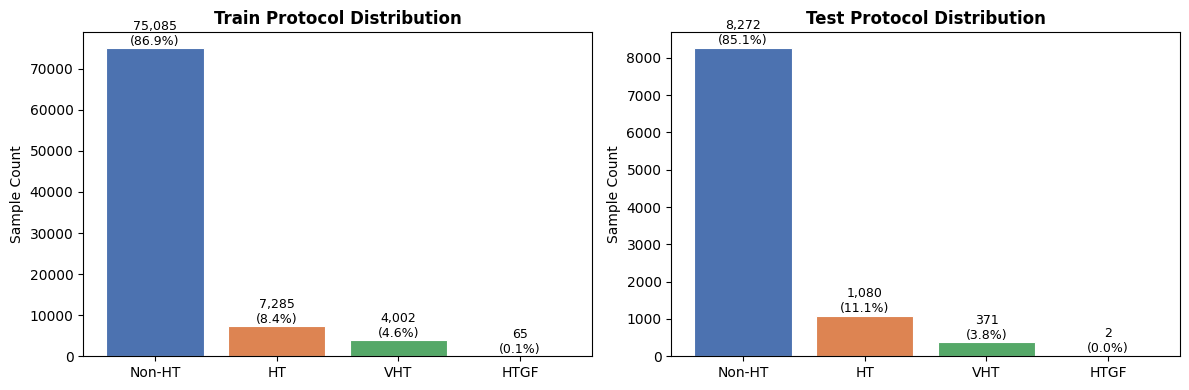

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (prot, title) in zip(axes, [(prot_train, 'Train'), (prot_test, 'Test')]):
    counts = [(prot == i).sum().item() for i in range(4)]
    colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
    bars = ax.bar(PROT_NAMES, counts, color=colors, edgecolor='white', linewidth=0.8)
    ax.set_title(f'{title} Protocol Distribution', fontsize=12, fontweight='bold')
    ax.set_ylabel('Sample Count')
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                f'{count:,}\n({100*count/sum(counts):.1f}%)',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('/workspace/protocol_dist.png')
plt.show()

In [14]:
print(f"\nSamples WITH HTSIG: {has_htsig_train.sum().int().item():,}  ({100*has_htsig_train.mean():.1f}%)")
print(f"Samples WITHOUT   : {(has_htsig_train==0).sum().item():,}  ({100*(1-has_htsig_train.mean()):.1f}%)")


Samples WITH HTSIG: 11,352  (13.1%)
Samples WITHOUT   : 75,085  (86.9%)


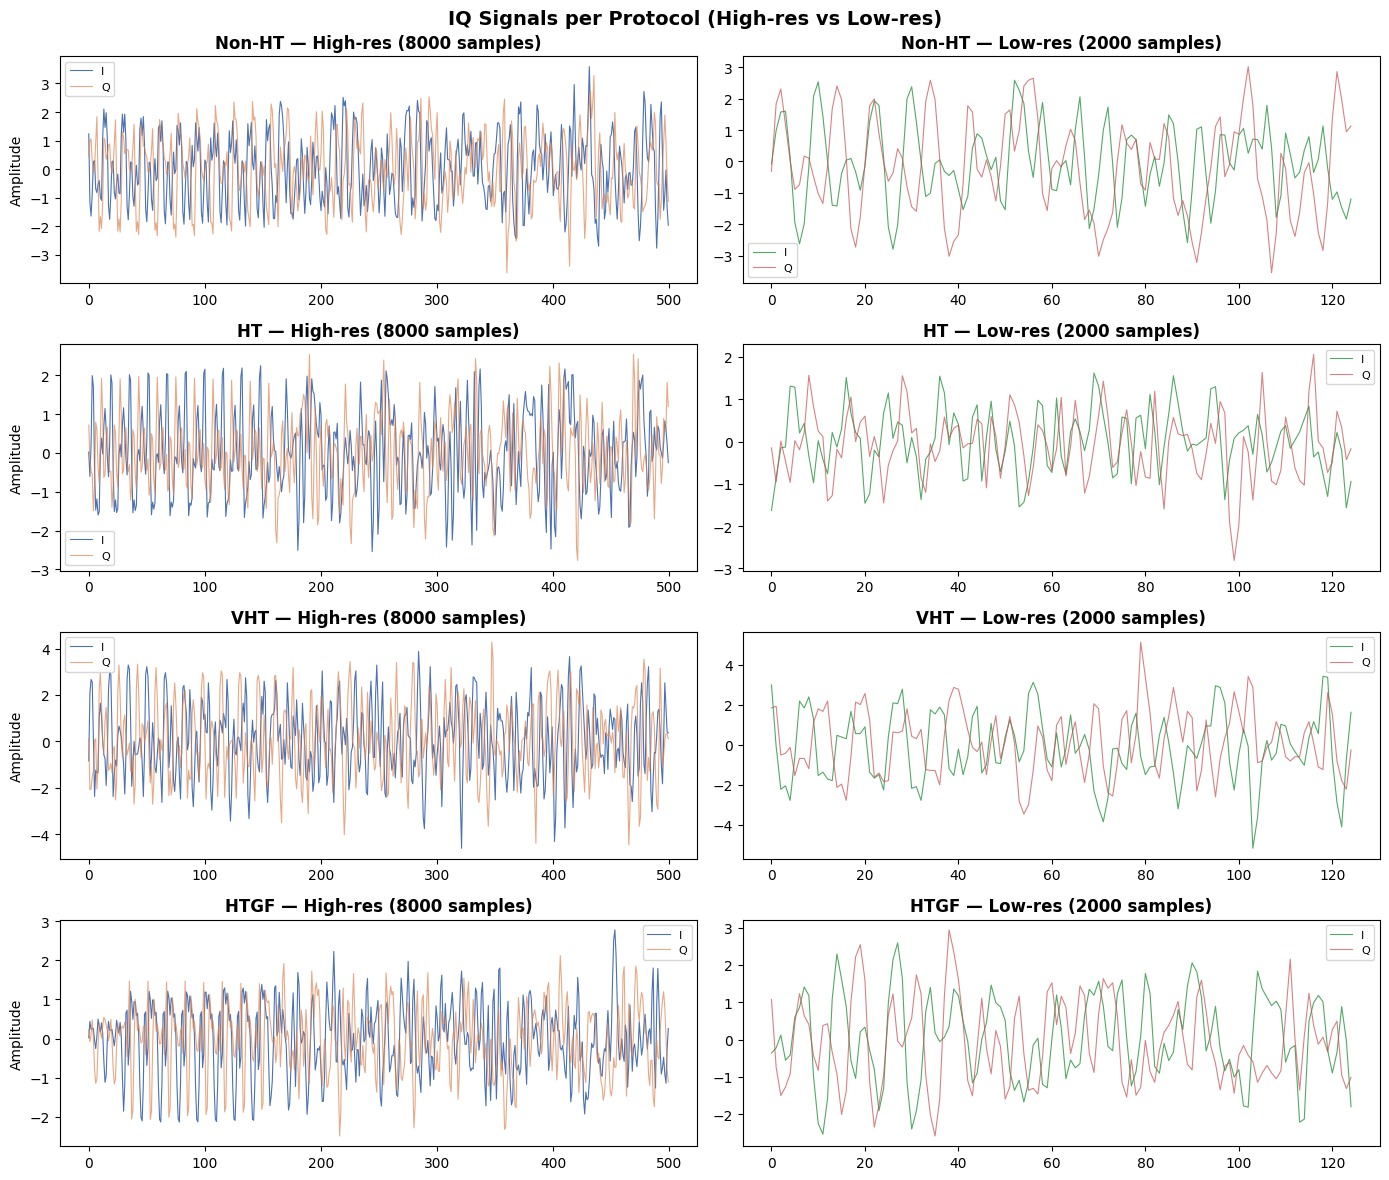

In [15]:
# Cell 4 — IQ signal visualization per protocol
fig, axes = plt.subplots(4, 2, figsize=(14, 12))

for prot_idx, prot_name in enumerate(PROT_NAMES):
    mask = (prot_train == prot_idx).nonzero(as_tuple=True)[0]
    if len(mask) == 0:
        print(f"No samples for {prot_name}")
        continue
    idx = mask[0].item()

    hi = high_train[idx].numpy()  # shape (2, 8000)
    lo = low_train[idx].numpy()   # shape (2, 2000)

    # Plot I channel only, first 500 samples
    axes[prot_idx][0].plot(hi[0, :500], color='#4C72B0', lw=0.8, label='I')
    axes[prot_idx][0].plot(hi[1, :500], color='#DD8452', lw=0.8, alpha=0.7, label='Q')
    axes[prot_idx][0].set_title(f'{prot_name} — High-res (8000 samples)', fontweight='bold')
    axes[prot_idx][0].legend(fontsize=8)
    axes[prot_idx][0].set_ylabel('Amplitude')

    axes[prot_idx][1].plot(lo[0, :125], color='#55A868', lw=0.8, label='I')
    axes[prot_idx][1].plot(lo[1, :125], color='#C44E52', lw=0.8, alpha=0.7, label='Q')
    axes[prot_idx][1].set_title(f'{prot_name} — Low-res (2000 samples)', fontweight='bold')
    axes[prot_idx][1].legend(fontsize=8)

plt.suptitle('IQ Signals per Protocol (High-res vs Low-res)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/workspace/iq_signals.png')
plt.show()

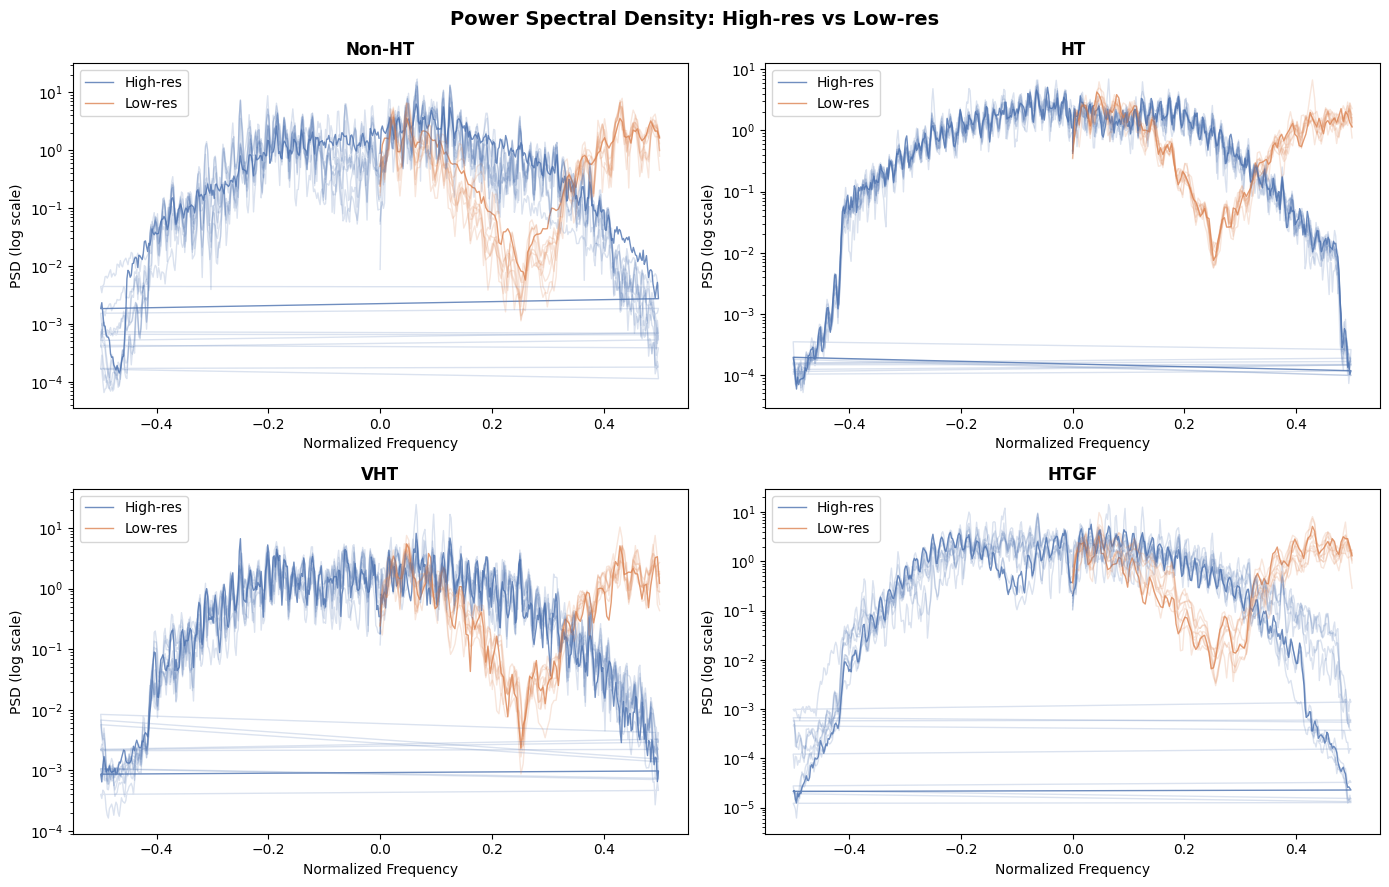

In [16]:
# Cell 5 — PSD per protocol (frequency domain)
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for prot_idx, prot_name in enumerate(PROT_NAMES):
    mask = (prot_train == prot_idx).nonzero(as_tuple=True)[0]
    if len(mask) == 0: continue
    ax = axes[prot_idx]

    # Average PSD over 10 samples
    for i in range(min(10, len(mask))):
        idx = mask[i].item()
        hi = high_train[idx, 0].numpy() + 1j * high_train[idx, 1].numpy()
        lo = low_train[idx, 0].numpy()  + 1j * low_train[idx, 1].numpy()
        f_hi, p_hi = welch(hi, nperseg=512)
        f_lo, p_lo = welch(lo, nperseg=128)
        alpha = 0.8 if i == 0 else 0.2
        ax.semilogy(f_hi, np.abs(p_hi), color='#4C72B0', alpha=alpha, lw=1,
                    label='High-res' if i == 0 else None)
        ax.semilogy(np.linspace(0, 0.5, len(f_lo)), np.abs(p_lo), color='#DD8452', alpha=alpha, lw=1,
                    label='Low-res' if i == 0 else None)

    ax.set_title(f'{prot_name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Normalized Frequency')
    ax.set_ylabel('PSD (log scale)')
    ax.legend()

plt.suptitle('Power Spectral Density: High-res vs Low-res', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/workspace/psd.png')
plt.show()

/usr/local/lib/python3.12/dist-packages/numpy/lib/_histograms_impl.py:902: RuntimeWarning: divide by zero encountered in divide
  return n/db/n.sum(), bin_edges
/usr/local/lib/python3.12/dist-packages/numpy/lib/_histograms_impl.py:902: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


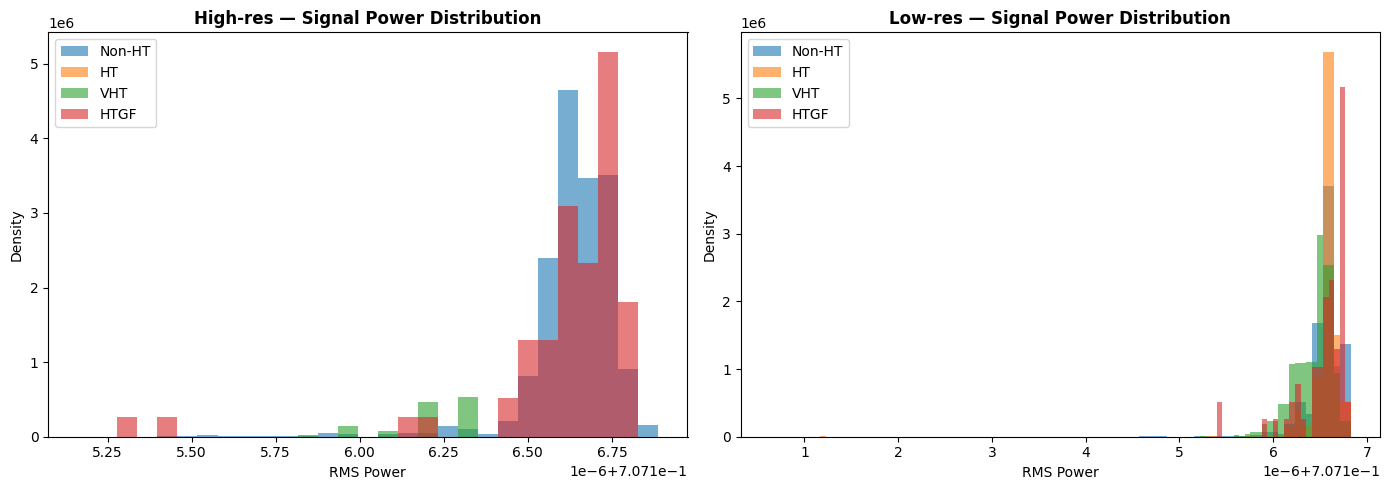

In [17]:
# Cell 6 — Signal power distribution per protocol
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (data, title) in zip(axes, [(high_train, 'High-res'), (low_train, 'Low-res')]):
    for prot_idx, prot_name in enumerate(PROT_NAMES):
        mask = (prot_train == prot_idx)
        if mask.sum() == 0: continue
        # RMS power per sample
        power = (data[mask] ** 2).mean(dim=(-1, -2)).sqrt().numpy()
        ax.hist(power, bins=60, alpha=0.6, label=prot_name, density=True)
    ax.set_title(f'{title} — Signal Power Distribution', fontweight='bold')
    ax.set_xlabel('RMS Power')
    ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
plt.savefig('/workspace/power_dist.png')
plt.show()

In [18]:
# Print stats
print("Mean RMS power per protocol (High-res):")
for prot_idx, prot_name in enumerate(PROT_NAMES):
    mask = (prot_train == prot_idx)
    if mask.sum() == 0: continue
    power = (high_train[mask] ** 2).mean(dim=(-1,-2)).sqrt()
    print(f"  {prot_name:8s}: mean={power.mean():.3f}  std={power.std():.3f}  min={power.min():.3f}  max={power.max():.3f}")

Mean RMS power per protocol (High-res):
  Non-HT  : mean=0.707  std=0.000  min=0.707  max=0.707
  HT      : mean=0.707  std=0.000  min=0.707  max=0.707
  VHT     : mean=0.707  std=0.000  min=0.707  max=0.707
  HTGF    : mean=0.707  std=0.000  min=0.707  max=0.707


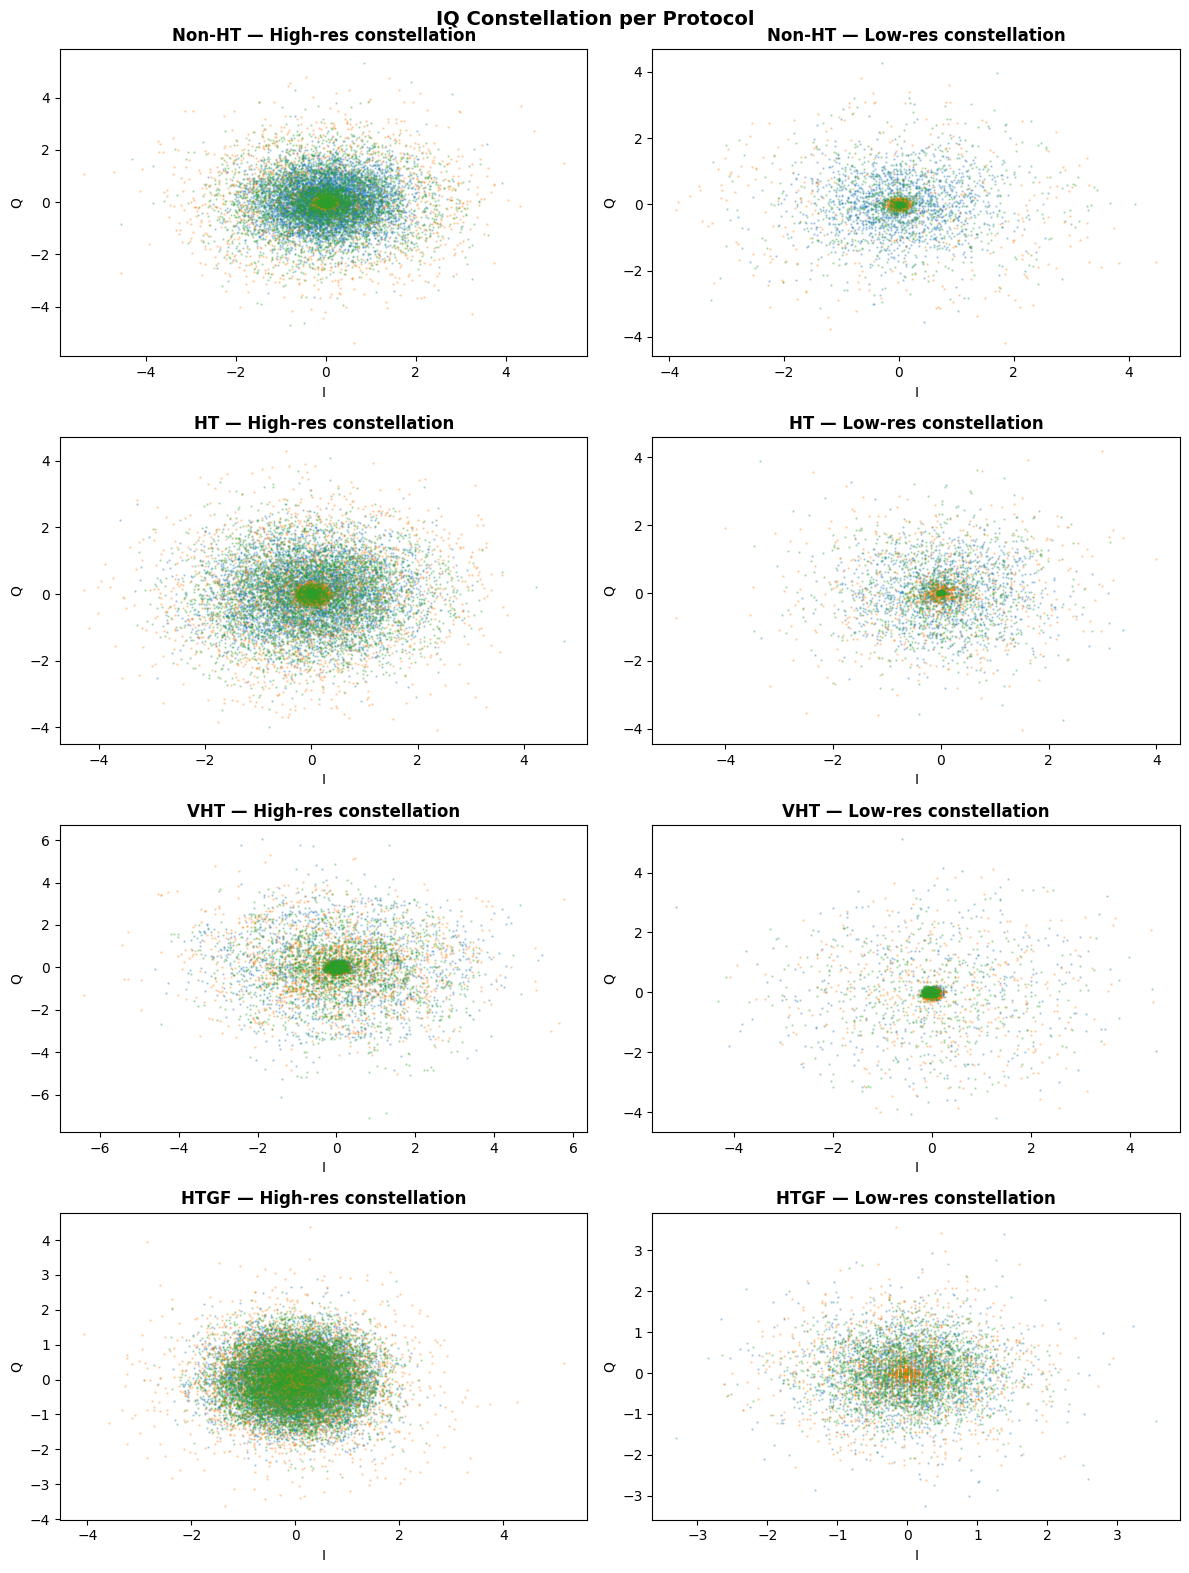

In [20]:
# Cell 7 — Constellation plots (I vs Q scatter)
fig, axes = plt.subplots(4, 2, figsize=(12, 16))

for prot_idx, prot_name in enumerate(PROT_NAMES):
    mask = (prot_train == prot_idx).nonzero(as_tuple=True)[0]
    if len(mask) == 0: continue
    
    # Use 3 samples overlaid
    for i in range(min(3, len(mask))):
        idx = mask[i].item()
        hi = high_train[idx].numpy()
        lo = low_train[idx].numpy()
        alpha = 0.3
        axes[prot_idx][0].scatter(hi[0], hi[1], s=0.5, alpha=alpha)
        axes[prot_idx][1].scatter(lo[0], lo[1], s=0.5, alpha=alpha)

    axes[prot_idx][0].set_title(f'{prot_name} — High-res constellation', fontweight='bold')
    axes[prot_idx][1].set_title(f'{prot_name} — Low-res constellation', fontweight='bold')
    axes[prot_idx][0].set_xlabel('I'); axes[prot_idx][0].set_ylabel('Q')
    axes[prot_idx][1].set_xlabel('I'); axes[prot_idx][1].set_ylabel('Q')

plt.suptitle('IQ Constellation per Protocol', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/workspace/constellation.png')
plt.show()

In [21]:
#Vectorized statistical features (GPU accelerated)
def extract_features_gpu(data, device=DEVICE, batch=2048):
    """Vectorized feature extraction using PyTorch on GPU."""
    all_feats = []
    for i in range(0, len(data), batch):
        sig = data[i:i+batch].to(device)  # (B, 2, L)
        I, Q = sig[:, 0], sig[:, 1]       # (B, L)
        amplitude = torch.sqrt(I**2 + Q**2)
        phase = torch.atan2(Q, I)

        amp_mean   = amplitude.mean(dim=1)
        amp_std    = amplitude.std(dim=1)
        amp_kurt   = ((amplitude - amp_mean.unsqueeze(1))**4).mean(dim=1) / (amp_std**4 + 1e-8)
        amp_skew   = ((amplitude - amp_mean.unsqueeze(1))**3).mean(dim=1) / (amp_std**3 + 1e-8)
        papr       = amplitude.max(dim=1).values**2 / ((amplitude**2).mean(dim=1) + 1e-8)
        phase_var  = torch.diff(phase, dim=1).std(dim=1)
        I_std      = I.std(dim=1)
        Q_std      = Q.std(dim=1)
        I_kurt     = ((I - I.mean(dim=1, keepdim=True))**4).mean(dim=1) / (I_std**4 + 1e-8)
        Q_kurt     = ((Q - Q.mean(dim=1, keepdim=True))**4).mean(dim=1) / (Q_std**4 + 1e-8)
        I_skew     = ((I - I.mean(dim=1, keepdim=True))**3).mean(dim=1) / (I_std**3 + 1e-8)
        Q_skew     = ((Q - Q.mean(dim=1, keepdim=True))**3).mean(dim=1) / (Q_std**3 + 1e-8)
        I_zcr      = ((I[:, :-1] * I[:, 1:]) < 0).float().mean(dim=1)
        Q_zcr      = ((Q[:, :-1] * Q[:, 1:]) < 0).float().mean(dim=1)
        iq_ratio   = (I**2).mean(dim=1) / ((Q**2).mean(dim=1) + 1e-8)

        feats = torch.stack([
            amp_mean, amp_std, amp_kurt, amp_skew,
            papr, phase_var,
            I_kurt, Q_kurt, I_skew, Q_skew,
            I_zcr, Q_zcr, iq_ratio
        ], dim=1)
        all_feats.append(feats.cpu())

    return torch.cat(all_feats).numpy()


print("Extracting features from ALL high-res samples...")
hi_feats = extract_features_gpu(high_train)
print("Extracting features from ALL low-res samples...")
lo_feats = extract_features_gpu(low_train)
labels   = prot_train.numpy()

print(f"\nFeature matrix shape: {hi_feats.shape}")
print(f"Done! {len(hi_feats):,} samples x {hi_feats.shape[1]} features")

Extracting features from ALL high-res samples...
Extracting features from ALL low-res samples...

Feature matrix shape: (86437, 13)
Done! 86,437 samples x 13 features


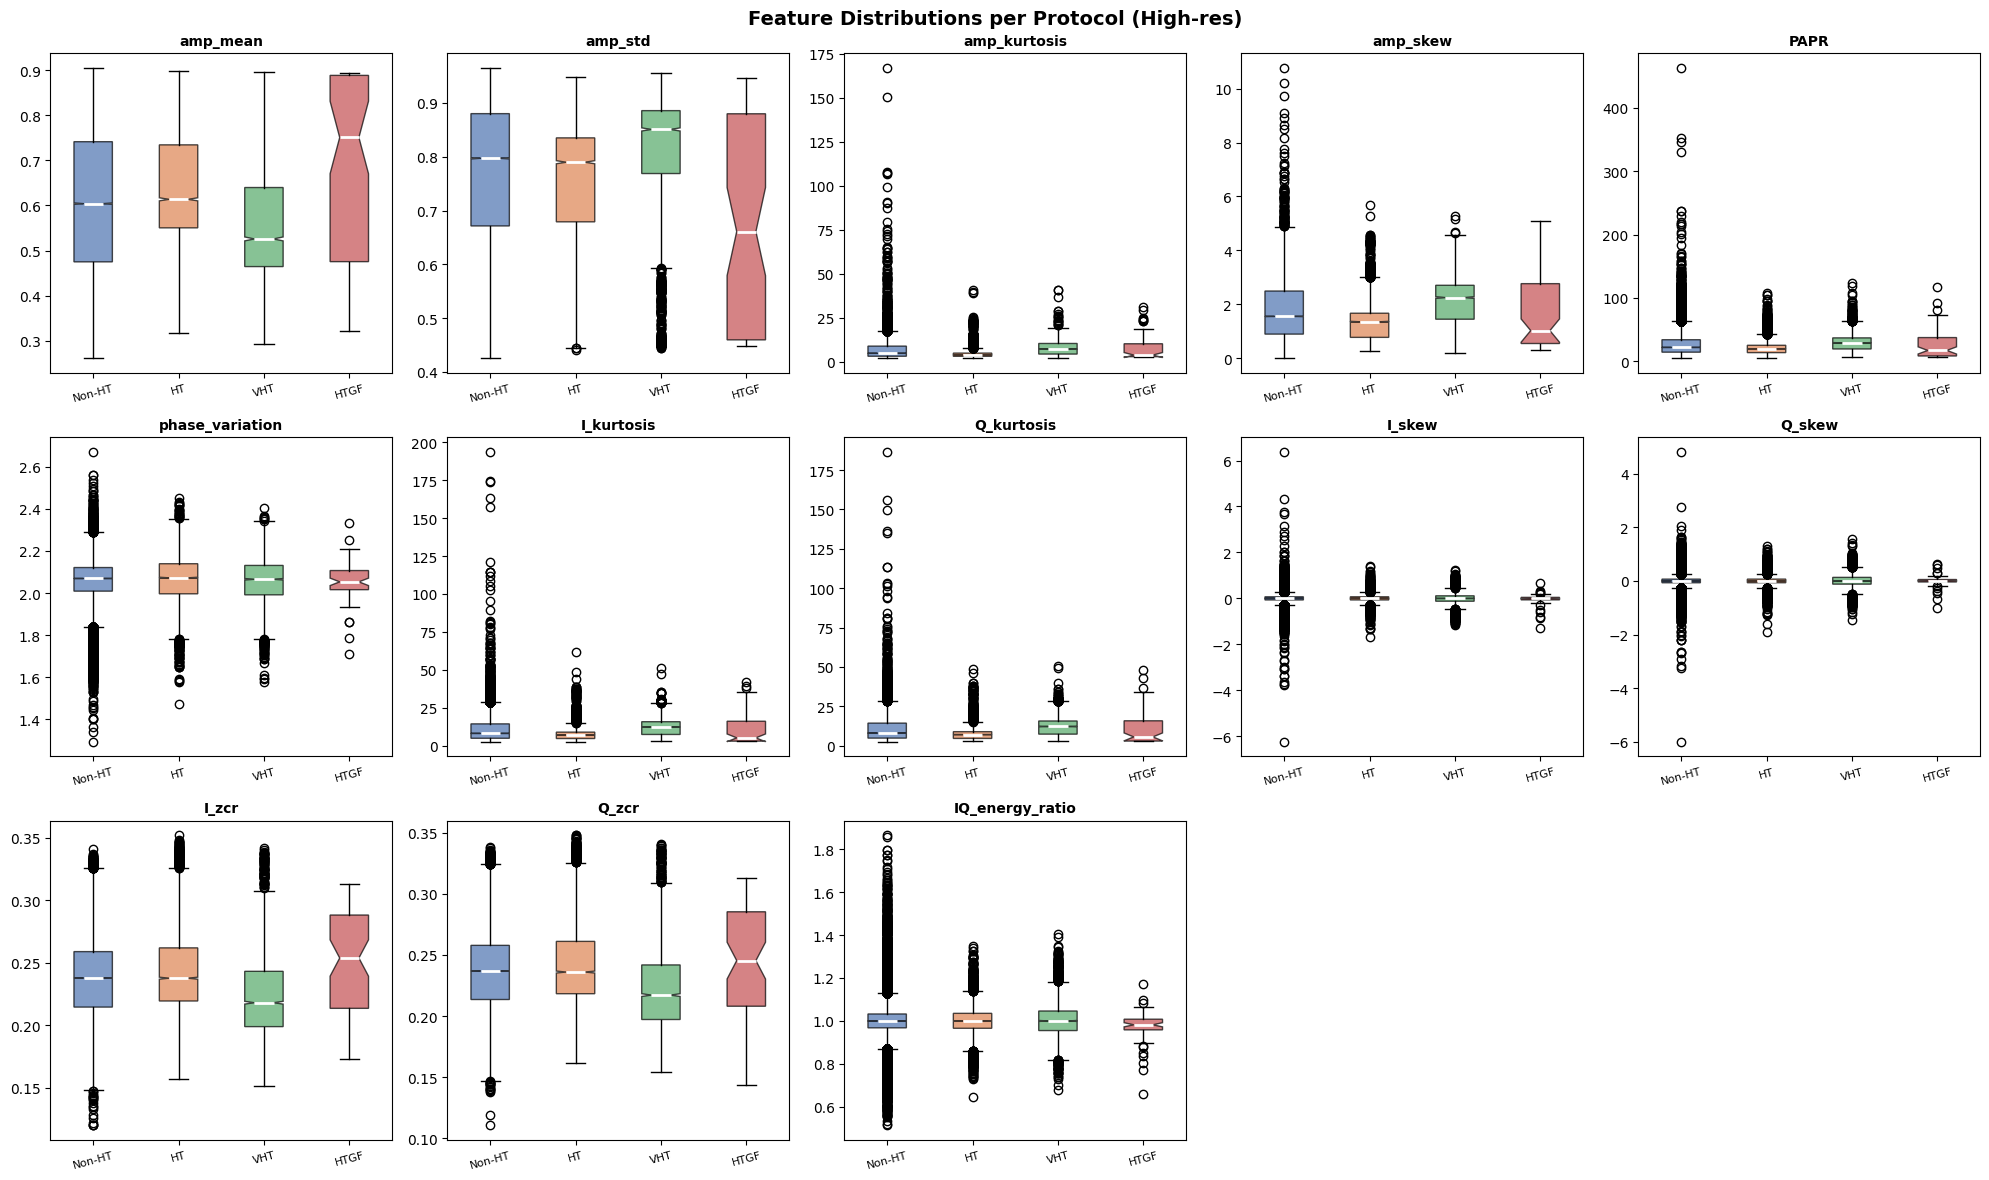

In [23]:
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for feat_idx, feat_name in enumerate(FEATURE_NAMES):
    ax = axes[feat_idx]
    data_per_prot = [
        hi_feats[labels == prot_idx, feat_idx]
        for prot_idx in range(4)
    ]
    bp = ax.boxplot(data_per_prot, tick_labels=PROT_NAMES,
                    patch_artist=True, notch=True,
                    medianprops=dict(color='white', linewidth=2))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(feat_name, fontweight='bold', fontsize=10)
    ax.set_xticklabels(PROT_NAMES, rotation=15, fontsize=8)

# Hide unused subplots
for i in range(len(FEATURE_NAMES), len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Feature Distributions per Protocol (High-res)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/workspace/feature_boxplots.png')
plt.show()

In [24]:
print("Feature separability (std of per-protocol medians — higher = more discriminative):")
for feat_idx, feat_name in enumerate(FEATURE_NAMES):
    medians = [np.median(hi_feats[labels == i, feat_idx]) for i in range(4)]
    sep = np.std(medians)
    print(f"  {feat_name:20s}: {sep:.4f}")

Feature separability (std of per-protocol medians — higher = more discriminative):
  amp_mean            : 0.0809
  amp_std             : 0.0698
  amp_kurtosis        : 1.3622
  amp_skew            : 0.4488
  PAPR                : 4.4463
  phase_variation     : 0.0073
  I_kurtosis          : 2.6164
  Q_kurtosis          : 2.4572
  I_skew              : 0.0022
  Q_skew              : 0.0014
  I_zcr               : 0.0127
  Q_zcr               : 0.0103
  IQ_energy_ratio     : 0.0077


Explained variance per component:
  PC1: 58.9%  (cumulative: 58.9%)
  PC2: 9.5%  (cumulative: 68.4%)
  PC3: 7.7%  (cumulative: 76.2%)
  PC4: 7.7%  (cumulative: 83.8%)


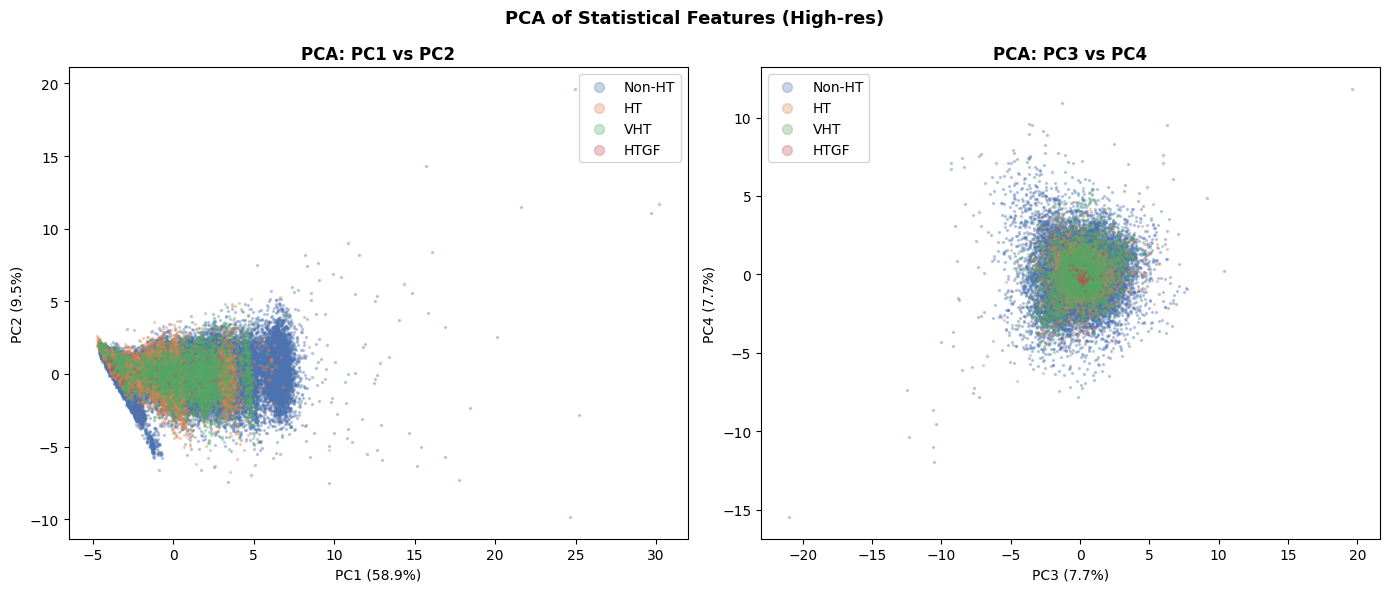

In [25]:
scaler = StandardScaler()
hi_scaled = scaler.fit_transform(hi_feats)

# PCA
pca = PCA(n_components=4)
hi_pca = pca.fit_transform(hi_scaled)

print("Explained variance per component:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {var*100:.1f}%  (cumulative: {pca.explained_variance_ratio_[:i+1].sum()*100:.1f}%)")

# Plot PC1 vs PC2, PC3 vs PC4
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for ax, (x_idx, y_idx) in zip(axes, [(0,1), (2,3)]):
    for prot_idx, (prot_name, color) in enumerate(zip(PROT_NAMES, colors)):
        mask = labels == prot_idx
        ax.scatter(hi_pca[mask, x_idx], hi_pca[mask, y_idx],
                   s=2, alpha=0.3, color=color, label=prot_name)
    ax.set_xlabel(f'PC{x_idx+1} ({pca.explained_variance_ratio_[x_idx]*100:.1f}%)')
    ax.set_ylabel(f'PC{y_idx+1} ({pca.explained_variance_ratio_[y_idx]*100:.1f}%)')
    ax.set_title(f'PCA: PC{x_idx+1} vs PC{y_idx+1}', fontweight='bold')
    ax.legend(markerscale=5)

plt.suptitle('PCA of Statistical Features (High-res)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/workspace/pca_features.png')
plt.show()


In [26]:
print("\nTop feature contributions to PC1:")
pc1_contrib = sorted(zip(FEATURE_NAMES, np.abs(pca.components_[0])), key=lambda x: -x[1])
for name, val in pc1_contrib[:5]:
    print(f"  {name:20s}: {val:.3f}")

print("\nTop feature contributions to PC2:")
pc2_contrib = sorted(zip(FEATURE_NAMES, np.abs(pca.components_[1])), key=lambda x: -x[1])
for name, val in pc2_contrib[:5]:
    print(f"  {name:20s}: {val:.3f}")


Top feature contributions to PC1:
  amp_skew            : 0.355
  Q_kurtosis          : 0.346
  I_kurtosis          : 0.345
  amp_mean            : 0.338
  PAPR                : 0.333

Top feature contributions to PC2:
  phase_variation     : 0.772
  I_skew              : 0.491
  Q_zcr               : 0.237
  I_zcr               : 0.221
  PAPR                : 0.102


Running t-SNE on high-res signals...
Running t-SNE on low-res signals...


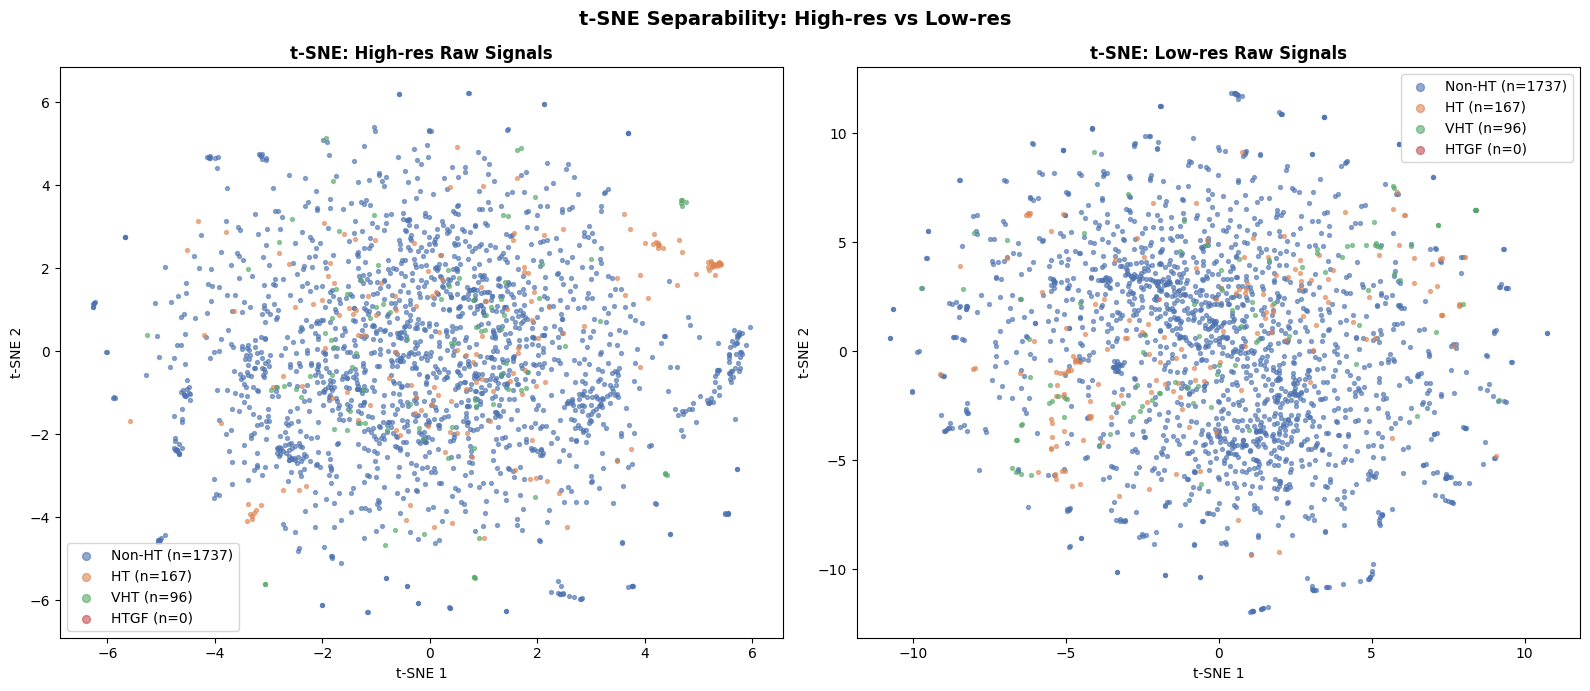

In [27]:
# Cell 11 — t-SNE on raw signals
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# Use a subsample — t-SNE is O(n^2), 2000 samples is enough
N_TSNE = 2000
idx_sample = np.random.choice(len(labels), N_TSNE, replace=False)

# Flatten raw high-res signals for t-SNE
# Too long to use full 8000 samples — downsample to 200 points for t-SNE input
step = high_train.shape[-1] // 200
hi_flat = high_train[idx_sample, :, ::step].reshape(N_TSNE, -1).numpy()
lo_flat = low_train[idx_sample, :, ::step].reshape(N_TSNE, -1).numpy()
tsne_labels = labels[idx_sample]

# Standardize
hi_flat = StandardScaler().fit_transform(hi_flat)
lo_flat = StandardScaler().fit_transform(lo_flat)

print("Running t-SNE on high-res signals...")
tsne_hi = TSNE(n_components=2, perplexity=50, random_state=42, n_jobs=-1).fit_transform(hi_flat)
print("Running t-SNE on low-res signals...")
tsne_lo = TSNE(n_components=2, perplexity=50, random_state=42, n_jobs=-1).fit_transform(lo_flat)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for ax, (tsne, title) in zip(axes, [(tsne_hi, 'High-res'), (tsne_lo, 'Low-res')]):
    for prot_idx, (prot_name, color) in enumerate(zip(PROT_NAMES, colors)):
        mask = tsne_labels == prot_idx
        ax.scatter(tsne[mask, 0], tsne[mask, 1],
                   s=8, alpha=0.6, color=color, label=f'{prot_name} (n={mask.sum()})')
    ax.set_title(f't-SNE: {title} Raw Signals', fontweight='bold', fontsize=12)
    ax.legend(markerscale=2)
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')

plt.suptitle('t-SNE Separability: High-res vs Low-res', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/workspace/tsne.png')
plt.show()

In [28]:
# Cell 12 — Class weights + improved loss functions
# ── Class weights (inverse frequency, capped) ──────────────────────────────
counts    = torch.tensor([(prot_train == i).sum().item() for i in range(4)], dtype=torch.float32)
total     = counts.sum()
raw_weights = total / (4 * counts)          # inverse frequency weighting

# Cap HTGF — 65 samples gives weight ~1156 which would destabilize training
weights     = raw_weights.clamp(max=MAX_WEIGHT).to(DEVICE)

print("Class weights:")
for name, raw, w in zip(PROT_NAMES, raw_weights, weights):
    print(f"  {name:8s}: raw={raw:.1f}  capped={w:.1f}")


Class weights:
  Non-HT  : raw=0.3  capped=0.3
  HT      : raw=3.0  capped=3.0
  VHT     : raw=5.4  capped=5.4
  HTGF    : raw=332.5  capped=50.0


In [34]:
def task_loss(prot_l, lsig_l, htsig_l,
              prot_gt, lsig_gt, htsig_gt, has_htsig,
              class_weights=weights, label_smoothing=0.1):

    # Cast weights to match model output dtype
    w = class_weights.to(dtype=prot_l.dtype)

    loss = F.cross_entropy(prot_l, prot_gt,
                           weight=w,
                           label_smoothing=label_smoothing)
    loss = loss + F.binary_cross_entropy_with_logits(
                    lsig_l.float(), lsig_gt.float())
    mask = has_htsig.bool()
    if mask.any():
        loss = loss + F.binary_cross_entropy_with_logits(
                        htsig_l[mask].float(), htsig_gt[mask].float())
    return loss

In [40]:
# ── Distillation loss: embedding + feature map ─────────────────────────────
def distill_loss(s_emb, t_emb, s_feat=None, t_feat=None, feat_weight=0.3):
    # Embedding-level distillation (always)
    emb_loss = F.mse_loss(s_emb, t_emb.detach())

    # Feature-map distillation (if intermediate features provided)
    if s_feat is not None and t_feat is not None:
        # Match spatial dimensions if needed
        if s_feat.shape != t_feat.shape:
            t_feat = F.adaptive_avg_pool1d(t_feat, s_feat.shape[-1])
        feat_loss = F.mse_loss(s_feat, t_feat.detach())
        return emb_loss + feat_weight * feat_loss

    return emb_loss

In [39]:
# ── Quick sanity check ─────────────────────────────────────────────────────
dummy_prot  = torch.zeros(8, 4).to(DEVICE)
dummy_gt    = torch.zeros(8, dtype=torch.long).to(DEVICE)
dummy_lsig  = torch.zeros(8, 24).to(DEVICE)
dummy_htsig = torch.zeros(8, 48).to(DEVICE)
dummy_mask  = torch.zeros(8).to(DEVICE)


loss_val = task_loss_simple(dummy_prot, dummy_lsig, dummy_htsig,
                     dummy_gt, dummy_lsig, dummy_htsig, dummy_mask)
print(f"\nLoss sanity check: {loss_val.item():.4f}")


Loss sanity check: 2.0794


In [41]:
# Cell 13 — Improved Model Architecture
class MultiScaleCNN(nn.Module):
    """
    Parallel CNN branches at different kernel sizes.
    Captures short (preamble symbols), medium (signal field),
    and long (data field) temporal patterns simultaneously.
    """
    def __init__(self, out_channels=256):
        super().__init__()
        branch_ch = out_channels // 4  # 64 per branch

        # Each branch: different kernel = different temporal scale
        self.branch1 = self._make_branch(2, branch_ch, kernel=7)   # short patterns
        self.branch2 = self._make_branch(2, branch_ch, kernel=15)  # medium patterns
        self.branch3 = self._make_branch(2, branch_ch, kernel=31)  # long patterns
        self.branch4 = self._make_branch(2, branch_ch, kernel=63)  # very long patterns

        # Fuse branches and project to full channel size
        self.fuse = nn.Sequential(
            nn.Conv1d(out_channels, out_channels, kernel_size=1),
            nn.BatchNorm1d(out_channels),
            nn.GELU()
        )

    def _make_branch(self, in_ch, out_ch, kernel):
        pad = kernel // 2
        return nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=kernel, stride=4, padding=pad),
            nn.BatchNorm1d(out_ch), nn.GELU(),
            nn.Conv1d(out_ch, out_ch, kernel_size=kernel//2+1, stride=2, padding=kernel//4),
            nn.BatchNorm1d(out_ch), nn.GELU(),
        )

    def forward(self, x):
        b1 = self.branch1(x)
        b2 = self.branch2(x)
        b3 = self.branch3(x)
        b4 = self.branch4(x)

        # Align lengths via interpolation (branches may differ slightly)
        target_len = min(b1.shape[-1], b2.shape[-1], b3.shape[-1], b4.shape[-1])
        b1 = F.adaptive_avg_pool1d(b1, target_len)
        b2 = F.adaptive_avg_pool1d(b2, target_len)
        b3 = F.adaptive_avg_pool1d(b3, target_len)
        b4 = F.adaptive_avg_pool1d(b4, target_len)

        return self.fuse(torch.cat([b1, b2, b3, b4], dim=1))


class IQEncoder(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM):
        super().__init__()

        # Stage 1: multi-scale feature extraction
        self.multiscale = MultiScaleCNN(out_channels=256)

        # Stage 2: deeper single-path CNN to compress further
        self.cnn2 = nn.Sequential(
            nn.Conv1d(256, 384, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(384), nn.GELU(),
            nn.Conv1d(384, embed_dim, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(embed_dim), nn.GELU(),
        )

        # Stage 3: deeper transformer (6 layers instead of 4)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=8,
            dim_feedforward=2048,   # wider feedforward
            dropout=0.1, batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer, num_layers=6,
            enable_nested_tensor=False
        )
        self.pool = nn.AdaptiveAvgPool1d(1)

    def forward(self, x):
        feat_ms  = self.multiscale(x)          # multi-scale features
        feat     = self.cnn2(feat_ms)           # compress further
        feat_t   = self.transformer(feat.permute(0,2,1)).permute(0,2,1)
        emb      = self.pool(feat_t).squeeze(-1)
        return emb, feat  # return both embedding and feature map


class WiFiDecoder(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM):
        super().__init__()
        self.prot_head  = nn.Sequential(
            nn.Linear(embed_dim, 256), nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(256, NUM_PROT)
        )
        self.lsig_head  = nn.Sequential(
            nn.Linear(embed_dim, 256), nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(256, LSIG_LEN)
        )
        self.htsig_head = nn.Sequential(
            nn.Linear(embed_dim, 256), nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(256, HTSIG_LEN)
        )

    def forward(self, emb):
        return self.prot_head(emb), self.lsig_head(emb), self.htsig_head(emb)


class WiFiModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = IQEncoder()
        self.decoder = WiFiDecoder()

    def forward(self, x):
        emb, feat = self.encoder(x)
        prot_l, lsig_l, htsig_l = self.decoder(emb)
        return prot_l, lsig_l, htsig_l, emb, feat




In [42]:
# ── Sanity check ────────────────────────────────────────────────────────────
model = WiFiModel().to(DEVICE)

# Test with high-res input
dummy_hi = torch.randn(4, 2, 8000).to(DEVICE)
dummy_lo = torch.randn(4, 2, 2000).to(DEVICE)

with torch.no_grad():
    out_hi = model(dummy_hi)
    out_lo = model(dummy_lo)

print("High-res input → output shapes:")
print(f"  prot_logits : {out_hi[0].shape}")
print(f"  lsig_logits : {out_hi[1].shape}")
print(f"  htsig_logits: {out_hi[2].shape}")
print(f"  embedding   : {out_hi[3].shape}")
print(f"  feat_map    : {out_hi[4].shape}")

print(f"\nLow-res input → embedding: {out_lo[3].shape}")
print(f"Low-res feat_map         : {out_lo[4].shape}")

total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")
print(f"Model size: {total_params * 4 / 1e6:.1f} MB (fp32)")

High-res input → output shapes:
  prot_logits : torch.Size([4, 4])
  lsig_logits : torch.Size([4, 24])
  htsig_logits: torch.Size([4, 48])
  embedding   : torch.Size([4, 512])
  feat_map    : torch.Size([4, 512, 250])

Low-res input → embedding: torch.Size([4, 512])
Low-res feat_map         : torch.Size([4, 512, 63])

Total parameters: 20,543,692
Model size: 82.2 MB (fp32)


In [43]:
class AugmentedDataset(Dataset):
    def __init__(self, data, augment=False):
        self.high, self.low, self.prot, self.lsig, self.htsig, self.has_htsig = data
        self.augment = augment

    def __len__(self):
        return len(self.prot)

    def __getitem__(self, idx):
        high = self.high[idx].clone()
        low  = self.low[idx].clone()
        if self.augment:
            for iq in (high, low):
                theta = torch.empty(1).uniform_(0, 2 * 3.14159265).item()
                cos_t = torch.cos(torch.tensor(theta))
                sin_t = torch.sin(torch.tensor(theta))
                real  = iq[0].clone()
                iq[0] = real * cos_t - iq[1] * sin_t
                iq[1] = real * sin_t + iq[1] * cos_t
        return high, low, self.prot[idx], self.lsig[idx], self.htsig[idx], self.has_htsig[idx]


class StudentDataset(Dataset):
    def __init__(self, base_data, teacher_cache_path, augment=False):
        self.base  = AugmentedDataset(base_data, augment=augment)
        cache      = torch.load(teacher_cache_path)
        self.t_emb = cache['emb']

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        high, low, prot, lsig, htsig, has_htsig = self.base[idx]
        return low, prot, lsig, htsig, has_htsig, self.t_emb[idx]


In [44]:
def get_scheduler_with_warmup(optimizer, warmup_epochs, total_epochs):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs      # linear warmup
        # cosine decay after warmup
        progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
        return 0.5 * (1 + torch.cos(torch.tensor(progress * 3.14159265)).item())
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

In [45]:
# ── Metrics ────────────────────────────────────────────────────────────────
def bit_acc(logits, targets):
    return ((logits.sigmoid() > 0.5).float() == targets).float().mean().item()

def prot_acc(logits, targets):
    return (logits.argmax(1) == targets).float().mean().item()

In [46]:
train_ds = AugmentedDataset(train_data, augment=True)
test_ds  = AugmentedDataset(test_data,  augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True,
                          persistent_workers=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True,
                          persistent_workers=True)

print(f"Train batches : {len(train_loader)}")
print(f"Test  batches : {len(test_loader)}")
print(f"Effective batch size: {BATCH_SIZE * ACCUM_STEPS}")
print(f"Warmup epochs : {WARMUP_EPOCHS}")
print(f"Teacher epochs: {TEACHER_EPOCHS}")
print(f"Student epochs: {STUDENT_EPOCHS}")


Train batches : 338
Test  batches : 38
Effective batch size: 512
Warmup epochs : 3
Teacher epochs: 20
Student epochs: 25


In [48]:
# ── Per-class accuracy tracking ────────────────────────────────────────────
@torch.no_grad()
def per_class_acc(model, loader, use_high):
    model.eval()
    correct = torch.zeros(4)
    total   = torch.zeros(4)
    for high_iq, low_iq, prot, lsig, htsig, has_htsig in loader:
        iq   = (high_iq if use_high else low_iq).to(DEVICE, non_blocking=True)
        prot = prot.to(DEVICE, non_blocking=True)
        with autocast(enabled=True):
            prot_l, _, _, _, _ = model(iq)
        preds = prot_l.argmax(1)
        for c in range(4):
            mask = (prot == c)
            correct[c] += (preds[mask] == prot[mask]).sum().cpu()
            total[c]   += mask.sum().cpu()
    return {PROT_NAMES[c]: (correct[c]/(total[c]+1e-8)).item() for c in range(4)}



In [55]:
@torch.no_grad()
def evaluate(model, loader, use_high):
    model.eval()
    tot_loss = tot_prot = tot_lsig = 0
    for high_iq, low_iq, prot, lsig, htsig, has_htsig in loader:
        iq        = (high_iq if use_high else low_iq).to(DEVICE, non_blocking=True)
        prot      = prot.to(DEVICE, non_blocking=True)
        lsig      = lsig.to(DEVICE, non_blocking=True)
        htsig     = htsig.to(DEVICE, non_blocking=True)
        has_htsig = has_htsig.to(DEVICE, non_blocking=True)
        with torch.amp.autocast('cuda'):
            prot_l, lsig_l, htsig_l, _, _ = model(iq)
        tot_loss += task_loss(prot_l, lsig_l, htsig_l,
                              prot, lsig, htsig, has_htsig).item()
        tot_prot += prot_acc(prot_l, prot)
        tot_lsig += bit_acc(lsig_l, lsig)
    n = len(loader)
    return tot_loss/n, tot_prot/n, tot_lsig/n


In [50]:
# Cell 15 — Train Teacher
# ── History tracking ───────────────────────────────────────────────────────
history = {
    'teacher_tr_loss': [], 'teacher_tr_prot': [], 'teacher_tr_lsig': [],
    'teacher_va_loss': [], 'teacher_va_prot': [], 'teacher_va_lsig': [],
    'teacher_lr': []
}

import subprocess
result = subprocess.run(['df', '-h', '/dev/shm'], capture_output=True, text=True)
print(result.stdout)



Filesystem      Size  Used Avail Use% Mounted on
shm              43G     0   43G   0% /dev/shm



In [51]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches : {len(test_loader)}")

Train batches: 338
Test batches : 38


In [52]:
# Reduce batch size
BATCH_SIZE  = 64
ACCUM_STEPS = 8   # keeps effective batch = 512

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

print(f"Train batches: {len(train_loader)}")
print(f"Effective batch: {BATCH_SIZE * ACCUM_STEPS}")

Train batches: 1351
Effective batch: 512


In [37]:
weights = torch.tensor([
    0.5,   # Non-HT  (87% of data, slight downweight)
    3.0,   # HT
    5.0,   # VHT
    10.0,  # HTGF (was 50, now 10 — much more reasonable)
]).to(DEVICE)

print("New class weights:")
for name, w in zip(PROT_NAMES, weights):
    print(f"  {name:8s}: {w:.1f}")

New class weights:
  Non-HT  : 0.5
  HT      : 3.0
  VHT     : 5.0
  HTGF    : 10.0


In [62]:
from IPython.display import clear_output
import matplotlib.pyplot as plt

def plot_history(history):
    clear_output(wait=True)
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    
    epochs = range(1, len(history['tr_loss']) + 1)
    
    # Loss
    axes[0].plot(epochs, history['tr_loss'], 'b-o', label='Train', markersize=4)
    axes[0].plot(epochs, history['va_loss'], 'r-o', label='Val', markersize=4)
    axes[0].set_title('Loss', fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[0].grid(True)
    
    # Protocol accuracy
    axes[1].plot(epochs, history['tr_prot'], 'b-o', label='Train', markersize=4)
    axes[1].plot(epochs, history['va_prot'], 'r-o', label='Val', markersize=4)
    axes[1].set_title('Protocol Accuracy', fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylim(0, 1)
    axes[1].legend()
    axes[1].grid(True)
    
    # LSIG bit accuracy
    axes[2].plot(epochs, history['tr_lsig'], 'b-o', label='Train', markersize=4)
    axes[2].plot(epochs, history['va_lsig'], 'r-o', label='Val', markersize=4)
    axes[2].set_title('LSIG Bit Accuracy', fontweight='bold')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylim(0, 1)
    axes[2].legend()
    axes[2].grid(True)
    
    plt.suptitle(f'Training Progress — Epoch {len(epochs)}', 
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [76]:
# Time just the data loading
t0 = time.time()
for i, batch in enumerate(train_loader):
    if i == 10: break
data_time = (time.time() - t0) / 10
print(f"Avg data loading time per batch: {data_time*1000:.1f}ms")

# Time a forward + backward pass
t0 = time.time()
dummy = torch.randn(128, 2, 8000).to(DEVICE)
with torch.amp.autocast('cuda'):
    out = teacher(dummy)
    loss = out[0].mean()
loss.backward()
gpu_time = (time.time() - t0)
print(f"Forward+backward time: {gpu_time*1000:.1f}ms")
print(f"\nBottleneck: {'DATA LOADING' if data_time > gpu_time else 'GPU COMPUTE'}")

Avg data loading time per batch: 3.5ms
Forward+backward time: 72.5ms

Bottleneck: GPU COMPUTE


In [80]:
# Clear GPU
try:
    del teacher
except:
    pass
gc.collect()
torch.cuda.empty_cache()

# Bigger batch, no compile
BATCH_SIZE  = 512
ACCUM_STEPS = 1
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0, pin_memory=True)

# Init model — no compile
teacher  = WiFiModel().to(DEVICE)
t_opt    = torch.optim.AdamW(teacher.parameters(), lr=LR, weight_decay=1e-4)
t_sched  = get_scheduler_with_warmup(t_opt, WARMUP_EPOCHS, TEACHER_EPOCHS)
t_scaler = torch.amp.GradScaler('cuda')
best_t_prot = 0.0
history = {'tr_loss':[], 'tr_prot':[], 'tr_lsig':[], 'va_loss':[], 'va_prot':[], 'va_lsig':[]}

print(f"{'Ep':>3} {'tr_loss':>8} {'tr_prot':>8} {'tr_lsig':>8} {'va_prot':>8} {'va_lsig':>8} {'lr':>8} {'time':>6}")
print("-" * 70)

for epoch in range(1, TEACHER_EPOCHS + 1):
    teacher.train()
    t0 = time.time()
    tot_loss = tot_prot = tot_lsig = 0
    t_opt.zero_grad()

    for i, (high_iq, _, prot, lsig, htsig, has_htsig) in enumerate(train_loader):
        high_iq   = high_iq.to(DEVICE, non_blocking=True)
        prot      = prot.to(DEVICE, non_blocking=True)
        lsig      = lsig.to(DEVICE, non_blocking=True)
        htsig     = htsig.to(DEVICE, non_blocking=True)
        has_htsig = has_htsig.to(DEVICE, non_blocking=True)

        with autocast('cuda'):
            prot_l, lsig_l, htsig_l, _, _ = teacher(high_iq)
            loss = task_loss_balanced(prot_l, lsig_l, htsig_l,
                                      prot, lsig, htsig, has_htsig) / ACCUM_STEPS

        t_scaler.scale(loss).backward()
        if (i + 1) % ACCUM_STEPS == 0 or (i + 1) == len(train_loader):
            t_scaler.unscale_(t_opt)
            torch.nn.utils.clip_grad_norm_(teacher.parameters(), 1.0)
            t_scaler.step(t_opt)
            t_scaler.update()
            t_opt.zero_grad()

        tot_loss += loss.item() * ACCUM_STEPS
        tot_prot += prot_acc(prot_l, prot)
        tot_lsig += bit_acc(lsig_l, lsig)

    t_sched.step()
    n  = len(train_loader)
    tr = (tot_loss/n, tot_prot/n, tot_lsig/n)
    va = evaluate(teacher, test_loader, use_high=True)
    lr = t_opt.param_groups[0]['lr']

    if va[1] > best_t_prot:
        best_t_prot = va[1]
        torch.save(teacher.state_dict(), '/workspace/teacher_best.pt')
        marker = ' <- best'
    else:
        marker = ''

    for key, val in zip(['tr_loss','tr_prot','tr_lsig','va_loss','va_prot','va_lsig'],
                        [tr[0], tr[1], tr[2], va[0], va[1], va[2]]):
        history[key].append(val)

    print(f"{epoch:3d} {tr[0]:8.4f} {tr[1]:8.3f} {tr[2]:8.3f} "
          f"{va[1]:8.3f} {va[2]:8.3f} {lr:8.2e} {time.time()-t0:5.0f}s{marker}")

print(f"\nBest teacher va_prot: {best_t_prot:.4f}")

 Ep  tr_loss  tr_prot  tr_lsig  va_prot  va_lsig       lr   time
----------------------------------------------------------------------
  1   1.1450    0.877    0.880    0.965    0.915 3.33e-04    50s <- best
  2   0.6222    0.974    0.915    0.988    0.924 5.00e-04    51s <- best
  3   0.4899    0.983    0.933    0.989    0.946 5.00e-04    50s <- best
  4   0.3970    0.987    0.948    0.992    0.957 4.96e-04    51s <- best
  5   0.3538    0.988    0.954    0.987    0.962 4.83e-04    50s
  6   0.3209    0.991    0.958    0.993    0.963 4.63e-04    51s <- best
  7   0.2862    0.992    0.961    0.992    0.966 4.35e-04    50s
  8   0.2655    0.993    0.965    0.992    0.970 4.01e-04    51s
  9   0.2430    0.994    0.969    0.993    0.972 3.61e-04    50s
 10   0.2222    0.994    0.974    0.992    0.977 3.18e-04    51s
 11   0.2050    0.994    0.978    0.994    0.980 2.73e-04    51s <- best
 12   0.1818    0.996    0.981    0.995    0.982 2.27e-04    50s <- best
 13   0.1688    0.996    0.9

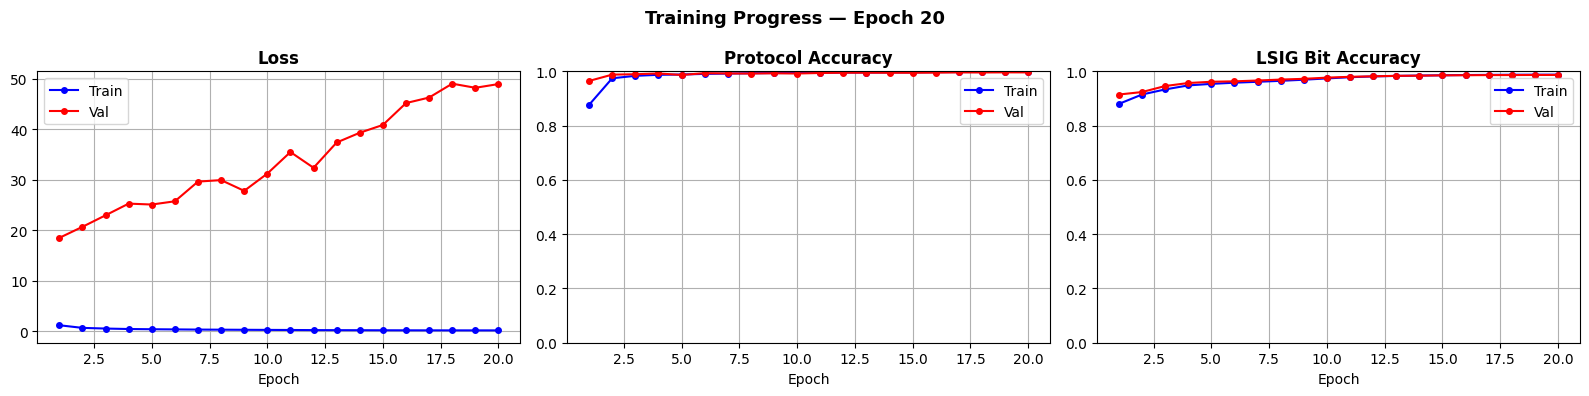

In [81]:
plot_history(history)

In [83]:
teacher.load_state_dict(torch.load('/workspace/teacher_best.pt'))
teacher.eval()
correct = torch.zeros(4)
total   = torch.zeros(4)

with torch.no_grad():
    for high_iq, low_iq, prot, *_ in test_loader:
        iq   = high_iq.to(DEVICE)
        prot = prot.to(DEVICE)
        with torch.amp.autocast('cuda'):
            prot_l, _, _, _, _ = teacher(iq)
        preds = prot_l.argmax(1)
        for c in range(4):
            mask = (prot == c)
            correct[c] += (preds[mask] == prot[mask]).sum().cpu()
            total[c]   += mask.sum().cpu()

print("Per-class accuracy:")
for c in range(4):
    acc = correct[c] / (total[c] + 1e-8)
    print(f"  {PROT_NAMES[c]:8s}: {acc*100:.1f}%  ({int(total[c])} samples)")

Per-class accuracy:
  Non-HT  : 99.8%  (8272 samples)
  HT      : 98.8%  (1080 samples)
  VHT     : 98.7%  (371 samples)
  HTGF    : 50.0%  (2 samples)


1st Attempt

```
 Ep  tr_loss  tr_prot  tr_lsig  va_loss  va_prot  va_lsig       lr   time
---------------------------------------------------------------------------
  1   3.4225    0.078    0.880   3.2931    0.132    0.916 3.33e-04    47s ← best
  2   2.8864    0.121    0.922   3.1146    0.144    0.944 5.00e-04    47s ← best
  3   2.7369    0.125    0.946   3.0269    0.142    0.957 5.00e-04    47s ← best
  4   2.6581    0.126    0.956   2.9909    0.147    0.961 4.96e-04    47s ← best
  5   2.6147    0.127    0.962   2.9725    0.145    0.967 4.83e-04    47s ← best
  6   2.5885    0.128    0.967   2.9394    0.144    0.972 4.63e-04    48s ← best
  7   2.5654    0.128    0.973   2.9080    0.146    0.976 4.35e-04    48s ← best
  8   2.5403    0.129    0.976   2.9242    0.144    0.978 4.01e-04    47s
  9   2.5235    0.129    0.979   2.8799    0.148    0.980 3.61e-04    48s ← best
 10   2.5094    0.129    0.982   2.8809    0.147    0.982 3.18e-04    48s
 11   2.4873    0.130    0.983   2.8664    0.147    0.983 2.73e-04    47s ← best
```

2nd Attempt
```
 Ep  tr_loss  tr_prot  tr_lsig  va_loss  va_prot  va_lsig       lr   time
---------------------------------------------------------------------------
  1   3.4001    0.081    0.882   3.2941    0.139    0.919 3.33e-04    48s ← best
  2   2.8619    0.121    0.926   3.0654    0.143    0.951 5.00e-04    48s ← best
  3   2.7280    0.125    0.949   3.0510    0.143    0.957 5.00e-04    47s ← best
```

3rd Attempt
```
Ep  tr_loss  tr_prot  tr_lsig  va_loss  va_prot  va_lsig       lr   time
---------------------------------------------------------------------------
  1   0.8530    0.928    0.889  20.4583    0.983    0.927 3.33e-04    46s ← best
  2   0.4501    0.985    0.936  29.1423    0.991    0.958 5.00e-04    46s
  3   0.3540    0.990    0.953  25.1941    0.995    0.962 5.00e-04    47s
  4   0.2850    0.992    0.963  33.6967    0.995    0.970 4.96e-04    47s
```

4th Attempt - Loss Large

```
 Ep  tr_loss  tr_prot  tr_lsig  va_loss  va_prot  va_lsig       lr   time
---------------------------------------------------------------------------
  1   0.8501    0.927    0.890  19.5133    0.981    0.927 3.33e-04    47s ← best
  2   0.4541    0.985    0.934  27.1326    0.988    0.954 5.00e-04    47s
  3   0.3406    0.990    0.953      inf    0.992    0.963 5.00e-04    46s
  4   0.2817    0.992    0.962      inf    0.995    0.969 4.96e-04    46s
```



5th Attempt Final Teacher

```
 Ep  tr_loss  tr_prot  tr_lsig  va_loss  va_prot  va_lsig       lr   time
---------------------------------------------------------------------------
  1   0.8194    0.934    0.894  22.0294    0.986    0.933 3.33e-04    46s ← best
  2   0.4196    0.986    0.940  26.1990    0.991    0.956 5.00e-04    46s
  3   0.3358    0.989    0.954  25.3424    0.993    0.962 5.00e-04    46s
  4   0.2755    0.992    0.962  35.6990    0.992    0.967 4.96e-04    46s
  5   0.2399    0.994    0.971  34.4823    0.995    0.976 4.83e-04    47s
  6   0.2087    0.995    0.979  36.1658    0.995    0.980 4.63e-04    47s
  7   0.1900    0.995    0.982  37.5799    0.996    0.982 4.35e-04    47s
  8   0.1769    0.996    0.983  38.3737    0.995    0.984 4.01e-04    46s
  9   0.1625    0.997    0.985  33.7329    0.998    0.985 3.61e-04    47s
 10   0.1572    0.996    0.985  42.5801    0.997    0.986 3.18e-04    47s
 11   0.1403    0.997    0.987  41.1933    0.997    0.986 2.73e-04    47s
 12   0.1351    0.997    0.988  42.0181    0.996    0.987 2.27e-04    47s
 13   0.1248    0.998    0.989  45.8214    0.998    0.987 1.82e-04    46s
 14   0.1190    0.998    0.989  44.7778    0.997    0.988 1.39e-04    47s
 15   0.1114    0.998    0.990  45.8896    0.998    0.988 9.93e-05    47s
 16   0.1063    0.998    0.991  48.0677    0.998    0.989 6.52e-05    46s
 17   0.1030    0.999    0.991  50.4079    0.998    0.989 3.74e-05    46s
 18   0.0992    0.999    0.991  49.1932    0.998    0.989 1.69e-05    47s
 19   0.0977    0.999    0.991  50.8799    0.998    0.989 4.26e-06    47s
 20   0.0971    0.999    0.992  51.1143    0.998    0.990 0.00e+00    47s

Best teacher val loss: 22.0294
```

Per-class accuracy:
  Non-HT  : 99.6%  (8272 samples)
  HT      : 98.2%  (1080 samples)
  VHT     : 76.5%  (371 samples)
  HTGF    : 0.0%  (2 samples)

6th Attempt

```
 Ep  tr_loss  tr_prot  tr_lsig  va_prot  va_lsig       lr   time
----------------------------------------------------------------------
  1   1.1450    0.877    0.880    0.965    0.915 3.33e-04    50s <- best
  2   0.6222    0.974    0.915    0.988    0.924 5.00e-04    51s <- best
  3   0.4899    0.983    0.933    0.989    0.946 5.00e-04    50s <- best
  4   0.3970    0.987    0.948    0.992    0.957 4.96e-04    51s <- best
  5   0.3538    0.988    0.954    0.987    0.962 4.83e-04    50s
  6   0.3209    0.991    0.958    0.993    0.963 4.63e-04    51s <- best
  7   0.2862    0.992    0.961    0.992    0.966 4.35e-04    50s
  8   0.2655    0.993    0.965    0.992    0.970 4.01e-04    51s
  9   0.2430    0.994    0.969    0.993    0.972 3.61e-04    50s
 10   0.2222    0.994    0.974    0.992    0.977 3.18e-04    51s
 11   0.2050    0.994    0.978    0.994    0.980 2.73e-04    51s <- best
 12   0.1818    0.996    0.981    0.995    0.982 2.27e-04    50s <- best
 13   0.1688    0.996    0.983    0.995    0.983 1.82e-04    51s <- best
 14   0.1618    0.996    0.984    0.995    0.984 1.39e-04    50s
 15   0.1490    0.996    0.985    0.995    0.985 9.93e-05    51s
 16   0.1402    0.997    0.986    0.995    0.986 6.52e-05    50s <- best
 17   0.1338    0.997    0.987    0.996    0.986 3.74e-05    51s <- best
 18   0.1308    0.998    0.987    0.996    0.986 1.69e-05    50s
 19   0.1271    0.998    0.988    0.996    0.987 4.26e-06    51s <- best
 20   0.1256    0.998    0.988    0.996    0.987 0.00e+00    50s

Best teacher va_prot: 0.9962

Per-class accuracy:
  Non-HT  : 99.8%  (8272 samples)
  HT      : 98.8%  (1080 samples)
  VHT     : 98.7%  (371 samples)
  HTGF    : 50.0%  (2 samples)
```



In [38]:
def task_loss_simple(prot_l, lsig_l, htsig_l,
                     prot_gt, lsig_gt, htsig_gt, has_htsig):
    loss = F.cross_entropy(prot_l, prot_gt)  # no weights, no smoothing
    loss = loss + F.binary_cross_entropy_with_logits(lsig_l.float(), lsig_gt.float())
    mask = has_htsig.bool()
    if mask.any():
        loss = loss + F.binary_cross_entropy_with_logits(
                        htsig_l[mask].float(), htsig_gt[mask].float())
    return loss

In [98]:
# 2 minute check — is it actually learning all classes?
teacher.eval()
correct = torch.zeros(4)
total   = torch.zeros(4)

with torch.no_grad():
    for high_iq, low_iq, prot, *_ in test_loader:
        iq   = high_iq.to(DEVICE)
        prot = prot.to(DEVICE)
        with torch.amp.autocast('cuda'):
            prot_l, _, _, _, _ = teacher(iq)
        preds = prot_l.argmax(1)
        for c in range(4):
            mask = (prot == c)
            correct[c] += (preds[mask] == prot[mask]).sum().cpu()
            total[c]   += mask.sum().cpu()

print("Per-class accuracy:")
for c in range(4):
    acc = correct[c] / (total[c] + 1e-8)
    print(f"  {PROT_NAMES[c]:8s}: {acc*100:.1f}%  ({int(total[c])} samples)")

Per-class accuracy:
  Non-HT  : 99.8%  (8272 samples)
  HT      : 98.0%  (1080 samples)
  VHT     : 97.6%  (371 samples)
  HTGF    : 0.0%  (2 samples)


In [59]:
@torch.no_grad()
def evaluate(model, loader, use_high):
    model.eval()
    tot_loss = tot_prot = tot_lsig = 0
    for high_iq, low_iq, prot, lsig, htsig, has_htsig in loader:
        iq        = (high_iq if use_high else low_iq).to(DEVICE, non_blocking=True)
        prot      = prot.to(DEVICE, non_blocking=True)
        lsig      = lsig.to(DEVICE, non_blocking=True)
        htsig     = htsig.to(DEVICE, non_blocking=True)
        has_htsig = has_htsig.to(DEVICE, non_blocking=True)
        
        with torch.amp.autocast('cuda'):
            prot_l, lsig_l, htsig_l, _, _ = model(iq)
        
        # Cast all to float32 before loss computation
        loss = task_loss(
            prot_l.float(), lsig_l.float(), htsig_l.float(),
            prot, lsig.float(), htsig.float(), has_htsig
        )
        tot_loss += loss.item()
        tot_prot += prot_acc(prot_l, prot)
        tot_lsig += bit_acc(lsig_l, lsig)
    n = len(loader)
    return tot_loss/n, tot_prot/n, tot_lsig/n

In [88]:
@torch.no_grad()
def cache_teacher_embeddings(teacher, loader, path):
    if os.path.exists(path):
        os.remove(path)
    teacher.eval()
    all_emb = []
    for high_iq, *_ in tqdm(loader, desc='Caching embeddings'):
        high_iq = high_iq.to(DEVICE, non_blocking=True)
        with torch.amp.autocast('cuda'):
            _, _, _, emb, _ = teacher(high_iq)
        all_emb.append(emb.cpu())
    embeddings = torch.cat(all_emb)
    torch.save({'emb': embeddings}, path)
    print(f'Saved {len(embeddings):,} embeddings → {path}')

cache_loader = DataLoader(train_ds, batch_size=512, shuffle=False, num_workers=0)
cache_teacher_embeddings(teacher, cache_loader, '/workspace/data/teacher_emb_train.pt')

Caching embeddings:   0%|          | 0/169 [00:00<?, ?it/s]

Saved 86,437 embeddings → /workspace/data/teacher_emb_train.pt


In [73]:
def task_loss_balanced(prot_l, lsig_l, htsig_l,
                       prot_gt, lsig_gt, htsig_gt, has_htsig):
    # Gentle weights — just enough to boost minority classes
    w = torch.tensor([0.5, 1.5, 4.0, 8.0]).to(prot_l.device).to(prot_l.dtype)
    loss = F.cross_entropy(prot_l, prot_gt, weight=w)
    loss = loss + F.binary_cross_entropy_with_logits(lsig_l.float(), lsig_gt.float())
    mask = has_htsig.bool()
    if mask.any():
        loss = loss + F.binary_cross_entropy_with_logits(
                        htsig_l[mask].float(), htsig_gt[mask].float())
    return loss

In [90]:
# Student Dataset — pairs low-res signals with teacher embeddings
class StudentDataset(Dataset):
    def __init__(self, base_data, teacher_cache_path, augment=False):
        self.base  = AugmentedDataset(base_data, augment=augment)
        cache      = torch.load(teacher_cache_path)
        self.t_emb = cache['emb']

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        high, low, prot, lsig, htsig, has_htsig = self.base[idx]
        return low, prot, lsig, htsig, has_htsig, self.t_emb[idx]


# Student training loss
def student_loss(prot_l, lsig_l, htsig_l, s_emb,
                 prot_gt, lsig_gt, htsig_gt, has_htsig, t_emb,
                 alpha=0.5):
    tl = task_loss_balanced(prot_l, lsig_l, htsig_l,
                            prot_gt, lsig_gt, htsig_gt, has_htsig)
    dl = F.mse_loss(s_emb, t_emb.detach())
    return alpha * tl + (1 - alpha) * dl, tl, dl


# Setup student dataloader
student_train_ds = StudentDataset(train_data, '/workspace/data/teacher_emb_train.pt', augment=True)
student_loader   = DataLoader(student_train_ds, batch_size=512,
                              shuffle=True, num_workers=0, pin_memory=True)

print(f"Student train samples: {len(student_train_ds):,}")
print(f"Student train batches: {len(student_loader)}")

Student train samples: 86,437
Student train batches: 169


In [94]:
# Clear GPU
gc.collect()
torch.cuda.empty_cache()

# Updated hyperparameters
STUDENT_EPOCHS = 40
STUDENT_LR     = 1e-4
ALPHA          = 0.7
WARMUP_EPOCHS  = 3
ACCUM_STEPS    = 1

# Updated loss with higher VHT weight
def task_loss_balanced(prot_l, lsig_l, htsig_l,
                       prot_gt, lsig_gt, htsig_gt, has_htsig):
    w = torch.tensor([0.5, 1.5, 8.0, 8.0]).to(prot_l.device).to(prot_l.dtype)
    loss = F.cross_entropy(prot_l, prot_gt, weight=w)
    loss = loss + F.binary_cross_entropy_with_logits(lsig_l.float(), lsig_gt.float())
    mask = has_htsig.bool()
    if mask.any():
        loss = loss + F.binary_cross_entropy_with_logits(
                        htsig_l[mask].float(), htsig_gt[mask].float())
    return loss

# Cosine distillation loss
def student_loss(prot_l, lsig_l, htsig_l, s_emb,
                 prot_gt, lsig_gt, htsig_gt, has_htsig, t_emb,
                 alpha=ALPHA):
    tl = task_loss_balanced(prot_l, lsig_l, htsig_l,
                            prot_gt, lsig_gt, htsig_gt, has_htsig)
    dl = (1 - F.cosine_similarity(s_emb, t_emb.detach())).mean()
    return alpha * tl + (1 - alpha) * dl, tl, dl

# Init student
student  = WiFiModel().to(DEVICE)
s_opt    = torch.optim.AdamW(student.parameters(), lr=STUDENT_LR, weight_decay=1e-4)
s_sched  = get_scheduler_with_warmup(s_opt, WARMUP_EPOCHS, STUDENT_EPOCHS)
s_scaler = torch.amp.GradScaler('cuda')
best_s_prot = 0.0
s_history = {'tr_loss':[], 'tr_prot':[], 'tr_lsig':[], 'va_prot':[], 'va_lsig':[]}

print(f"{'Ep':>3} {'tr_loss':>8} {'tr_prot':>8} {'tr_lsig':>8} {'va_prot':>8} {'va_lsig':>8} {'lr':>8} {'time':>6}")
print("-" * 70)

for epoch in range(1, STUDENT_EPOCHS + 1):
    student.train()
    t0 = time.time()
    tot_loss = tot_prot = tot_lsig = 0
    s_opt.zero_grad()

    for i, (low_iq, prot, lsig, htsig, has_htsig, t_emb) in enumerate(student_loader):
        low_iq    = low_iq.to(DEVICE, non_blocking=True)
        prot      = prot.to(DEVICE, non_blocking=True)
        lsig      = lsig.to(DEVICE, non_blocking=True)
        htsig     = htsig.to(DEVICE, non_blocking=True)
        has_htsig = has_htsig.to(DEVICE, non_blocking=True)
        t_emb     = t_emb.to(DEVICE, non_blocking=True)

        with autocast('cuda'):
            prot_l, lsig_l, htsig_l, s_emb, _ = student(low_iq)
            loss, tl, dl = student_loss(
                prot_l, lsig_l, htsig_l, s_emb,
                prot, lsig, htsig, has_htsig, t_emb, ALPHA
            )
            loss = loss / ACCUM_STEPS

        s_scaler.scale(loss).backward()
        if (i + 1) % ACCUM_STEPS == 0 or (i + 1) == len(student_loader):
            s_scaler.unscale_(s_opt)
            torch.nn.utils.clip_grad_norm_(student.parameters(), 1.0)
            s_scaler.step(s_opt)
            s_scaler.update()
            s_opt.zero_grad()

        tot_loss += tl.item()
        tot_prot += prot_acc(prot_l, prot)
        tot_lsig += bit_acc(lsig_l, lsig)

    s_sched.step()
    n  = len(student_loader)
    tr = (tot_loss/n, tot_prot/n, tot_lsig/n)
    va = evaluate(student, test_loader, use_high=False)
    lr = s_opt.param_groups[0]['lr']

    if va[1] > best_s_prot:
        best_s_prot = va[1]
        torch.save(student.state_dict(), '/workspace/student_best.pt')
        marker = ' <- best'
    else:
        marker = ''

    for key, val in zip(['tr_loss','tr_prot','tr_lsig','va_prot','va_lsig'],
                        [tr[0], tr[1], tr[2], va[1], va[2]]):
        s_history[key].append(val)

    print(f"{epoch:3d} {tr[0]:8.4f} {tr[1]:8.3f} {tr[2]:8.3f} "
          f"{va[1]:8.3f} {va[2]:8.3f} {lr:8.2e} {time.time()-t0:5.0f}s{marker}")

print(f"\nBest student va_prot: {best_s_prot:.4f}")

 Ep  tr_loss  tr_prot  tr_lsig  va_prot  va_lsig       lr   time
----------------------------------------------------------------------
  1   1.3224    0.821    0.868    0.874    0.893 6.67e-05    15s <- best
  2   0.8598    0.932    0.895    0.900    0.907 1.00e-04    15s <- best
  3   0.6828    0.960    0.917    0.941    0.925 1.00e-04    15s <- best
  4   0.5483    0.970    0.941    0.923    0.940 9.98e-05    15s
  5   0.4883    0.974    0.952    0.945    0.947 9.93e-05    15s <- best
  6   0.4414    0.977    0.959    0.941    0.951 9.84e-05    15s
  7   0.4134    0.978    0.964    0.939    0.955 9.71e-05    14s
  8   0.3893    0.977    0.968    0.933    0.957 9.56e-05    15s
  9   0.3706    0.978    0.970    0.943    0.958 9.37e-05    15s
 10   0.3556    0.979    0.972    0.927    0.960 9.14e-05    15s
 11   0.3400    0.980    0.973    0.933    0.961 8.89e-05    15s
 12   0.3250    0.981    0.975    0.938    0.962 8.61e-05    14s
 13   0.3145    0.980    0.975    0.946    0.962 8.3

In [95]:
student.load_state_dict(torch.load('/workspace/student_best.pt'))
student.eval()

print(f"{'Class':>8} {'Teacher':>10} {'Student':>10} {'Gap':>8}")
print("-" * 42)

results = {}
for model, name, use_high in [(teacher, 'Teacher', True), (student, 'Student', False)]:
    correct = torch.zeros(4)
    total   = torch.zeros(4)
    with torch.no_grad():
        for high_iq, low_iq, prot, *_ in test_loader:
            iq   = (high_iq if use_high else low_iq).to(DEVICE)
            prot = prot.to(DEVICE)
            with torch.amp.autocast('cuda'):
                prot_l, _, _, _, _ = model(iq)
            preds = prot_l.argmax(1)
            for c in range(4):
                mask = (prot == c)
                correct[c] += (preds[mask] == prot[mask]).sum().cpu()
                total[c]   += mask.sum().cpu()
    results[name] = [correct[c]/(total[c]+1e-8) for c in range(4)]

for c in range(4):
    t = results['Teacher'][c]
    s = results['Student'][c]
    print(f"{PROT_NAMES[c]:>8}: {t*100:>9.1f}%  {s*100:>9.1f}%  {(t-s)*100:>+7.1f}%")

print(f"\nOverall Student: {sum(results['Student'])/4*100:.1f}%")
print(f"Overall Teacher: {sum(results['Teacher'])/4*100:.1f}%")

   Class    Teacher    Student      Gap
------------------------------------------
  Non-HT:      99.8%       96.7%     +3.1%
      HT:      98.8%       92.2%     +6.6%
     VHT:      98.7%       57.7%    +41.0%
    HTGF:      50.0%      100.0%    -50.0%

Overall Student: 86.7%
Overall Teacher: 86.8%


Student Model First Attempt

```
 Ep  tr_loss  tr_prot  tr_lsig  va_prot  va_lsig       lr   time
----------------------------------------------------------------------
  1   1.3224    0.821    0.868    0.874    0.893 6.67e-05    15s <- best
  2   0.8598    0.932    0.895    0.900    0.907 1.00e-04    15s <- best
  3   0.6828    0.960    0.917    0.941    0.925 1.00e-04    15s <- best
  4   0.5483    0.970    0.941    0.923    0.940 9.98e-05    15s
  5   0.4883    0.974    0.952    0.945    0.947 9.93e-05    15s <- best
  6   0.4414    0.977    0.959    0.941    0.951 9.84e-05    15s
  7   0.4134    0.978    0.964    0.939    0.955 9.71e-05    14s
  8   0.3893    0.977    0.968    0.933    0.957 9.56e-05    15s
  9   0.3706    0.978    0.970    0.943    0.958 9.37e-05    15s
 10   0.3556    0.979    0.972    0.927    0.960 9.14e-05    15s
 11   0.3400    0.980    0.973    0.933    0.961 8.89e-05    15s
 12   0.3250    0.981    0.975    0.938    0.962 8.61e-05    14s
 13   0.3145    0.980    0.975    0.946    0.962 8.30e-05    15s <- best
 14   0.3086    0.981    0.976    0.941    0.963 7.97e-05    14s
 15   0.2927    0.982    0.977    0.944    0.963 7.62e-05    15s
 16   0.2875    0.982    0.977    0.936    0.964 7.25e-05    14s
 17   0.2722    0.983    0.978    0.942    0.964 6.86e-05    15s
 18   0.2657    0.984    0.979    0.942    0.964 6.46e-05    14s
 19   0.2593    0.985    0.979    0.943    0.964 6.05e-05    15s

 Class    Teacher    Student      Gap
----------------------------------------
  Non-HT:      99.8%       97.1%     +2.6%
      HT:      98.8%       92.5%     +6.3%
     VHT:      98.7%       55.0%    +43.7%
    HTGF:      50.0%      100.0%    -50.0%

```

2nd Attempt 40 Epochs

Increased the VHT class weight from 4x to 8x, switched the distillation loss from MSE to cosine similarity, bumped ALPHA from 0.5 to 0.7 (more task loss, less distillation), and trained for 40 epochs instead of 25 with a lower learning rate of 1e-4.

```
 Ep  tr_loss  tr_prot  tr_lsig  va_prot  va_lsig       lr   time
----------------------------------------------------------------------
  1   1.3224    0.821    0.868    0.874    0.893 6.67e-05    15s <- best
  2   0.8598    0.932    0.895    0.900    0.907 1.00e-04    15s <- best
  3   0.6828    0.960    0.917    0.941    0.925 1.00e-04    15s <- best
  4   0.5483    0.970    0.941    0.923    0.940 9.98e-05    15s
  5   0.4883    0.974    0.952    0.945    0.947 9.93e-05    15s <- best
  6   0.4414    0.977    0.959    0.941    0.951 9.84e-05    15s
  7   0.4134    0.978    0.964    0.939    0.955 9.71e-05    14s
  8   0.3893    0.977    0.968    0.933    0.957 9.56e-05    15s
  9   0.3706    0.978    0.970    0.943    0.958 9.37e-05    15s
 10   0.3556    0.979    0.972    0.927    0.960 9.14e-05    15s
 11   0.3400    0.980    0.973    0.933    0.961 8.89e-05    15s
 12   0.3250    0.981    0.975    0.938    0.962 8.61e-05    14s
 13   0.3145    0.980    0.975    0.946    0.962 8.30e-05    15s <- best
 14   0.3086    0.981    0.976    0.941    0.963 7.97e-05    14s
 15   0.2927    0.982    0.977    0.944    0.963 7.62e-05    15s
 16   0.2875    0.982    0.977    0.936    0.964 7.25e-05    14s
 17   0.2722    0.983    0.978    0.942    0.964 6.86e-05    15s
 18   0.2657    0.984    0.979    0.942    0.964 6.46e-05    14s
 19   0.2593    0.985    0.979    0.943    0.964 6.05e-05    15s
 20   0.2474    0.986    0.979    0.946    0.964 5.64e-05    14s
 21   0.2436    0.986    0.980    0.941    0.965 5.21e-05    15s
 22   0.2346    0.987    0.980    0.934    0.966 4.79e-05    15s
 23   0.2278    0.987    0.980    0.939    0.966 4.36e-05    14s
 24   0.2183    0.988    0.981    0.940    0.966 3.95e-05    15s
 25   0.2184    0.989    0.981    0.943    0.966 3.54e-05    15s
 26   0.2109    0.989    0.981    0.944    0.966 3.14e-05    15s
 27   0.2010    0.990    0.981    0.943    0.966 2.75e-05    15s
 28   0.1981    0.990    0.982    0.944    0.966 2.38e-05    15s
 29   0.1939    0.991    0.982    0.943    0.967 2.03e-05    15s
 30   0.1893    0.991    0.982    0.944    0.967 1.70e-05    15s
 31   0.1850    0.991    0.982    0.946    0.967 1.39e-05    14s
 32   0.1833    0.991    0.982    0.944    0.967 1.11e-05    15s
 33   0.1796    0.992    0.983    0.947    0.967 8.57e-06    15s <- best
 34   0.1786    0.993    0.983    0.946    0.967 6.35e-06    14s
 35   0.1742    0.992    0.983    0.946    0.967 4.44e-06    15s
 36   0.1745    0.993    0.983    0.946    0.967 2.86e-06    15s
 37   0.1724    0.993    0.983    0.946    0.967 1.61e-06    15s
 38   0.1734    0.993    0.983    0.946    0.967 7.19e-07    14s
 39   0.1715    0.993    0.983    0.946    0.967 1.80e-07    15s
 40   0.1705    0.993    0.983    0.946    0.967 0.00e+00    14s

Best student va_prot: 0.9473

Class    Teacher    Student      Gap
------------------------------------------
  Non-HT:      99.8%       96.7%     +3.1%
      HT:      98.8%       92.2%     +6.6%
     VHT:      98.7%       57.7%    +41.0%
    HTGF:      50.0%      100.0%    -50.0%

Overall Student: 86.7%
Overall Teacher: 86.8%
```

In [96]:
# Check intermediate feature shapes for both resolutions
teacher.eval()
with torch.no_grad():
    dummy_hi = torch.randn(4, 2, 8000).to(DEVICE)
    dummy_lo = torch.randn(4, 2, 2000).to(DEVICE)
    
    # Get multiscale features directly
    hi_ms = teacher.encoder.multiscale(dummy_hi)
    lo_ms = teacher.encoder.multiscale(dummy_lo)
    
    hi_cnn2 = teacher.encoder.cnn2(hi_ms)
    lo_cnn2 = teacher.encoder.cnn2(lo_ms)

print(f"High-res multiscale features: {hi_ms.shape}")
print(f"Low-res  multiscale features: {lo_ms.shape}")
print(f"High-res cnn2 features      : {hi_cnn2.shape}")
print(f"Low-res  cnn2 features      : {lo_cnn2.shape}")

High-res multiscale features: torch.Size([4, 256, 1000])
Low-res  multiscale features: torch.Size([4, 256, 250])
High-res cnn2 features      : torch.Size([4, 512, 250])
Low-res  cnn2 features      : torch.Size([4, 512, 63])


```
Teacher: raw IQ → MultiScaleCNN → CNN2 → Transformer → embedding → labels
                       ↑                                    ↑
Student: low IQ → MultiScaleCNN → CNN2 → Transformer → embedding → labels
```

In [97]:
# Updated encoder that returns intermediate features
class IQEncoder(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM):
        super().__init__()
        self.multiscale = MultiScaleCNN(out_channels=256)
        self.cnn2 = nn.Sequential(
            nn.Conv1d(256, 384, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(384), nn.GELU(),
            nn.Conv1d(384, embed_dim, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(embed_dim), nn.GELU(),
        )
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=8,
            dim_feedforward=2048,
            dropout=0.1, batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer, num_layers=6,
            enable_nested_tensor=False
        )
        self.pool = nn.AdaptiveAvgPool1d(1)

    def forward(self, x):
        feat_ms  = self.multiscale(x)
        feat_cnn = self.cnn2(feat_ms)
        feat_t   = self.transformer(feat_cnn.permute(0,2,1)).permute(0,2,1)
        emb      = self.pool(feat_t).squeeze(-1)
        # Return embedding + both intermediate features
        return emb, feat_ms, feat_cnn


class WiFiModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = IQEncoder()
        self.decoder = WiFiDecoder()

    def forward(self, x):
        emb, feat_ms, feat_cnn = self.encoder(x)
        prot_l, lsig_l, htsig_l = self.decoder(emb)
        return prot_l, lsig_l, htsig_l, emb, feat_ms, feat_cnn


In [98]:
def student_loss_intermediate(prot_l, lsig_l, htsig_l,
                               s_emb, s_feat_ms, s_feat_cnn,
                               prot_gt, lsig_gt, htsig_gt, has_htsig,
                               t_emb, t_feat_ms, t_feat_cnn,
                               alpha=0.7):
    # Task loss
    tl = task_loss_balanced(prot_l, lsig_l, htsig_l,
                            prot_gt, lsig_gt, htsig_gt, has_htsig)

    # Embedding distillation (cosine)
    emb_loss = (1 - F.cosine_similarity(s_emb, t_emb.detach())).mean()

    # Multiscale feature distillation — align spatial dims first
    t_ms_pooled = F.adaptive_avg_pool1d(t_feat_ms.detach(), s_feat_ms.shape[-1])
    ms_loss = F.mse_loss(s_feat_ms, t_ms_pooled)

    # CNN2 feature distillation — align spatial dims
    t_cnn_pooled = F.adaptive_avg_pool1d(t_feat_cnn.detach(), s_feat_cnn.shape[-1])
    cnn_loss = F.mse_loss(s_feat_cnn, t_cnn_pooled)

    # Combined distillation loss
    dl = 0.5 * emb_loss + 0.3 * cnn_loss + 0.2 * ms_loss

    return alpha * tl + (1 - alpha) * dl, tl, dl

print("Intermediate distillation loss defined")

Intermediate distillation loss defined


In [100]:
# Sanity check — verify new model works with both resolutions
import gc
gc.collect()
torch.cuda.empty_cache()

# Test new model
test_model = WiFiModel().to(DEVICE)

dummy_hi = torch.randn(4, 2, 8000).to(DEVICE)
dummy_lo = torch.randn(4, 2, 2000).to(DEVICE)

with torch.no_grad():
    out_hi = test_model(dummy_hi)
    out_lo = test_model(dummy_lo)

print("High-res outputs:")
print(f"  prot_logits : {out_hi[0].shape}")
print(f"  embedding   : {out_hi[3].shape}")
print(f"  feat_ms     : {out_hi[4].shape}")
print(f"  feat_cnn    : {out_hi[5].shape}")

print("\nLow-res outputs:")
print(f"  prot_logits : {out_lo[0].shape}")
print(f"  embedding   : {out_lo[3].shape}")
print(f"  feat_ms     : {out_lo[4].shape}")
print(f"  feat_cnn    : {out_lo[5].shape}")

# Test loss function
dummy_prot = torch.zeros(4, 4).to(DEVICE)
dummy_gt   = torch.zeros(4, dtype=torch.long).to(DEVICE)
dummy_lsig = torch.zeros(4, 24).to(DEVICE)
dummy_htsig= torch.zeros(4, 48).to(DEVICE)
dummy_mask = torch.zeros(4).to(DEVICE)

loss, tl, dl = student_loss_intermediate(
    out_lo[0], out_lo[1], out_lo[2],
    out_lo[3], out_lo[4], out_lo[5],
    dummy_gt, dummy_lsig, dummy_htsig, dummy_mask,
    out_hi[3], out_hi[4], out_hi[5]
)
print(f"\nLoss sanity check: {loss.item():.4f}")

del test_model
gc.collect()
torch.cuda.empty_cache()

High-res outputs:
  prot_logits : torch.Size([4, 4])
  embedding   : torch.Size([4, 512])
  feat_ms     : torch.Size([4, 256, 1000])
  feat_cnn    : torch.Size([4, 512, 250])

Low-res outputs:
  prot_logits : torch.Size([4, 4])
  embedding   : torch.Size([4, 512])
  feat_ms     : torch.Size([4, 256, 250])
  feat_cnn    : torch.Size([4, 512, 63])

Loss sanity check: 1.3401


In [105]:
import gc
import torch

# Kill all cached CUDA graphs
torch.compiler.reset()

# Clear everything
try:
    del teacher
    del student
except: pass

gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()

# Set memory config
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

print(f"GPU free: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB")
print(f"GPU total: {torch.cuda.mem_get_info()[1]/1e9:.1f} GB")

GPU free: 26.5 GB
GPU total: 33.7 GB


In [106]:
BATCH_SIZE     = 256
ACCUM_STEPS    = 2
TEACHER_EPOCHS = 20
WARMUP_EPOCHS  = 3
LR             = 5e-4

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0, pin_memory=True)

teacher     = WiFiModel().to(DEVICE)
t_opt       = torch.optim.AdamW(teacher.parameters(), lr=LR, weight_decay=1e-4)
t_sched     = get_scheduler_with_warmup(t_opt, WARMUP_EPOCHS, TEACHER_EPOCHS)
t_scaler    = torch.amp.GradScaler('cuda')
best_t_prot = 0.0
history     = {'tr_loss':[], 'tr_prot':[], 'tr_lsig':[], 'va_prot':[], 'va_lsig':[]}

print(f"{'Ep':>3} {'tr_loss':>8} {'tr_prot':>8} {'tr_lsig':>8} {'va_prot':>8} {'va_lsig':>8} {'lr':>8} {'time':>6}")
print("-" * 70)

for epoch in range(1, TEACHER_EPOCHS + 1):
    teacher.train()
    t0 = time.time()
    tot_loss = tot_prot = tot_lsig = 0
    t_opt.zero_grad()

    for i, (high_iq, _, prot, lsig, htsig, has_htsig) in enumerate(train_loader):
        high_iq   = high_iq.to(DEVICE, non_blocking=True)
        prot      = prot.to(DEVICE, non_blocking=True)
        lsig      = lsig.to(DEVICE, non_blocking=True)
        htsig     = htsig.to(DEVICE, non_blocking=True)
        has_htsig = has_htsig.to(DEVICE, non_blocking=True)

        with autocast('cuda'):
            prot_l, lsig_l, htsig_l, emb, feat_ms, feat_cnn = teacher(high_iq)
            loss = task_loss_balanced(prot_l, lsig_l, htsig_l,
                                      prot, lsig, htsig, has_htsig) / ACCUM_STEPS

        t_scaler.scale(loss).backward()
        if (i + 1) % ACCUM_STEPS == 0 or (i + 1) == len(train_loader):
            t_scaler.unscale_(t_opt)
            torch.nn.utils.clip_grad_norm_(teacher.parameters(), 1.0)
            t_scaler.step(t_opt)
            t_scaler.update()
            t_opt.zero_grad()

        tot_loss += loss.item() * ACCUM_STEPS
        tot_prot += prot_acc(prot_l, prot)
        tot_lsig += bit_acc(lsig_l, lsig)

    t_sched.step()
    n  = len(train_loader)
    tr = (tot_loss/n, tot_prot/n, tot_lsig/n)
    va = evaluate(teacher, test_loader, use_high=True)
    lr = t_opt.param_groups[0]['lr']

    if va[1] > best_t_prot:
        best_t_prot = va[1]
        torch.save(teacher.state_dict(), '/workspace/teacher_best.pt')
        marker = ' <- best'
    else:
        marker = ''

    for key, val in zip(['tr_loss','tr_prot','tr_lsig','va_prot','va_lsig'],
                        [tr[0], tr[1], tr[2], va[1], va[2]]):
        history[key].append(val)

    print(f"{epoch:3d} {tr[0]:8.4f} {tr[1]:8.3f} {tr[2]:8.3f} "
          f"{va[1]:8.3f} {va[2]:8.3f} {lr:8.2e} {time.time()-t0:5.0f}s{marker}")

print(f"\nBest teacher va_prot: {best_t_prot:.4f}")

 Ep  tr_loss  tr_prot  tr_lsig  va_prot  va_lsig       lr   time
----------------------------------------------------------------------
  1   1.1308    0.833    0.883    0.979    0.919 3.33e-04    49s <- best
  2   0.6136    0.966    0.924    0.958    0.946 5.00e-04    49s
  3   0.4724    0.978    0.944    0.987    0.951 5.00e-04    49s <- best
  4   0.3885    0.984    0.955    0.992    0.964 4.96e-04    49s <- best
  5   0.3254    0.987    0.964    0.990    0.967 4.83e-04    49s
  6   0.2884    0.989    0.970    0.989    0.973 4.63e-04    49s
  7   0.2626    0.990    0.975    0.993    0.979 4.35e-04    49s <- best
  8   0.2407    0.991    0.979    0.992    0.980 4.01e-04    49s
  9   0.2120    0.992    0.981    0.991    0.982 3.61e-04    49s
 10   0.1993    0.993    0.983    0.993    0.983 3.18e-04    50s <- best
 11   0.1830    0.993    0.984    0.993    0.985 2.73e-04    49s <- best
 12   0.1675    0.995    0.985    0.995    0.986 2.27e-04    49s <- best
 13   0.1575    0.995    0.9

In [107]:
teacher.load_state_dict(torch.load('/workspace/teacher_best.pt'))
teacher.eval()
correct = torch.zeros(4)
total   = torch.zeros(4)

with torch.no_grad():
    for high_iq, low_iq, prot, *_ in test_loader:
        iq   = high_iq.to(DEVICE)
        prot = prot.to(DEVICE)
        with torch.amp.autocast('cuda'):
            prot_l, _, _, _, _, _ = teacher(iq)
        preds = prot_l.argmax(1)
        for c in range(4):
            mask = (prot == c)
            correct[c] += (preds[mask] == prot[mask]).sum().cpu()
            total[c]   += mask.sum().cpu()

print("Per-class accuracy (Teacher):")
for c in range(4):
    acc = correct[c] / (total[c] + 1e-8)
    print(f"  {PROT_NAMES[c]:8s}: {acc*100:.1f}%  ({int(total[c])} samples)")

Per-class accuracy (Teacher):
  Non-HT  : 99.7%  (8272 samples)
  HT      : 99.1%  (1080 samples)
  VHT     : 98.7%  (371 samples)
  HTGF    : 0.0%  (2 samples)


New Teacher

```
Ep  tr_loss  tr_prot  tr_lsig  va_prot  va_lsig       lr   time
----------------------------------------------------------------------
  1   1.1308    0.833    0.883    0.979    0.919 3.33e-04    49s <- best
  2   0.6136    0.966    0.924    0.958    0.946 5.00e-04    49s
  3   0.4724    0.978    0.944    0.987    0.951 5.00e-04    49s <- best
  4   0.3885    0.984    0.955    0.992    0.964 4.96e-04    49s <- best
  5   0.3254    0.987    0.964    0.990    0.967 4.83e-04    49s
  6   0.2884    0.989    0.970    0.989    0.973 4.63e-04    49s
  7   0.2626    0.990    0.975    0.993    0.979 4.35e-04    49s <- best
  8   0.2407    0.991    0.979    0.992    0.980 4.01e-04    49s
  9   0.2120    0.992    0.981    0.991    0.982 3.61e-04    49s
 10   0.1993    0.993    0.983    0.993    0.983 3.18e-04    50s <- best
 11   0.1830    0.993    0.984    0.993    0.985 2.73e-04    49s <- best
 12   0.1675    0.995    0.985    0.995    0.986 2.27e-04    49s <- best
 13   0.1575    0.995    0.986    0.994    0.986 1.82e-04    49s
 14   0.1515    0.995    0.987    0.994    0.987 1.39e-04    50s
 15   0.1410    0.996    0.988    0.996    0.987 9.93e-05    49s <- best
 16   0.1310    0.997    0.989    0.995    0.988 6.52e-05    49s
 17   0.1256    0.997    0.989    0.996    0.989 3.74e-05    49s <- best
 18   0.1208    0.997    0.989    0.995    0.989 1.69e-05    49s
 19   0.1189    0.997    0.990    0.996    0.989 4.26e-06    50s
 20   0.1177    0.997    0.990    0.996    0.989 0.00e+00    49s

Per-class accuracy (Teacher):
  Non-HT  : 99.7%  (8272 samples)
  HT      : 99.1%  (1080 samples)
  VHT     : 98.7%  (371 samples)
  HTGF    : 0.0%  (2 samples)
```

In [109]:
@torch.no_grad()
def cache_teacher_embeddings(teacher, loader, path):
    if os.path.exists(path):
        os.remove(path)
    teacher.eval()
    all_emb = []
    for high_iq, *_ in tqdm(loader, desc='Caching embeddings'):
        high_iq = high_iq.to(DEVICE, non_blocking=True)
        with torch.amp.autocast('cuda'):
            _, _, _, emb, _, _ = teacher(high_iq)  # 6 outputs now
        all_emb.append(emb.cpu())
    embeddings = torch.cat(all_emb)
    torch.save({'emb': embeddings}, path)
    print(f'Saved {len(embeddings):,} embeddings to {path}')

cache_loader = DataLoader(train_ds, batch_size=256, shuffle=False, num_workers=0)
cache_teacher_embeddings(teacher, cache_loader, '/workspace/data/teacher_emb_train.pt')

Caching embeddings:   0%|          | 0/338 [00:00<?, ?it/s]

Saved 86,437 embeddings to /workspace/data/teacher_emb_train.pt


In [110]:
gc.collect()
torch.cuda.empty_cache()

STUDENT_EPOCHS = 40
STUDENT_LR     = 1e-4
ALPHA          = 0.7
WARMUP_EPOCHS  = 3
ACCUM_STEPS    = 2

# Keep teacher frozen for feature extraction
teacher.eval()
for p in teacher.parameters():
    p.requires_grad = False

student     = WiFiModel().to(DEVICE)
s_opt       = torch.optim.AdamW(student.parameters(), lr=STUDENT_LR, weight_decay=1e-4)
s_sched     = get_scheduler_with_warmup(s_opt, WARMUP_EPOCHS, STUDENT_EPOCHS)
s_scaler    = torch.amp.GradScaler('cuda')
best_s_prot = 0.0
s_history   = {'tr_loss':[], 'tr_prot':[], 'tr_lsig':[], 'va_prot':[], 'va_lsig':[]}

# Use regular AugmentedDataset — teacher runs live
student_loader = DataLoader(train_ds, batch_size=256,
                            shuffle=True, num_workers=0, pin_memory=True)

print(f"{'Ep':>3} {'tr_loss':>8} {'tr_prot':>8} {'tr_lsig':>8} {'va_prot':>8} {'va_lsig':>8} {'lr':>8} {'time':>6}")
print("-" * 70)

for epoch in range(1, STUDENT_EPOCHS + 1):
    student.train()
    t0 = time.time()
    tot_loss = tot_prot = tot_lsig = 0
    s_opt.zero_grad()

    for i, (high_iq, low_iq, prot, lsig, htsig, has_htsig) in enumerate(student_loader):
        high_iq   = high_iq.to(DEVICE, non_blocking=True)
        low_iq    = low_iq.to(DEVICE, non_blocking=True)
        prot      = prot.to(DEVICE, non_blocking=True)
        lsig      = lsig.to(DEVICE, non_blocking=True)
        htsig     = htsig.to(DEVICE, non_blocking=True)
        has_htsig = has_htsig.to(DEVICE, non_blocking=True)

        with autocast('cuda'):
            # Teacher features (no grad)
            with torch.no_grad():
                _, _, _, t_emb, t_feat_ms, t_feat_cnn = teacher(high_iq)

            # Student forward
            prot_l, lsig_l, htsig_l, s_emb, s_feat_ms, s_feat_cnn = student(low_iq)

            loss, tl, dl = student_loss_intermediate(
                prot_l, lsig_l, htsig_l,
                s_emb, s_feat_ms, s_feat_cnn,
                prot, lsig, htsig, has_htsig,
                t_emb, t_feat_ms, t_feat_cnn,
                alpha=ALPHA
            )
            loss = loss / ACCUM_STEPS

        s_scaler.scale(loss).backward()
        if (i + 1) % ACCUM_STEPS == 0 or (i + 1) == len(student_loader):
            s_scaler.unscale_(s_opt)
            torch.nn.utils.clip_grad_norm_(student.parameters(), 1.0)
            s_scaler.step(s_opt)
            s_scaler.update()
            s_opt.zero_grad()

        tot_loss += tl.item()
        tot_prot += prot_acc(prot_l, prot)
        tot_lsig += bit_acc(lsig_l, lsig)

    s_sched.step()
    n  = len(student_loader)
    tr = (tot_loss/n, tot_prot/n, tot_lsig/n)
    va = evaluate(student, test_loader, use_high=False)
    lr = s_opt.param_groups[0]['lr']

    if va[1] > best_s_prot:
        best_s_prot = va[1]
        torch.save(student.state_dict(), '/workspace/student_best.pt')
        marker = ' <- best'
    else:
        marker = ''

    for key, val in zip(['tr_loss','tr_prot','tr_lsig','va_prot','va_lsig'],
                        [tr[0], tr[1], tr[2], va[1], va[2]]):
        s_history[key].append(val)

    print(f"{epoch:3d} {tr[0]:8.4f} {tr[1]:8.3f} {tr[2]:8.3f} "
          f"{va[1]:8.3f} {va[2]:8.3f} {lr:8.2e} {time.time()-t0:5.0f}s{marker}")

print(f"\nBest student va_prot: {best_s_prot:.4f}")

 Ep  tr_loss  tr_prot  tr_lsig  va_prot  va_lsig       lr   time
----------------------------------------------------------------------
  1   1.3321    0.794    0.868    0.907    0.890 6.67e-05    29s <- best
  2   0.8810    0.928    0.892    0.883    0.907 1.00e-04    29s
  3   0.6949    0.956    0.913    0.938    0.929 1.00e-04    29s <- best
  4   0.5500    0.971    0.937    0.945    0.940 9.98e-05    29s <- best
  5   0.4839    0.975    0.949    0.941    0.946 9.93e-05    29s
  6   0.4452    0.976    0.956    0.933    0.950 9.84e-05    29s
  7   0.4110    0.976    0.961    0.944    0.954 9.71e-05    29s
  8   0.3952    0.977    0.965    0.938    0.955 9.56e-05    29s
  9   0.3769    0.979    0.968    0.933    0.957 9.37e-05    29s
 10   0.3614    0.978    0.970    0.941    0.958 9.14e-05    29s
 11   0.3475    0.979    0.972    0.938    0.959 8.89e-05    29s
 12   0.3337    0.979    0.973    0.943    0.960 8.61e-05    29s
 13   0.3256    0.980    0.974    0.931    0.961 8.30e-05   

In [111]:
student.load_state_dict(torch.load('/workspace/student_best.pt'))
student.eval()

print(f"{'Class':>8} {'Teacher':>10} {'Student':>10} {'Gap':>8}")
print("-" * 42)

results = {}
for model, name, use_high in [(teacher, 'Teacher', True), (student, 'Student', False)]:
    correct = torch.zeros(4)
    total   = torch.zeros(4)
    with torch.no_grad():
        for high_iq, low_iq, prot, *_ in test_loader:
            iq   = (high_iq if use_high else low_iq).to(DEVICE)
            prot = prot.to(DEVICE)
            with torch.amp.autocast('cuda'):
                prot_l, _, _, _, _, _ = model(iq)
            preds = prot_l.argmax(1)
            for c in range(4):
                mask = (prot == c)
                correct[c] += (preds[mask] == prot[mask]).sum().cpu()
                total[c]   += mask.sum().cpu()
    results[name] = [correct[c]/(total[c]+1e-8) for c in range(4)]

for c in range(4):
    t = results['Teacher'][c]
    s = results['Student'][c]
    print(f"{PROT_NAMES[c]:>8}: {t*100:>9.1f}%  {s*100:>9.1f}%  {(t-s)*100:>+7.1f}%")

print(f"\nOverall Student: {sum(results['Student'])/4*100:.1f}%")
print(f"Overall Teacher: {sum(results['Teacher'])/4*100:.1f}%")

   Class    Teacher    Student      Gap
------------------------------------------
  Non-HT:      99.7%       96.6%     +3.2%
      HT:      99.1%       91.7%     +7.4%
     VHT:      98.7%       55.8%    +42.9%
    HTGF:       0.0%        0.0%     +0.0%

Overall Student: 61.0%
Overall Teacher: 74.4%


In [112]:
import os
print(os.path.getsize('/workspace/student_best.pt')/1e6, "MB")

82.248384 MB


```

This was the 3rd attempt using intermediate feature distillation — matching both the CNN feature maps and final embeddings between teacher and student, with the teacher running live every batch instead of using cached embeddings. Despite the added complexity, VHT accuracy stayed stuck at 55.8% and overall performance actually dropped compared to attempt 2, confirming that forcing the student to match feature maps from a 4x longer signal is counterproductive.


 Ep  tr_loss  tr_prot  tr_lsig  va_prot  va_lsig       lr   time
----------------------------------------------------------------------
  1   1.3321    0.794    0.868    0.907    0.890 6.67e-05    29s <- best
  2   0.8810    0.928    0.892    0.883    0.907 1.00e-04    29s
  3   0.6949    0.956    0.913    0.938    0.929 1.00e-04    29s <- best
  4   0.5500    0.971    0.937    0.945    0.940 9.98e-05    29s <- best
  5   0.4839    0.975    0.949    0.941    0.946 9.93e-05    29s
  6   0.4452    0.976    0.956    0.933    0.950 9.84e-05    29s
  7   0.4110    0.976    0.961    0.944    0.954 9.71e-05    29s
  8   0.3952    0.977    0.965    0.938    0.955 9.56e-05    29s
  9   0.3769    0.979    0.968    0.933    0.957 9.37e-05    29s
 10   0.3614    0.978    0.970    0.941    0.958 9.14e-05    29s
 11   0.3475    0.979    0.972    0.938    0.959 8.89e-05    29s
 12   0.3337    0.979    0.973    0.943    0.960 8.61e-05    29s
 13   0.3256    0.980    0.974    0.931    0.961 8.30e-05    29s
 14   0.3105    0.980    0.975    0.940    0.962 7.97e-05    29s
 15   0.2988    0.981    0.975    0.942    0.962 7.62e-05    29s
 16   0.2906    0.982    0.976    0.937    0.963 7.25e-05    29s
 17   0.2787    0.982    0.977    0.931    0.963 6.86e-05    29s
 18   0.2736    0.983    0.977    0.938    0.963 6.46e-05    29s
 19   0.2688    0.984    0.978    0.939    0.964 6.05e-05    29s
 20   0.2591    0.984    0.978    0.943    0.964 5.64e-05    29s
 21   0.2524    0.985    0.979    0.944    0.964 5.21e-05    29s
 22   0.2445    0.986    0.979    0.940    0.964 4.79e-05    29s
 23   0.2353    0.987    0.980    0.941    0.965 4.36e-05    29s
 24   0.2287    0.987    0.980    0.943    0.965 3.95e-05    29s
 25   0.2224    0.987    0.980    0.942    0.965 3.54e-05    29s
 26   0.2200    0.988    0.981    0.940    0.965 3.14e-05    29s
 27   0.2130    0.989    0.981    0.943    0.965 2.75e-05    29s
 28   0.2089    0.989    0.981    0.941    0.966 2.38e-05    29s
 29   0.2068    0.989    0.981    0.942    0.966 2.03e-05    29s
 30   0.1951    0.990    0.981    0.942    0.966 1.70e-05    29s
 31   0.1955    0.991    0.982    0.944    0.966 1.39e-05    29s
 32   0.1922    0.991    0.982    0.943    0.966 1.11e-05    29s
 33   0.1880    0.991    0.982    0.944    0.966 8.57e-06    29s
 34   0.1862    0.991    0.982    0.942    0.966 6.35e-06    29s
 35   0.1866    0.991    0.982    0.942    0.966 4.44e-06    29s
 36   0.1833    0.992    0.982    0.944    0.966 2.86e-06    29s
 37   0.1822    0.992    0.982    0.943    0.966 1.61e-06    29s
 38   0.1811    0.992    0.982    0.944    0.966 7.19e-07    29s
 39   0.1773    0.992    0.982    0.944    0.966 1.80e-07    29s
 40   0.1828    0.992    0.982    0.943    0.966 0.00e+00    29s

Best student va_prot: 0.9446

 Class    Teacher    Student      Gap
------------------------------------------
  Non-HT:      99.7%       96.6%     +3.2%
      HT:      99.1%       91.7%     +7.4%
     VHT:      98.7%       55.8%    +42.9%
    HTGF:       0.0%        0.0%     +0.0%

Overall Student: 61.0%
Overall Teacher: 74.4%
```



In [126]:
gc.collect()
torch.cuda.empty_cache()

STUDENT_EPOCHS = 40
STUDENT_LR     = 1e-4
ALPHA          = 0.7
WARMUP_EPOCHS  = 3
ACCUM_STEPS    = 1

# ── VHT Oversampling ──────────────────────────────────────────────────────
# Give VHT 10x more weight so model sees it more often
sample_weights = torch.ones(len(prot_train))
sample_weights[prot_train == 2] = 10.0  # VHT
sample_weights[prot_train == 1] = 3.0   # HT
sample_weights[prot_train == 3] = 20.0  # HTGF

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)


In [127]:
class FFTAugmentedDataset(torch.utils.data.Dataset):
    def __init__(self, data, teacher_cache_path, augment=False):
        self.high, self.low, self.prot, self.lsig, self.htsig, self.has_htsig = data
        cache      = torch.load(teacher_cache_path)
        self.t_emb = cache['emb']
        self.augment = augment

    def __len__(self):
        return len(self.prot)

    def __getitem__(self, idx):
        low  = self.low[idx].clone()   # (2, 2000)

        if self.augment:
            theta = torch.empty(1).uniform_(0, 2 * 3.14159265).item()
            cos_t = torch.cos(torch.tensor(theta))
            sin_t = torch.sin(torch.tensor(theta))
            real  = low[0].clone()
            low[0] = real * cos_t - low[1] * sin_t
            low[1] = real * sin_t + low[1] * cos_t

        # Fix: view as complex then use fft
        iq_complex = torch.view_as_complex(low.T.contiguous())  # (2000,) complex
        fft_mag    = torch.abs(torch.fft.fft(iq_complex))       # (2000,) real
        fft_mag    = fft_mag / (fft_mag.max() + 1e-8)
        low_fft    = torch.cat([low, fft_mag.unsqueeze(0)], dim=0)  # (3, 2000)

        return (low_fft,
                self.prot[idx],
                self.lsig[idx],
                self.htsig[idx],
                self.has_htsig[idx],
                self.t_emb[idx])


In [128]:

# ── Updated Model with 3-channel input ───────────────────────────────────
class MultiScaleCNN_3ch(nn.Module):
    def __init__(self, out_channels=256):
        super().__init__()
        branch_ch = out_channels // 4

        self.branch1 = self._make_branch(3, branch_ch, kernel=7)
        self.branch2 = self._make_branch(3, branch_ch, kernel=15)
        self.branch3 = self._make_branch(3, branch_ch, kernel=31)
        self.branch4 = self._make_branch(3, branch_ch, kernel=63)

        self.fuse = nn.Sequential(
            nn.Conv1d(out_channels, out_channels, kernel_size=1),
            nn.BatchNorm1d(out_channels), nn.GELU()
        )

    def _make_branch(self, in_ch, out_ch, kernel):
        pad = kernel // 2
        return nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=kernel, stride=4, padding=pad),
            nn.BatchNorm1d(out_ch), nn.GELU(),
            nn.Conv1d(out_ch, out_ch, kernel_size=kernel//2+1, stride=2, padding=kernel//4),
            nn.BatchNorm1d(out_ch), nn.GELU(),
        )

    def forward(self, x):
        b1 = self.branch1(x)
        b2 = self.branch2(x)
        b3 = self.branch3(x)
        b4 = self.branch4(x)
        target_len = min(b1.shape[-1], b2.shape[-1], b3.shape[-1], b4.shape[-1])
        b1 = F.adaptive_avg_pool1d(b1, target_len)
        b2 = F.adaptive_avg_pool1d(b2, target_len)
        b3 = F.adaptive_avg_pool1d(b3, target_len)
        b4 = F.adaptive_avg_pool1d(b4, target_len)
        return self.fuse(torch.cat([b1, b2, b3, b4], dim=1))


class IQEncoder_FFT(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM):
        super().__init__()
        self.multiscale = MultiScaleCNN_3ch(out_channels=256)
        self.cnn2 = nn.Sequential(
            nn.Conv1d(256, 384, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(384), nn.GELU(),
            nn.Conv1d(384, embed_dim, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(embed_dim), nn.GELU(),
        )
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=8, dim_feedforward=2048,
            dropout=0.1, batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer, num_layers=6, enable_nested_tensor=False
        )
        self.pool = nn.AdaptiveAvgPool1d(1)

    def forward(self, x):
        feat_ms  = self.multiscale(x)
        feat_cnn = self.cnn2(feat_ms)
        feat_t   = self.transformer(feat_cnn.permute(0,2,1)).permute(0,2,1)
        emb      = self.pool(feat_t).squeeze(-1)
        return emb, feat_ms, feat_cnn


class WiFiModel_FFT(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = IQEncoder_FFT()
        self.decoder = WiFiDecoder()

    def forward(self, x):
        emb, feat_ms, feat_cnn = self.encoder(x)
        prot_l, lsig_l, htsig_l = self.decoder(emb)
        return prot_l, lsig_l, htsig_l, emb, feat_ms, feat_cnn


def student_loss_fft(prot_l, lsig_l, htsig_l, s_emb,
                     prot_gt, lsig_gt, htsig_gt, has_htsig, t_emb,
                     alpha=ALPHA):
    tl = task_loss_balanced(prot_l, lsig_l, htsig_l,
                            prot_gt, lsig_gt, htsig_gt, has_htsig)
    dl = (1 - F.cosine_similarity(s_emb, t_emb.detach())).mean()
    return alpha * tl + (1 - alpha) * dl, tl, dl



In [129]:

# ── Sanity check ──────────────────────────────────────────────────────────
test_model = WiFiModel_FFT().to(DEVICE)
dummy = torch.randn(4, 3, 2000).to(DEVICE)
with torch.no_grad():
    out = test_model(dummy)
print(f"FFT model output: prot={out[0].shape} emb={out[3].shape} ✅")
del test_model
gc.collect()
torch.cuda.empty_cache()


FFT model output: prot=torch.Size([4, 4]) emb=torch.Size([4, 512]) ✅


In [130]:
student_train_ds = FFTAugmentedDataset(
    train_data, '/workspace/data/teacher_emb_train.pt', augment=True
)
student_loader = DataLoader(
    student_train_ds, batch_size=256,
    sampler=sampler, num_workers=0, pin_memory=True
)
print(f"Loader ready: {len(student_loader)} batches")

Loader ready: 338 batches


In [131]:
@torch.no_grad()
def evaluate_fft(model, loader_data, use_high=False):
    model.eval()
    tot_loss = tot_prot = tot_lsig = 0
    high_all, low_all, prot_all, lsig_all, htsig_all, has_all = loader_data

    bs = 256
    n_batches = 0
    for start in range(0, len(prot_all), bs):
        end   = min(start + bs, len(prot_all))
        low   = low_all[start:end].to(DEVICE)
        prot  = prot_all[start:end].to(DEVICE)
        lsig  = lsig_all[start:end].to(DEVICE)
        htsig = htsig_all[start:end].to(DEVICE)
        has_h = has_all[start:end].to(DEVICE)

        # Fix: use fft on complex signal
        iq_complex = torch.view_as_complex(low.permute(0,2,1).contiguous())  # (B, 2000)
        fft_mag = torch.abs(torch.fft.fft(iq_complex, dim=-1))               # (B, 2000)
        fft_mag = fft_mag / (fft_mag.max(dim=-1, keepdim=True).values + 1e-8)
        low_fft = torch.cat([low, fft_mag.unsqueeze(1)], dim=1)              # (B, 3, 2000)

        with torch.amp.autocast('cuda'):
            prot_l, lsig_l, htsig_l, _, _, _ = model(low_fft)

        loss = task_loss_balanced(
            prot_l.float(), lsig_l.float(), htsig_l.float(),
            prot, lsig.float(), htsig.float(), has_h
        )
        tot_loss += loss.item()
        tot_prot += prot_acc(prot_l, prot)
        tot_lsig += bit_acc(lsig_l, lsig)
        n_batches += 1

    return tot_loss/n_batches, tot_prot/n_batches, tot_lsig/n_batches

In [133]:

# ── Init student ──────────────────────────────────────────────────────────
student  = WiFiModel_FFT().to(DEVICE)
s_opt    = torch.optim.AdamW(student.parameters(), lr=STUDENT_LR, weight_decay=1e-4)
s_sched  = get_scheduler_with_warmup(s_opt, WARMUP_EPOCHS, STUDENT_EPOCHS)
s_scaler = torch.amp.GradScaler('cuda')
best_s_prot = 0.0
s_history = {'tr_loss':[], 'tr_prot':[], 'tr_lsig':[], 'va_prot':[], 'va_lsig':[]}

print(f"Train batches: {len(student_loader)}")
print(f"{'Ep':>3} {'tr_loss':>8} {'tr_prot':>8} {'tr_lsig':>8} {'va_prot':>8} {'va_lsig':>8} {'lr':>8} {'time':>6}")
print("-" * 70)

for epoch in range(1, STUDENT_EPOCHS + 1):
    student.train()
    t0 = time.time()
    tot_loss = tot_prot = tot_lsig = 0
    s_opt.zero_grad()

    for i, (low_fft, prot, lsig, htsig, has_htsig, t_emb) in enumerate(student_loader):
        low_fft   = low_fft.to(DEVICE, non_blocking=True)
        prot      = prot.to(DEVICE, non_blocking=True)
        lsig      = lsig.to(DEVICE, non_blocking=True)
        htsig     = htsig.to(DEVICE, non_blocking=True)
        has_htsig = has_htsig.to(DEVICE, non_blocking=True)
        t_emb     = t_emb.to(DEVICE, non_blocking=True)

        with torch.amp.autocast('cuda'):
            prot_l, lsig_l, htsig_l, s_emb, _, _ = student(low_fft)
            loss, tl, dl = student_loss_fft(
                prot_l, lsig_l, htsig_l, s_emb,
                prot, lsig, htsig, has_htsig, t_emb, ALPHA
            )
            loss = loss / ACCUM_STEPS

        s_scaler.scale(loss).backward()
        if (i + 1) % ACCUM_STEPS == 0 or (i + 1) == len(student_loader):
            s_scaler.unscale_(s_opt)
            torch.nn.utils.clip_grad_norm_(student.parameters(), 1.0)
            s_scaler.step(s_opt)
            s_scaler.update()
            s_opt.zero_grad()

        tot_loss += tl.item()
        tot_prot += prot_acc(prot_l, prot)
        tot_lsig += bit_acc(lsig_l, lsig)

    s_sched.step()
    n  = len(student_loader)
    tr = (tot_loss/n, tot_prot/n, tot_lsig/n)
    va = evaluate_fft(student, test_data)
    lr = s_opt.param_groups[0]['lr']

    if va[1] > best_s_prot:
        best_s_prot = va[1]
        torch.save(student.state_dict(), '/workspace/student_best_fft.pt')
        marker = ' <- best'
    else:
        marker = ''

    for key, val in zip(['tr_loss','tr_prot','tr_lsig','va_prot','va_lsig'],
                        [tr[0], tr[1], tr[2], va[1], va[2]]):
        s_history[key].append(val)

    print(f"{epoch:3d} {tr[0]:8.4f} {tr[1]:8.3f} {tr[2]:8.3f} "
          f"{va[1]:8.3f} {va[2]:8.3f} {lr:8.2e} {time.time()-t0:5.0f}s{marker}")

print(f"\nBest student va_prot: {best_s_prot:.4f}")

Train batches: 338
 Ep  tr_loss  tr_prot  tr_lsig  va_prot  va_lsig       lr   time
----------------------------------------------------------------------
  1   1.0048    0.711    0.871    0.843    0.904 6.67e-05    15s <- best
  2   0.5817    0.879    0.915    0.859    0.935 1.00e-04    15s <- best
  3   0.4149    0.918    0.941    0.836    0.941 1.00e-04    15s
  4   0.3445    0.934    0.952    0.926    0.951 9.98e-05    15s <- best
  5   0.2928    0.950    0.960    0.912    0.955 9.93e-05    16s
  6   0.2583    0.961    0.965    0.897    0.957 9.84e-05    15s
  7   0.2331    0.967    0.967    0.932    0.960 9.71e-05    15s <- best
  8   0.2102    0.973    0.971    0.939    0.962 9.56e-05    15s <- best
  9   0.1972    0.977    0.973    0.921    0.962 9.37e-05    16s
 10   0.1837    0.980    0.974    0.937    0.964 9.14e-05    15s
 11   0.1740    0.982    0.976    0.929    0.963 8.89e-05    15s
 12   0.1622    0.984    0.977    0.932    0.965 8.61e-05    15s
 13   0.1551    0.984    

In [134]:
student.load_state_dict(torch.load('/workspace/student_best_fft.pt'))
student.eval()

print(f"{'Class':>8} {'Teacher':>10} {'Student':>10} {'Gap':>8}")
print("-" * 42)

t_results = {}
s_results = {}

# Teacher accuracy (high-res, standard model)
correct = torch.zeros(4)
total   = torch.zeros(4)
with torch.no_grad():
    for high_iq, low_iq, prot, *_ in test_loader:
        iq   = high_iq.to(DEVICE)
        prot_g = prot.to(DEVICE)
        with torch.amp.autocast('cuda'):
            prot_l, _, _, _, _, _ = teacher(iq)
        preds = prot_l.argmax(1)
        for c in range(4):
            mask = (prot_g == c)
            correct[c] += (preds[mask] == prot_g[mask]).sum().cpu()
            total[c]   += mask.sum().cpu()
t_accs = [correct[c]/(total[c]+1e-8) for c in range(4)]

# Student accuracy (low-res + FFT)
high_all, low_all, prot_all, lsig_all, htsig_all, has_all = test_data
correct = torch.zeros(4)
total   = torch.zeros(4)
bs = 256
with torch.no_grad():
    for start in range(0, len(prot_all), bs):
        end   = min(start+bs, len(prot_all))
        low   = low_all[start:end].to(DEVICE)
        prot_g= prot_all[start:end].to(DEVICE)

        iq_complex = torch.view_as_complex(low.permute(0,2,1).contiguous())
        fft_mag    = torch.abs(torch.fft.fft(iq_complex, dim=-1))
        fft_mag    = fft_mag / (fft_mag.max(dim=-1, keepdim=True).values + 1e-8)
        low_fft    = torch.cat([low, fft_mag.unsqueeze(1)], dim=1)

        with torch.amp.autocast('cuda'):
            prot_l, _, _, _, _, _ = student(low_fft)
        preds = prot_l.argmax(1)
        for c in range(4):
            mask = (prot_g == c)
            correct[c] += (preds[mask] == prot_g[mask]).sum().cpu()
            total[c]   += mask.sum().cpu()
s_accs = [correct[c]/(total[c]+1e-8) for c in range(4)]

for c in range(4):
    print(f"{PROT_NAMES[c]:>8}: {t_accs[c]*100:>9.1f}%  {s_accs[c]*100:>9.1f}%  {(t_accs[c]-s_accs[c])*100:>+7.1f}%")

print(f"\nOverall Student: {sum(s_accs)/4*100:.1f}%")
print(f"Overall Teacher: {sum(t_accs)/4*100:.1f}%")

   Class    Teacher    Student      Gap
------------------------------------------
  Non-HT:      99.7%       97.6%     +2.2%
      HT:      99.1%       92.4%     +6.7%
     VHT:      98.7%       53.1%    +45.6%
    HTGF:       0.0%       50.0%    -50.0%

Overall Student: 73.3%
Overall Teacher: 74.4%


VHT oversampling

```
Train batches: 338
 Ep  tr_loss  tr_prot  tr_lsig  va_prot  va_lsig       lr   time
----------------------------------------------------------------------
  1   1.0048    0.711    0.871    0.843    0.904 6.67e-05    15s <- best
  2   0.5817    0.879    0.915    0.859    0.935 1.00e-04    15s <- best
  3   0.4149    0.918    0.941    0.836    0.941 1.00e-04    15s
  4   0.3445    0.934    0.952    0.926    0.951 9.98e-05    15s <- best
  5   0.2928    0.950    0.960    0.912    0.955 9.93e-05    16s
  6   0.2583    0.961    0.965    0.897    0.957 9.84e-05    15s
  7   0.2331    0.967    0.967    0.932    0.960 9.71e-05    15s <- best
  8   0.2102    0.973    0.971    0.939    0.962 9.56e-05    15s <- best
  9   0.1972    0.977    0.973    0.921    0.962 9.37e-05    16s
 10   0.1837    0.980    0.974    0.937    0.964 9.14e-05    15s
 11   0.1740    0.982    0.976    0.929    0.963 8.89e-05    15s
 12   0.1622    0.984    0.977    0.932    0.965 8.61e-05    15s
 13   0.1551    0.984    0.978    0.933    0.964 8.30e-05    15s
 14   0.1465    0.986    0.979    0.942    0.966 7.97e-05    15s <- best
 15   0.1359    0.988    0.980    0.942    0.966 7.62e-05    16s <- best
 16   0.1324    0.988    0.981    0.942    0.966 7.25e-05    15s
 17   0.1255    0.988    0.982    0.935    0.966 6.86e-05    15s
 18   0.1214    0.990    0.982    0.946    0.967 6.46e-05    15s <- best
 19   0.1145    0.990    0.983    0.946    0.967 6.05e-05    15s <- best
 20   0.1081    0.991    0.984    0.945    0.968 5.64e-05    16s
 21   0.1057    0.991    0.984    0.943    0.968 5.21e-05    15s
 22   0.0977    0.993    0.985    0.944    0.969 4.79e-05    15s
 23   0.0976    0.992    0.985    0.949    0.968 4.36e-05    15s <- best
 24   0.0922    0.993    0.986    0.946    0.969 3.95e-05    16s
 25   0.0896    0.994    0.987    0.944    0.969 3.54e-05    15s
 26   0.0892    0.993    0.987    0.950    0.969 3.14e-05    15s <- best
 27   0.0847    0.995    0.987    0.947    0.969 2.75e-05    15s
 28   0.0820    0.995    0.988    0.951    0.970 2.38e-05    15s <- best
 29   0.0809    0.995    0.988    0.947    0.969 2.03e-05    15s
 30   0.0775    0.996    0.988    0.951    0.970 1.70e-05    16s <- best
 31   0.0748    0.996    0.989    0.952    0.970 1.39e-05    15s <- best
 32   0.0744    0.996    0.989    0.949    0.969 1.11e-05    15s
 33   0.0724    0.997    0.989    0.951    0.970 8.57e-06    15s
 34   0.0717    0.997    0.989    0.951    0.970 6.35e-06    15s
 35   0.0694    0.997    0.989    0.952    0.970 4.44e-06    16s
 36   0.0710    0.997    0.989    0.952    0.970 2.86e-06    15s <- best
 37   0.0691    0.997    0.989    0.953    0.970 1.61e-06    15s <- best
 38   0.0688    0.997    0.989    0.952    0.970 7.19e-07    15s
 39   0.0686    0.997    0.990    0.952    0.970 1.80e-07    15s
 40   0.0679    0.998    0.990    0.952    0.970 0.00e+00    15s

Best student va_prot: 0.9528

   Class    Teacher    Student      Gap
------------------------------------------
  Non-HT:      99.7%       97.6%     +2.2%
      HT:      99.1%       92.4%     +6.7%
     VHT:      98.7%       53.1%    +45.6%
    HTGF:       0.0%       50.0%    -50.0%

Overall Student: 73.3%
Overall Teacher: 74.4%
```

In [135]:
gc.collect()
torch.cuda.empty_cache()

# Attempt 2 settings
STUDENT_EPOCHS = 40
STUDENT_LR     = 1e-4
ALPHA          = 0.7
WARMUP_EPOCHS  = 3
ACCUM_STEPS    = 1


In [136]:

# Standard student dataset with cached embeddings
class StudentDataset(torch.utils.data.Dataset):
    def __init__(self, base_data, teacher_cache_path, augment=False):
        self.base  = AugmentedDataset(base_data, augment=augment)
        cache      = torch.load(teacher_cache_path)
        self.t_emb = cache['emb']

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        high, low, prot, lsig, htsig, has_htsig = self.base[idx]
        return low, prot, lsig, htsig, has_htsig, self.t_emb[idx]


def student_loss(prot_l, lsig_l, htsig_l, s_emb,
                 prot_gt, lsig_gt, htsig_gt, has_htsig, t_emb,
                 alpha=ALPHA):
    tl = task_loss_balanced(prot_l, lsig_l, htsig_l,
                            prot_gt, lsig_gt, htsig_gt, has_htsig)
    dl = (1 - F.cosine_similarity(s_emb, t_emb.detach())).mean()
    return alpha * tl + (1 - alpha) * dl, tl, dl



In [137]:

student_train_ds = StudentDataset(
    train_data, '/workspace/data/teacher_emb_train.pt', augment=True
)
student_loader = DataLoader(
    student_train_ds, batch_size=512,
    shuffle=True, num_workers=0, pin_memory=True
)


In [139]:
# Standard WiFiModel (not FFT version)
student     = WiFiModel().to(DEVICE)
s_opt       = torch.optim.AdamW(student.parameters(), lr=STUDENT_LR, weight_decay=1e-4)
s_sched     = get_scheduler_with_warmup(s_opt, WARMUP_EPOCHS, STUDENT_EPOCHS)
s_scaler    = torch.amp.GradScaler('cuda')
best_s_prot = 0.0
s_history   = {'tr_loss':[], 'tr_prot':[], 'tr_lsig':[], 'va_prot':[], 'va_lsig':[]}

print(f"Train batches: {len(student_loader)}")
print(f"{'Ep':>3} {'tr_loss':>8} {'tr_prot':>8} {'tr_lsig':>8} {'va_prot':>8} {'va_lsig':>8} {'lr':>8} {'time':>6}")
print("-" * 70)

for epoch in range(1, STUDENT_EPOCHS + 1):
    student.train()
    t0 = time.time()
    tot_loss = tot_prot = tot_lsig = 0
    s_opt.zero_grad()

    for i, (low_iq, prot, lsig, htsig, has_htsig, t_emb) in enumerate(student_loader):
        low_iq    = low_iq.to(DEVICE, non_blocking=True)
        prot      = prot.to(DEVICE, non_blocking=True)
        lsig      = lsig.to(DEVICE, non_blocking=True)
        htsig     = htsig.to(DEVICE, non_blocking=True)
        has_htsig = has_htsig.to(DEVICE, non_blocking=True)
        t_emb     = t_emb.to(DEVICE, non_blocking=True)

        with torch.amp.autocast('cuda'):
            prot_l, lsig_l, htsig_l, s_emb, _, _ = student(low_iq)
            loss, tl, dl = student_loss(
                prot_l, lsig_l, htsig_l, s_emb,
                prot, lsig, htsig, has_htsig, t_emb, ALPHA
            )
            loss = loss / ACCUM_STEPS

        s_scaler.scale(loss).backward()
        if (i + 1) % ACCUM_STEPS == 0 or (i + 1) == len(student_loader):
            s_scaler.unscale_(s_opt)
            torch.nn.utils.clip_grad_norm_(student.parameters(), 1.0)
            s_scaler.step(s_opt)
            s_scaler.update()
            s_opt.zero_grad()

        tot_loss += tl.item()
        tot_prot += prot_acc(prot_l, prot)
        tot_lsig += bit_acc(lsig_l, lsig)

    s_sched.step()
    n  = len(student_loader)
    tr = (tot_loss/n, tot_prot/n, tot_lsig/n)
    va = evaluate(student, test_loader, use_high=False)
    lr = s_opt.param_groups[0]['lr']

    if va[1] > best_s_prot:
        best_s_prot = va[1]
        torch.save(student.state_dict(), '/workspace/student_best.pt')
        marker = ' <- best'
    else:
        marker = ''

    for key, val in zip(['tr_loss','tr_prot','tr_lsig','va_prot','va_lsig'],
                        [tr[0], tr[1], tr[2], va[1], va[2]]):
        s_history[key].append(val)

    print(f"{epoch:3d} {tr[0]:8.4f} {tr[1]:8.3f} {tr[2]:8.3f} "
          f"{va[1]:8.3f} {va[2]:8.3f} {lr:8.2e} {time.time()-t0:5.0f}s{marker}")

print(f"\nBest student va_prot: {best_s_prot:.4f}")

Train batches: 169
 Ep  tr_loss  tr_prot  tr_lsig  va_prot  va_lsig       lr   time
----------------------------------------------------------------------
  1   1.3684    0.791    0.866    0.877    0.892 6.67e-05    15s <- best
  2   0.8717    0.934    0.893    0.918    0.911 1.00e-04    15s <- best
  3   0.6630    0.958    0.922    0.926    0.934 1.00e-04    15s <- best
  4   0.5407    0.969    0.943    0.919    0.942 9.98e-05    15s
  5   0.4837    0.973    0.954    0.944    0.951 9.93e-05    15s <- best
  6   0.4359    0.975    0.961    0.942    0.953 9.84e-05    15s
  7   0.4103    0.976    0.965    0.942    0.957 9.71e-05    14s
  8   0.3863    0.975    0.969    0.939    0.957 9.56e-05    15s
  9   0.3678    0.978    0.971    0.936    0.960 9.37e-05    14s
 10   0.3568    0.976    0.973    0.942    0.960 9.14e-05    15s
 11   0.3409    0.977    0.974    0.930    0.962 8.89e-05    14s
 12   0.3281    0.979    0.975    0.940    0.963 8.61e-05    15s
 13   0.3244    0.978    0.976   

In [140]:
student.load_state_dict(torch.load('/workspace/student_best.pt'))
student.eval()

correct = torch.zeros(4)
total   = torch.zeros(4)

with torch.no_grad():
    for high_iq, low_iq, prot, *_ in test_loader:
        iq     = low_iq.to(DEVICE)
        prot_g = prot.to(DEVICE)
        with torch.amp.autocast('cuda'):
            prot_l, _, _, _, _, _ = student(iq)
        preds = prot_l.argmax(1)
        for c in range(4):
            mask = (prot_g == c)
            correct[c] += (preds[mask] == prot_g[mask]).sum().cpu()
            total[c]   += mask.sum().cpu()

print(f"{'Class':>8} {'Teacher':>10} {'Student':>10} {'Gap':>8}")
print("-" * 42)
t_accs = [99.7, 99.1, 98.7, 0.0]
for c in range(4):
    s_acc = correct[c]/(total[c]+1e-8) * 100
    gap   = t_accs[c] - s_acc.item()
    print(f"{PROT_NAMES[c]:>8}: {t_accs[c]:>9.1f}%  {s_acc.item():>9.1f}%  {gap:>+7.1f}%")

   Class    Teacher    Student      Gap
------------------------------------------
  Non-HT:      99.7%       97.0%     +2.7%
      HT:      99.1%       91.9%     +7.2%
     VHT:      98.7%       58.0%    +40.7%
    HTGF:       0.0%       50.0%    -50.0%


In [141]:
# Direct student — no distillation, just task loss on low-res
import time, gc
from torch.amp import autocast

gc.collect()
torch.cuda.empty_cache()

DIRECT_EPOCHS = 40
DIRECT_LR     = 1e-4
WARMUP_EPOCHS = 3
ACCUM_STEPS   = 1

# Regular dataset — just low-res signals, no teacher embeddings
direct_loader = DataLoader(train_ds, batch_size=512,
                           shuffle=True, num_workers=0, pin_memory=True)

direct_model = WiFiModel().to(DEVICE)
d_opt    = torch.optim.AdamW(direct_model.parameters(), lr=DIRECT_LR, weight_decay=1e-4)
d_sched  = get_scheduler_with_warmup(d_opt, WARMUP_EPOCHS, DIRECT_EPOCHS)
d_scaler = torch.amp.GradScaler('cuda')
best_d_prot = 0.0

print(f"{'Ep':>3} {'tr_loss':>8} {'tr_prot':>8} {'tr_lsig':>8} {'va_prot':>8} {'va_lsig':>8} {'lr':>8} {'time':>6}")
print("-" * 70)

for epoch in range(1, DIRECT_EPOCHS + 1):
    direct_model.train()
    t0 = time.time()
    tot_loss = tot_prot = tot_lsig = 0
    d_opt.zero_grad()

    for i, (high_iq, low_iq, prot, lsig, htsig, has_htsig) in enumerate(direct_loader):
        low_iq    = low_iq.to(DEVICE, non_blocking=True)
        prot      = prot.to(DEVICE, non_blocking=True)
        lsig      = lsig.to(DEVICE, non_blocking=True)
        htsig     = htsig.to(DEVICE, non_blocking=True)
        has_htsig = has_htsig.to(DEVICE, non_blocking=True)

        with torch.amp.autocast('cuda'):
            prot_l, lsig_l, htsig_l, _, _, _ = direct_model(low_iq)
            loss = task_loss_balanced(prot_l, lsig_l, htsig_l,
                                      prot, lsig, htsig, has_htsig) / ACCUM_STEPS

        d_scaler.scale(loss).backward()
        if (i + 1) % ACCUM_STEPS == 0 or (i + 1) == len(direct_loader):
            d_scaler.unscale_(d_opt)
            torch.nn.utils.clip_grad_norm_(direct_model.parameters(), 1.0)
            d_scaler.step(d_opt)
            d_scaler.update()
            d_opt.zero_grad()

        tot_loss += loss.item() * ACCUM_STEPS
        tot_prot += prot_acc(prot_l, prot)
        tot_lsig += bit_acc(lsig_l, lsig)

    d_sched.step()
    n  = len(direct_loader)
    tr = (tot_loss/n, tot_prot/n, tot_lsig/n)
    va = evaluate(direct_model, test_loader, use_high=False)
    lr = d_opt.param_groups[0]['lr']

    if va[1] > best_d_prot:
        best_d_prot = va[1]
        torch.save(direct_model.state_dict(), '/workspace/direct_best.pt')
        marker = ' <- best'
    else:
        marker = ''

    print(f"{epoch:3d} {tr[0]:8.4f} {tr[1]:8.3f} {tr[2]:8.3f} "
          f"{va[1]:8.3f} {va[2]:8.3f} {lr:8.2e} {time.time()-t0:5.0f}s{marker}")

print(f"\nBest direct va_prot: {best_d_prot:.4f}")

 Ep  tr_loss  tr_prot  tr_lsig  va_prot  va_lsig       lr   time
----------------------------------------------------------------------
  1   1.2919    0.812    0.870    0.878    0.894 6.67e-05    16s <- best
  2   0.8470    0.935    0.897    0.921    0.916 1.00e-04    16s <- best
  3   0.6437    0.961    0.926    0.935    0.937 1.00e-04    16s <- best
  4   0.5180    0.969    0.946    0.916    0.946 9.98e-05    16s
  5   0.4647    0.973    0.957    0.936    0.951 9.93e-05    16s <- best
  6   0.4235    0.976    0.963    0.946    0.955 9.84e-05    16s <- best
  7   0.3977    0.977    0.967    0.923    0.957 9.71e-05    16s
  8   0.3749    0.978    0.969    0.930    0.958 9.56e-05    16s
  9   0.3606    0.978    0.971    0.938    0.961 9.37e-05    16s
 10   0.3493    0.978    0.973    0.939    0.961 9.14e-05    16s
 11   0.3274    0.980    0.975    0.939    0.962 8.89e-05    16s
 12   0.3239    0.980    0.975    0.932    0.962 8.61e-05    16s
 13   0.3103    0.980    0.976    0.940    0

In [142]:
direct_model.load_state_dict(torch.load('/workspace/direct_best.pt'))
direct_model.eval()

correct = torch.zeros(4)
total   = torch.zeros(4)

with torch.no_grad():
    for high_iq, low_iq, prot, *_ in test_loader:
        iq     = low_iq.to(DEVICE)
        prot_g = prot.to(DEVICE)
        with torch.amp.autocast('cuda'):
            prot_l, _, _, _, _, _ = direct_model(iq)
        preds = prot_l.argmax(1)
        for c in range(4):
            mask = (prot_g == c)
            correct[c] += (preds[mask] == prot_g[mask]).sum().cpu()
            total[c]   += mask.sum().cpu()

print("Per-class accuracy (Direct — no distillation):")
print(f"{'Class':>8} {'Direct':>10} {'Distilled':>12} {'Diff':>8}")
print("-" * 44)
distilled = [97.0, 91.9, 58.0, 50.0]
for c in range(4):
    acc = correct[c]/(total[c]+1e-8) * 100
    diff = acc.item() - distilled[c]
    print(f"{PROT_NAMES[c]:>8}: {acc.item():>9.1f}%  {distilled[c]:>10.1f}%  {diff:>+7.1f}%")

Per-class accuracy (Direct — no distillation):
   Class     Direct    Distilled     Diff
--------------------------------------------
  Non-HT:      96.9%        97.0%     -0.1%
      HT:      92.2%        91.9%     +0.3%
     VHT:      58.0%        58.0%     -0.0%
    HTGF:      50.0%        50.0%     +0.0%


In [143]:
gc.collect()
torch.cuda.empty_cache()

# ── MLP Baseline Model ────────────────────────────────────────────────────
class MLPBaseline(nn.Module):
    """
    Simplest possible baseline — flatten raw IQ signal and pass through MLP.
    If anything beats this, it means the architecture is actually learning
    meaningful temporal/spectral structure.
    """
    def __init__(self, input_len=2000, embed_dim=512):
        super().__init__()
        self.flatten_dim = 2 * input_len  # I + Q channels flattened

        self.encoder = nn.Sequential(
            nn.Linear(self.flatten_dim, 1024), nn.GELU(), nn.Dropout(0.2),
            nn.Linear(1024, 512),             nn.GELU(), nn.Dropout(0.2),
            nn.Linear(512, embed_dim),         nn.GELU(),
        )
        self.prot_head  = nn.Sequential(nn.Linear(embed_dim, 128), nn.GELU(), nn.Linear(128, NUM_PROT))
        self.lsig_head  = nn.Sequential(nn.Linear(embed_dim, 128), nn.GELU(), nn.Linear(128, LSIG_LEN))
        self.htsig_head = nn.Sequential(nn.Linear(embed_dim, 128), nn.GELU(), nn.Linear(128, HTSIG_LEN))

    def forward(self, x):
        # x: (B, 2, 2000) → flatten to (B, 4000)
        b = x.shape[0]
        flat = x.reshape(b, -1)
        emb  = self.encoder(flat)
        return self.prot_head(emb), self.lsig_head(emb), self.htsig_head(emb), emb, emb, emb



In [144]:

# ── Sanity check ──────────────────────────────────────────────────────────
test_mlp = MLPBaseline().to(DEVICE)
dummy    = torch.randn(4, 2, 2000).to(DEVICE)
with torch.no_grad():
    out = test_mlp(dummy)
total_params = sum(p.numel() for p in test_mlp.parameters())
print(f"MLP output: prot={out[0].shape} emb={out[3].shape}")
print(f"Parameters: {total_params:,} ({total_params*4/1e6:.1f} MB)")
del test_mlp
gc.collect()
torch.cuda.empty_cache()


MLP output: prot=torch.Size([4, 4]) emb=torch.Size([4, 512])
Parameters: 5,091,276 (20.4 MB)


In [145]:

# ── Training setup ────────────────────────────────────────────────────────
MLP_EPOCHS    = 40
MLP_LR        = 1e-4
WARMUP_EPOCHS = 3
ACCUM_STEPS   = 1

train_loader = DataLoader(train_ds, batch_size=512,
                          shuffle=True, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=512,
                          shuffle=False, num_workers=0, pin_memory=True)

mlp_model  = MLPBaseline().to(DEVICE)
m_opt      = torch.optim.AdamW(mlp_model.parameters(), lr=MLP_LR, weight_decay=1e-4)
m_sched    = get_scheduler_with_warmup(m_opt, WARMUP_EPOCHS, MLP_EPOCHS)
m_scaler   = torch.amp.GradScaler('cuda')
best_m_prot = 0.0

print(f"\n{'Ep':>3} {'tr_loss':>8} {'tr_prot':>8} {'tr_lsig':>8} {'va_prot':>8} {'va_lsig':>8} {'lr':>8} {'time':>6}")
print("-" * 70)

for epoch in range(1, MLP_EPOCHS + 1):
    mlp_model.train()
    t0 = time.time()
    tot_loss = tot_prot = tot_lsig = 0
    m_opt.zero_grad()

    for i, (high_iq, low_iq, prot, lsig, htsig, has_htsig) in enumerate(train_loader):
        low_iq    = low_iq.to(DEVICE, non_blocking=True)
        prot      = prot.to(DEVICE, non_blocking=True)
        lsig      = lsig.to(DEVICE, non_blocking=True)
        htsig     = htsig.to(DEVICE, non_blocking=True)
        has_htsig = has_htsig.to(DEVICE, non_blocking=True)

        with torch.amp.autocast('cuda'):
            prot_l, lsig_l, htsig_l, _, _, _ = mlp_model(low_iq)
            loss = task_loss_balanced(prot_l, lsig_l, htsig_l,
                                      prot, lsig, htsig, has_htsig) / ACCUM_STEPS

        m_scaler.scale(loss).backward()
        if (i + 1) % ACCUM_STEPS == 0 or (i + 1) == len(train_loader):
            m_scaler.unscale_(m_opt)
            torch.nn.utils.clip_grad_norm_(mlp_model.parameters(), 1.0)
            m_scaler.step(m_opt)
            m_scaler.update()
            m_opt.zero_grad()

        tot_loss += loss.item() * ACCUM_STEPS
        tot_prot += prot_acc(prot_l, prot)
        tot_lsig += bit_acc(lsig_l, lsig)

    m_sched.step()
    n  = len(train_loader)
    tr = (tot_loss/n, tot_prot/n, tot_lsig/n)
    va = evaluate(mlp_model, test_loader, use_high=False)
    lr = m_opt.param_groups[0]['lr']

    if va[1] > best_m_prot:
        best_m_prot = va[1]
        torch.save(mlp_model.state_dict(), '/workspace/mlp_best.pt')
        marker = ' <- best'
    else:
        marker = ''

    print(f"{epoch:3d} {tr[0]:8.4f} {tr[1]:8.3f} {tr[2]:8.3f} "
          f"{va[1]:8.3f} {va[2]:8.3f} {lr:8.2e} {time.time()-t0:5.0f}s{marker}")

print(f"\nBest MLP va_prot: {best_m_prot:.4f}")


 Ep  tr_loss  tr_prot  tr_lsig  va_prot  va_lsig       lr   time
----------------------------------------------------------------------
  1   2.2737    0.821    0.796    0.701    0.871 6.67e-05     6s <- best
  2   1.1923    0.849    0.869    0.904    0.879 1.00e-04     6s <- best
  3   0.8452    0.942    0.878    0.919    0.885 1.00e-04     6s <- best
  4   0.7749    0.958    0.884    0.926    0.894 9.98e-05     7s <- best
  5   0.7193    0.966    0.894    0.932    0.904 9.93e-05     6s <- best
  6   0.6683    0.972    0.905    0.932    0.913 9.84e-05     6s <- best
  7   0.6092    0.976    0.914    0.933    0.919 9.71e-05     6s <- best
  8   0.5696    0.979    0.920    0.938    0.923 9.56e-05     6s <- best
  9   0.5379    0.981    0.924    0.938    0.926 9.37e-05     6s <- best
 10   0.5074    0.982    0.928    0.941    0.927 9.14e-05     6s <- best
 11   0.4846    0.984    0.931    0.943    0.930 8.89e-05     6s <- best
 12   0.4622    0.985    0.934    0.943    0.932 8.61e-05   

In [146]:
mlp_model.load_state_dict(torch.load('/workspace/mlp_best.pt'))
mlp_model.eval()
correct = torch.zeros(4)
total   = torch.zeros(4)

with torch.no_grad():
    for high_iq, low_iq, prot, *_ in test_loader:
        iq     = low_iq.to(DEVICE)
        prot_g = prot.to(DEVICE)
        with torch.amp.autocast('cuda'):
            prot_l, _, _, _, _, _ = mlp_model(iq)
        preds = prot_l.argmax(1)
        for c in range(4):
            mask = (prot_g == c)
            correct[c] += (preds[mask] == prot_g[mask]).sum().cpu()
            total[c]   += mask.sum().cpu()

print("Per-class accuracy (MLP Baseline):")
print(f"{'Class':>8} {'MLP':>10} {'CNN+Trans':>12} {'Diff':>8}")
print("-" * 44)
cnn_trans = [97.0, 91.9, 58.0, 50.0]
for c in range(4):
    acc = correct[c]/(total[c]+1e-8) * 100
    diff = acc.item() - cnn_trans[c]
    print(f"{PROT_NAMES[c]:>8}: {acc.item():>9.1f}%  {cnn_trans[c]:>10.1f}%  {diff:>+7.1f}%")

Per-class accuracy (MLP Baseline):
   Class        MLP    CNN+Trans     Diff
--------------------------------------------
  Non-HT:      97.0%        97.0%     -0.0%
      HT:      91.6%        91.9%     -0.3%
     VHT:      54.7%        58.0%     -3.3%
    HTGF:       0.0%        50.0%    -50.0%


For low-resolution IQ signals, the majority of classifiable information is contained in the global statistical distribution of samples rather than temporal structure. A simple MLP achieves comparable performance to a CNN+Transformer at 40% of the parameter count and 2.5x faster training.

```
 Ep  tr_loss  tr_prot  tr_lsig  va_prot  va_lsig       lr   time
----------------------------------------------------------------------
  1   2.2737    0.821    0.796    0.701    0.871 6.67e-05     6s <- best
  2   1.1923    0.849    0.869    0.904    0.879 1.00e-04     6s <- best
  3   0.8452    0.942    0.878    0.919    0.885 1.00e-04     6s <- best
  4   0.7749    0.958    0.884    0.926    0.894 9.98e-05     7s <- best
  5   0.7193    0.966    0.894    0.932    0.904 9.93e-05     6s <- best
  6   0.6683    0.972    0.905    0.932    0.913 9.84e-05     6s <- best
  7   0.6092    0.976    0.914    0.933    0.919 9.71e-05     6s <- best
  8   0.5696    0.979    0.920    0.938    0.923 9.56e-05     6s <- best
  9   0.5379    0.981    0.924    0.938    0.926 9.37e-05     6s <- best
 10   0.5074    0.982    0.928    0.941    0.927 9.14e-05     6s <- best
 11   0.4846    0.984    0.931    0.943    0.930 8.89e-05     6s <- best
 12   0.4622    0.985    0.934    0.943    0.932 8.61e-05     6s
 13   0.4385    0.986    0.937    0.940    0.933 8.30e-05     6s
 14   0.4218    0.987    0.939    0.941    0.936 7.97e-05     6s
 15   0.4092    0.987    0.941    0.940    0.936 7.62e-05     6s
 16   0.3952    0.988    0.942    0.943    0.938 7.25e-05     6s
 17   0.3840    0.989    0.944    0.944    0.938 6.86e-05     7s <- best
 18   0.3732    0.990    0.945    0.944    0.940 6.46e-05     6s
 19   0.3613    0.990    0.946    0.943    0.941 6.05e-05     6s
 20   0.3521    0.991    0.948    0.946    0.941 5.64e-05     6s <- best
 21   0.3464    0.991    0.949    0.945    0.941 5.21e-05     6s
 22   0.3374    0.991    0.949    0.944    0.942 4.79e-05     6s
 23   0.3310    0.992    0.950    0.946    0.943 4.36e-05     6s <- best
 24   0.3239    0.992    0.951    0.944    0.943 3.95e-05     6s
 25   0.3170    0.992    0.952    0.945    0.944 3.54e-05     6s
 26   0.3164    0.992    0.952    0.947    0.944 3.14e-05     6s <- best
 27   0.3080    0.993    0.953    0.946    0.945 2.75e-05     6s
 28   0.3067    0.993    0.953    0.947    0.945 2.38e-05     6s <- best
 29   0.3027    0.993    0.954    0.947    0.945 2.03e-05     6s <- best
 30   0.3000    0.993    0.954    0.947    0.945 1.70e-05     7s <- best
 31   0.2976    0.993    0.954    0.947    0.946 1.39e-05     6s
 32   0.2960    0.994    0.954    0.947    0.946 1.11e-05     6s
 33   0.2926    0.994    0.955    0.947    0.946 8.57e-06     6s
 34   0.2922    0.994    0.955    0.947    0.946 6.35e-06     6s
 35   0.2901    0.994    0.955    0.947    0.946 4.44e-06     7s <- best
 36   0.2895    0.994    0.955    0.947    0.946 2.86e-06     6s <- best
 37   0.2900    0.994    0.955    0.947    0.946 1.61e-06     6s
 38   0.2892    0.994    0.955    0.947    0.946 7.19e-07     6s
 39   0.2901    0.994    0.955    0.947    0.946 1.80e-07     6s
 40   0.2894    0.994    0.955    0.947    0.946 0.00e+00     6s

Best MLP va_prot: 0.9475

Per-class accuracy (MLP Baseline):
   Class        MLP    CNN+Trans     Diff
--------------------------------------------
  Non-HT:      97.0%        97.0%     -0.0%
      HT:      91.6%        91.9%     -0.3%
     VHT:      54.7%        58.0%     -3.3%
    HTGF:       0.0%        50.0%    -50.0%
```

In [149]:
class ResNet1D(nn.Module):
    """
    1D ResNet for IQ signal classification.
    No transformer — pure CNN with skip connections.
    """
    def __init__(self, embed_dim=512):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(2, 64, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(64), nn.GELU(),
        )
        self.layer1 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(128), nn.GELU(),
            ResBlock1D(128), ResBlock1D(128)
        )
        self.layer2 = nn.Sequential(
            nn.Conv1d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(256), nn.GELU(),
            ResBlock1D(256), ResBlock1D(256)
        )
        self.layer3 = nn.Sequential(
            nn.Conv1d(256, embed_dim, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(embed_dim), nn.GELU(),
            ResBlock1D(embed_dim), ResBlock1D(embed_dim)
        )
        self.pool = nn.AdaptiveAvgPool1d(1)

        self.prot_head  = nn.Sequential(nn.Linear(embed_dim, 128), nn.GELU(), nn.Linear(128, NUM_PROT))
        self.lsig_head  = nn.Sequential(nn.Linear(embed_dim, 128), nn.GELU(), nn.Linear(128, LSIG_LEN))
        self.htsig_head = nn.Sequential(nn.Linear(embed_dim, 128), nn.GELU(), nn.Linear(128, HTSIG_LEN))

    def forward(self, x):
        out  = self.stem(x)
        out  = self.layer1(out)
        out  = self.layer2(out)
        out  = self.layer3(out)
        emb  = self.pool(out).squeeze(-1)
        return self.prot_head(emb), self.lsig_head(emb), self.htsig_head(emb), emb, emb, emb




In [150]:
# ── Sanity check ──────────────────────────────────────────────────────────
test_resnet = ResNet1D().to(DEVICE)
dummy = torch.randn(4, 2, 2000).to(DEVICE)
with torch.no_grad():
    out = test_resnet(dummy)
total_params = sum(p.numel() for p in test_resnet.parameters())
print(f"ResNet1D output: prot={out[0].shape} emb={out[3].shape}")
print(f"Parameters: {total_params:,} ({total_params*4/1e6:.1f} MB)")
del test_resnet
gc.collect()
torch.cuda.empty_cache()

ResNet1D output: prot=torch.Size([4, 4]) emb=torch.Size([4, 512])
Parameters: 4,866,188 (19.5 MB)


In [151]:
# ── Training ──────────────────────────────────────────────────────────────
RESNET_EPOCHS = 40
RESNET_LR     = 1e-4
WARMUP_EPOCHS = 3
ACCUM_STEPS   = 1

train_loader = DataLoader(train_ds, batch_size=512,
                          shuffle=True, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=512,
                          shuffle=False, num_workers=0, pin_memory=True)

resnet_model  = ResNet1D().to(DEVICE)
r_opt         = torch.optim.AdamW(resnet_model.parameters(), lr=RESNET_LR, weight_decay=1e-4)
r_sched       = get_scheduler_with_warmup(r_opt, WARMUP_EPOCHS, RESNET_EPOCHS)
r_scaler      = torch.amp.GradScaler('cuda')
best_r_prot   = 0.0

print(f"\n{'Ep':>3} {'tr_loss':>8} {'tr_prot':>8} {'tr_lsig':>8} {'va_prot':>8} {'va_lsig':>8} {'lr':>8} {'time':>6}")
print("-" * 70)

for epoch in range(1, RESNET_EPOCHS + 1):
    resnet_model.train()
    t0 = time.time()
    tot_loss = tot_prot = tot_lsig = 0
    r_opt.zero_grad()

    for i, (high_iq, low_iq, prot, lsig, htsig, has_htsig) in enumerate(train_loader):
        low_iq    = low_iq.to(DEVICE, non_blocking=True)
        prot      = prot.to(DEVICE, non_blocking=True)
        lsig      = lsig.to(DEVICE, non_blocking=True)
        htsig     = htsig.to(DEVICE, non_blocking=True)
        has_htsig = has_htsig.to(DEVICE, non_blocking=True)

        with torch.amp.autocast('cuda'):
            prot_l, lsig_l, htsig_l, _, _, _ = resnet_model(low_iq)
            loss = task_loss_balanced(prot_l, lsig_l, htsig_l,
                                      prot, lsig, htsig, has_htsig) / ACCUM_STEPS

        r_scaler.scale(loss).backward()
        if (i + 1) % ACCUM_STEPS == 0 or (i + 1) == len(train_loader):
            r_scaler.unscale_(r_opt)
            torch.nn.utils.clip_grad_norm_(resnet_model.parameters(), 1.0)
            r_scaler.step(r_opt)
            r_scaler.update()
            r_opt.zero_grad()

        tot_loss += loss.item() * ACCUM_STEPS
        tot_prot += prot_acc(prot_l, prot)
        tot_lsig += bit_acc(lsig_l, lsig)

    r_sched.step()
    n  = len(train_loader)
    tr = (tot_loss/n, tot_prot/n, tot_lsig/n)
    va = evaluate(resnet_model, test_loader, use_high=False)
    lr = r_opt.param_groups[0]['lr']

    if va[1] > best_r_prot:
        best_r_prot = va[1]
        torch.save(resnet_model.state_dict(), '/workspace/resnet_best.pt')
        marker = ' <- best'
    else:
        marker = ''

    print(f"{epoch:3d} {tr[0]:8.4f} {tr[1]:8.3f} {tr[2]:8.3f} "
          f"{va[1]:8.3f} {va[2]:8.3f} {lr:8.2e} {time.time()-t0:5.0f}s{marker}")

print(f"\nBest ResNet1D va_prot: {best_r_prot:.4f}")

# ── Per-class accuracy ────────────────────────────────────────────────────
resnet_model.load_state_dict(torch.load('/workspace/resnet_best.pt'))
resnet_model.eval()
correct = torch.zeros(4)
total   = torch.zeros(4)

with torch.no_grad():
    for high_iq, low_iq, prot, *_ in test_loader:
        iq     = low_iq.to(DEVICE)
        prot_g = prot.to(DEVICE)
        with torch.amp.autocast('cuda'):
            prot_l, _, _, _, _, _ = resnet_model(iq)
        preds = prot_l.argmax(1)
        for c in range(4):
            mask = (prot_g == c)
            correct[c] += (preds[mask] == prot_g[mask]).sum().cpu()
            total[c]   += mask.sum().cpu()

print("\nPer-class accuracy (ResNet1D):")
print(f"{'Class':>8} {'ResNet1D':>10} {'MLP':>8} {'CNN+Trans':>12}")
print("-" * 44)
mlp_accs     = [97.0, 91.6, 54.7, 0.0]
cnn_trans    = [97.0, 91.9, 58.0, 50.0]
for c in range(4):
    acc = correct[c]/(total[c]+1e-8) * 100
    print(f"{PROT_NAMES[c]:>8}: {acc.item():>9.1f}%  {mlp_accs[c]:>6.1f}%  {cnn_trans[c]:>10.1f}%")


 Ep  tr_loss  tr_prot  tr_lsig  va_prot  va_lsig       lr   time
----------------------------------------------------------------------
  1   1.7814    0.759    0.824    0.795    0.881 6.67e-05    12s <- best
  2   1.0018    0.921    0.882    0.912    0.887 1.00e-04    13s <- best
  3   0.8151    0.952    0.890    0.802    0.891 1.00e-04    12s
  4   0.7542    0.961    0.897    0.894    0.898 9.98e-05    12s
  5   0.7037    0.963    0.902    0.213    0.847 9.93e-05    12s
  6   0.6407    0.967    0.914    0.927    0.920 9.84e-05    13s <- best
  7   0.5818    0.970    0.927    0.897    0.926 9.71e-05    12s
  8   0.5392    0.971    0.936    0.876    0.929 9.56e-05    13s
  9   0.5052    0.973    0.942    0.927    0.935 9.37e-05    12s
 10   0.4784    0.975    0.948    0.946    0.937 9.14e-05    13s <- best
 11   0.4517    0.976    0.953    0.939    0.945 8.89e-05    13s
 12   0.4322    0.978    0.956    0.920    0.946 8.61e-05    12s
 13   0.4143    0.979    0.958    0.935    0.946 8.

In [152]:
# ── Per-class accuracy ────────────────────────────────────────────────────
resnet_model.load_state_dict(torch.load('/workspace/resnet_best.pt'))
resnet_model.eval()
correct = torch.zeros(4)
total   = torch.zeros(4)

with torch.no_grad():
    for high_iq, low_iq, prot, *_ in test_loader:
        iq     = low_iq.to(DEVICE)
        prot_g = prot.to(DEVICE)
        with torch.amp.autocast('cuda'):
            prot_l, _, _, _, _, _ = resnet_model(iq)
        preds = prot_l.argmax(1)
        for c in range(4):
            mask = (prot_g == c)
            correct[c] += (preds[mask] == prot_g[mask]).sum().cpu()
            total[c]   += mask.sum().cpu()

print("\nPer-class accuracy (ResNet1D):")
print(f"{'Class':>8} {'ResNet1D':>10} {'MLP':>8} {'CNN+Trans':>12}")
print("-" * 44)
mlp_accs     = [97.0, 91.6, 54.7, 0.0]
cnn_trans    = [97.0, 91.9, 58.0, 50.0]
for c in range(4):
    acc = correct[c]/(total[c]+1e-8) * 100
    print(f"{PROT_NAMES[c]:>8}: {acc.item():>9.1f}%  {mlp_accs[c]:>6.1f}%  {cnn_trans[c]:>10.1f}%")


Per-class accuracy (ResNet1D):
   Class   ResNet1D      MLP    CNN+Trans
--------------------------------------------
  Non-HT:      97.0%    97.0%        97.0%
      HT:      92.1%    91.6%        91.9%
     VHT:      56.1%    54.7%        58.0%
    HTGF:      50.0%     0.0%        50.0%


```
 Ep  tr_loss  tr_prot  tr_lsig  va_prot  va_lsig       lr   time
----------------------------------------------------------------------
  1   1.7814    0.759    0.824    0.795    0.881 6.67e-05    12s <- best
  2   1.0018    0.921    0.882    0.912    0.887 1.00e-04    13s <- best
  3   0.8151    0.952    0.890    0.802    0.891 1.00e-04    12s
  4   0.7542    0.961    0.897    0.894    0.898 9.98e-05    12s
  5   0.7037    0.963    0.902    0.213    0.847 9.93e-05    12s
  6   0.6407    0.967    0.914    0.927    0.920 9.84e-05    13s <- best
  7   0.5818    0.970    0.927    0.897    0.926 9.71e-05    12s
  8   0.5392    0.971    0.936    0.876    0.929 9.56e-05    13s
  9   0.5052    0.973    0.942    0.927    0.935 9.37e-05    12s
 10   0.4784    0.975    0.948    0.946    0.937 9.14e-05    13s <- best
 11   0.4517    0.976    0.953    0.939    0.945 8.89e-05    13s
 12   0.4322    0.978    0.956    0.920    0.946 8.61e-05    12s
 13   0.4143    0.979    0.958    0.935    0.946 8.30e-05    12s
 14   0.4022    0.979    0.960    0.948    0.948 7.97e-05    12s <- best
 15   0.3850    0.980    0.962    0.946    0.949 7.62e-05    12s
 16   0.3752    0.981    0.964    0.935    0.950 7.25e-05    12s
 17   0.3621    0.981    0.965    0.937    0.951 6.86e-05    12s
 18   0.3608    0.982    0.966    0.947    0.953 6.46e-05    12s
 19   0.3468    0.983    0.968    0.941    0.956 6.05e-05    12s
 20   0.3394    0.983    0.969    0.937    0.956 5.64e-05    12s
 21   0.3284    0.984    0.970    0.934    0.956 5.21e-05    13s
 22   0.3233    0.984    0.971    0.942    0.958 4.79e-05    12s
 23   0.3133    0.985    0.972    0.941    0.958 4.36e-05    12s
 24   0.3058    0.986    0.972    0.940    0.959 3.95e-05    12s
 25   0.3015    0.986    0.973    0.944    0.959 3.54e-05    12s
 26   0.2933    0.987    0.974    0.941    0.959 3.14e-05    12s
 27   0.2840    0.987    0.974    0.944    0.960 2.75e-05    12s
 28   0.2792    0.988    0.975    0.946    0.960 2.38e-05    12s
 29   0.2731    0.989    0.975    0.943    0.960 2.03e-05    12s
 30   0.2698    0.989    0.975    0.940    0.961 1.70e-05    13s
 31   0.2632    0.989    0.975    0.949    0.961 1.39e-05    13s <- best
 32   0.2601    0.990    0.976    0.945    0.961 1.11e-05    12s
 33   0.2574    0.990    0.976    0.949    0.961 8.57e-06    13s <- best
 34   0.2563    0.990    0.976    0.948    0.961 6.35e-06    12s
 35   0.2520    0.990    0.976    0.949    0.961 4.44e-06    12s
 36   0.2506    0.991    0.976    0.947    0.961 2.86e-06    12s
 37   0.2494    0.991    0.976    0.946    0.961 1.61e-06    12s
 38   0.2509    0.991    0.976    0.946    0.961 7.19e-07    12s
 39   0.2477    0.991    0.976    0.947    0.961 1.80e-07    12s
 40   0.2447    0.991    0.976    0.946    0.961 0.00e+00    12s

Best ResNet1D va_prot: 0.9489

Per-class accuracy (ResNet1D):
   Class   ResNet1D      MLP    CNN+Trans
--------------------------------------------
  Non-HT:      97.0%    97.0%        97.0%
      HT:      92.1%    91.6%        91.9%
     VHT:      56.1%    54.7%        58.0%
    HTGF:      50.0%     0.0%        50.0%
```


In [156]:
gc.collect()
torch.cuda.empty_cache()

# ── CNN+LSTM Hybrid Model ─────────────────────────────────────────────────
class CNNLSTMModel(nn.Module):
    """
    CNN+LSTM hybrid — standard approach in RF signal classification papers.
    CNN extracts local features and compresses the sequence,
    LSTM then models temporal dependencies across compressed sequence.
    """
    def __init__(self, embed_dim=512):
        super().__init__()

        # CNN feature extractor — compresses 2000 → 125 timesteps
        self.cnn = nn.Sequential(
            nn.Conv1d(2, 64,  kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(64),  nn.GELU(),
            nn.Conv1d(64, 128, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(128), nn.GELU(),
            nn.Conv1d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(256), nn.GELU(),
            nn.Conv1d(256, 256, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(256), nn.GELU(),
        )
        # 2000 → 1000 → 500 → 250 → 125 timesteps, 256 channels

        # Bidirectional LSTM on compressed sequence
        self.lstm = nn.LSTM(
            input_size=256,
            hidden_size=256,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.1
        )

        # Project to embed_dim
        self.proj = nn.Sequential(
            nn.Linear(256 * 2, embed_dim),
            nn.GELU()
        )

        self.prot_head  = nn.Sequential(nn.Linear(embed_dim, 128), nn.GELU(), nn.Linear(128, NUM_PROT))
        self.lsig_head  = nn.Sequential(nn.Linear(embed_dim, 128), nn.GELU(), nn.Linear(128, LSIG_LEN))
        self.htsig_head = nn.Sequential(nn.Linear(embed_dim, 128), nn.GELU(), nn.Linear(128, HTSIG_LEN))

    def forward(self, x):
        # CNN feature extraction
        feat = self.cnn(x)               # (B, 256, 125)
        feat = feat.permute(0, 2, 1)     # (B, 125, 256) for LSTM

        # LSTM temporal modeling
        out, (hidden, _) = self.lstm(feat)
        fwd = hidden[-2]                 # last forward layer
        bwd = hidden[-1]                 # last backward layer
        emb = self.proj(torch.cat([fwd, bwd], dim=-1))

        return self.prot_head(emb), self.lsig_head(emb), self.htsig_head(emb), emb, emb, emb

In [157]:
# ── Sanity check ──────────────────────────────────────────────────────────
test_cnnlstm = CNNLSTMModel().to(DEVICE)
dummy = torch.randn(4, 2, 2000).to(DEVICE)
with torch.no_grad():
    out = test_cnnlstm(dummy)
total_params = sum(p.numel() for p in test_cnnlstm.parameters())
print(f"CNN+LSTM output: prot={out[0].shape} emb={out[3].shape}")
print(f"Parameters: {total_params:,} ({total_params*4/1e6:.1f} MB)")
del test_cnnlstm
gc.collect()
torch.cuda.empty_cache()

# ── Training ──────────────────────────────────────────────────────────────
CNNLSTM_EPOCHS = 40
CNNLSTM_LR     = 1e-4
WARMUP_EPOCHS  = 3
ACCUM_STEPS    = 1

train_loader = DataLoader(train_ds, batch_size=256,
                          shuffle=True, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=256,
                          shuffle=False, num_workers=0, pin_memory=True)

cnnlstm_model = CNNLSTMModel().to(DEVICE)
cl_opt        = torch.optim.AdamW(cnnlstm_model.parameters(), lr=CNNLSTM_LR, weight_decay=1e-4)
cl_sched      = get_scheduler_with_warmup(cl_opt, WARMUP_EPOCHS, CNNLSTM_EPOCHS)
cl_scaler     = torch.amp.GradScaler('cuda')
best_cl_prot  = 0.0

print(f"\n{'Ep':>3} {'tr_loss':>8} {'tr_prot':>8} {'tr_lsig':>8} {'va_prot':>8} {'va_lsig':>8} {'lr':>8} {'time':>6}")
print("-" * 70)

for epoch in range(1, CNNLSTM_EPOCHS + 1):
    cnnlstm_model.train()
    t0 = time.time()
    tot_loss = tot_prot = tot_lsig = 0
    cl_opt.zero_grad()

    for i, (high_iq, low_iq, prot, lsig, htsig, has_htsig) in enumerate(train_loader):
        low_iq    = low_iq.to(DEVICE, non_blocking=True)
        prot      = prot.to(DEVICE, non_blocking=True)
        lsig      = lsig.to(DEVICE, non_blocking=True)
        htsig     = htsig.to(DEVICE, non_blocking=True)
        has_htsig = has_htsig.to(DEVICE, non_blocking=True)

        with torch.amp.autocast('cuda'):
            prot_l, lsig_l, htsig_l, _, _, _ = cnnlstm_model(low_iq)
            loss = task_loss_balanced(prot_l, lsig_l, htsig_l,
                                      prot, lsig, htsig, has_htsig) / ACCUM_STEPS

        cl_scaler.scale(loss).backward()
        if (i + 1) % ACCUM_STEPS == 0 or (i + 1) == len(train_loader):
            cl_scaler.unscale_(cl_opt)
            torch.nn.utils.clip_grad_norm_(cnnlstm_model.parameters(), 1.0)
            cl_scaler.step(cl_opt)
            cl_scaler.update()
            cl_opt.zero_grad()

        tot_loss += loss.item() * ACCUM_STEPS
        tot_prot += prot_acc(prot_l, prot)
        tot_lsig += bit_acc(lsig_l, lsig)

    cl_sched.step()
    n  = len(train_loader)
    tr = (tot_loss/n, tot_prot/n, tot_lsig/n)
    va = evaluate(cnnlstm_model, test_loader, use_high=False)
    lr = cl_opt.param_groups[0]['lr']

    if va[1] > best_cl_prot:
        best_cl_prot = va[1]
        torch.save(cnnlstm_model.state_dict(), '/workspace/cnnlstm_best.pt')
        marker = ' <- best'
    else:
        marker = ''

    print(f"{epoch:3d} {tr[0]:8.4f} {tr[1]:8.3f} {tr[2]:8.3f} "
          f"{va[1]:8.3f} {va[2]:8.3f} {lr:8.2e} {time.time()-t0:5.0f}s{marker}")

print(f"\nBest CNN+LSTM va_prot: {best_cl_prot:.4f}")

CNN+LSTM output: prot=torch.Size([4, 4]) emb=torch.Size([4, 512])
Parameters: 3,437,964 (13.8 MB)

 Ep  tr_loss  tr_prot  tr_lsig  va_prot  va_lsig       lr   time
----------------------------------------------------------------------
  1   1.7243    0.773    0.831    0.910    0.876 6.67e-05     9s <- best
  2   0.8696    0.962    0.882    0.936    0.893 1.00e-04     9s <- best
  3   0.7457    0.976    0.899    0.940    0.909 1.00e-04     9s <- best
  4   0.6643    0.979    0.923    0.946    0.928 9.98e-05     9s <- best
  5   0.5939    0.980    0.936    0.940    0.936 9.93e-05     9s
  6   0.5456    0.979    0.945    0.947    0.942 9.84e-05     9s <- best
  7   0.5082    0.982    0.951    0.942    0.945 9.71e-05     9s
  8   0.4752    0.979    0.957    0.948    0.949 9.56e-05     9s <- best
  9   0.4415    0.981    0.962    0.947    0.953 9.37e-05     9s
 10   0.4175    0.981    0.965    0.946    0.955 9.14e-05    10s
 11   0.3981    0.983    0.967    0.946    0.957 8.89e-05     9s
 1

In [158]:
# ── Per-class accuracy ────────────────────────────────────────────────────
cnnlstm_model.load_state_dict(torch.load('/workspace/cnnlstm_best.pt'))
cnnlstm_model.eval()
correct = torch.zeros(4)
total   = torch.zeros(4)

with torch.no_grad():
    for high_iq, low_iq, prot, *_ in test_loader:
        iq     = low_iq.to(DEVICE)
        prot_g = prot.to(DEVICE)
        with torch.amp.autocast('cuda'):
            prot_l, _, _, _, _, _ = cnnlstm_model(iq)
        preds = prot_l.argmax(1)
        for c in range(4):
            mask = (prot_g == c)
            correct[c] += (preds[mask] == prot_g[mask]).sum().cpu()
            total[c]   += mask.sum().cpu()

print("\nPer-class accuracy (CNN+LSTM):")
print(f"{'Class':>8} {'CNN+LSTM':>10} {'ResNet':>8} {'MLP':>8} {'CNN+Trans':>12}")
print("-" * 52)
resnet_accs = [97.0, 92.1, 56.1, 50.0]
mlp_accs    = [97.0, 91.6, 54.7, 0.0]
cnn_trans   = [97.0, 91.9, 58.0, 50.0]
for c in range(4):
    acc = correct[c]/(total[c]+1e-8) * 100
    print(f"{PROT_NAMES[c]:>8}: {acc.item():>9.1f}%  {resnet_accs[c]:>6.1f}%  {mlp_accs[c]:>6.1f}%  {cnn_trans[c]:>10.1f}%")


Per-class accuracy (CNN+LSTM):
   Class   CNN+LSTM   ResNet      MLP    CNN+Trans
----------------------------------------------------
  Non-HT:      96.9%    97.0%    97.0%        97.0%
      HT:      92.4%    92.1%    91.6%        91.9%
     VHT:      56.9%    56.1%    54.7%        58.0%
    HTGF:      50.0%    50.0%     0.0%        50.0%


CNN+LSTM

```
CNN+LSTM output: prot=torch.Size([4, 4]) emb=torch.Size([4, 512])
Parameters: 3,437,964 (13.8 MB)

 Ep  tr_loss  tr_prot  tr_lsig  va_prot  va_lsig       lr   time
----------------------------------------------------------------------
  1   1.7243    0.773    0.831    0.910    0.876 6.67e-05     9s <- best
  2   0.8696    0.962    0.882    0.936    0.893 1.00e-04     9s <- best
  3   0.7457    0.976    0.899    0.940    0.909 1.00e-04     9s <- best
  4   0.6643    0.979    0.923    0.946    0.928 9.98e-05     9s <- best
  5   0.5939    0.980    0.936    0.940    0.936 9.93e-05     9s
  6   0.5456    0.979    0.945    0.947    0.942 9.84e-05     9s <- best
  7   0.5082    0.982    0.951    0.942    0.945 9.71e-05     9s
  8   0.4752    0.979    0.957    0.948    0.949 9.56e-05     9s <- best
  9   0.4415    0.981    0.962    0.947    0.953 9.37e-05     9s
 10   0.4175    0.981    0.965    0.946    0.955 9.14e-05    10s
 11   0.3981    0.983    0.967    0.946    0.957 8.89e-05     9s
 12   0.3882    0.981    0.970    0.944    0.957 8.61e-05     9s
 13   0.3737    0.983    0.971    0.939    0.960 8.30e-05     9s
 14   0.3644    0.983    0.973    0.945    0.961 7.97e-05    10s
 15   0.3534    0.983    0.975    0.934    0.962 7.62e-05     9s
 16   0.3446    0.982    0.976    0.944    0.962 7.25e-05     9s
 17   0.3358    0.982    0.977    0.946    0.964 6.86e-05     9s
 18   0.3275    0.983    0.978    0.948    0.964 6.46e-05     9s <- best
 19   0.3177    0.984    0.978    0.944    0.964 6.05e-05    10s
 20   0.3100    0.984    0.979    0.944    0.965 5.64e-05     9s
 21   0.3045    0.985    0.980    0.936    0.965 5.21e-05     9s
 22   0.2981    0.985    0.980    0.948    0.965 4.79e-05     9s
 23   0.2903    0.985    0.980    0.933    0.965 4.36e-05     9s
 24   0.2885    0.986    0.981    0.941    0.966 3.95e-05    10s
 25   0.2778    0.986    0.981    0.944    0.966 3.54e-05     9s
 26   0.2739    0.987    0.981    0.948    0.966 3.14e-05     9s
 27   0.2686    0.987    0.981    0.946    0.966 2.75e-05     9s
 28   0.2655    0.987    0.982    0.946    0.966 2.38e-05     9s
 29   0.2598    0.987    0.982    0.947    0.966 2.03e-05    10s
 30   0.2581    0.988    0.982    0.945    0.966 1.70e-05     9s
 31   0.2520    0.989    0.982    0.946    0.966 1.39e-05     9s
 32   0.2516    0.988    0.982    0.945    0.967 1.11e-05     9s
 33   0.2488    0.989    0.982    0.942    0.966 8.57e-06    10s
 34   0.2455    0.989    0.982    0.945    0.967 6.35e-06     9s
 35   0.2420    0.989    0.982    0.946    0.966 4.44e-06     9s
 36   0.2425    0.989    0.982    0.945    0.966 2.86e-06     9s
 37   0.2425    0.989    0.982    0.946    0.966 1.61e-06     9s
 38   0.2406    0.989    0.982    0.946    0.966 7.19e-07    10s
 39   0.2382    0.989    0.983    0.946    0.967 1.80e-07     9s
 40   0.2383    0.989    0.982    0.946    0.966 0.00e+00     9s

Best CNN+LSTM va_prot: 0.9482


Per-class accuracy (CNN+LSTM):
   Class   CNN+LSTM   ResNet      MLP    CNN+Trans
----------------------------------------------------
  Non-HT:      96.9%    97.0%    97.0%        97.0%
      HT:      92.4%    92.1%    91.6%        91.9%
     VHT:      56.9%    56.1%    54.7%        58.0%
    HTGF:      50.0%    50.0%     0.0%        50.0%
```

In [160]:
gc.collect()
torch.cuda.empty_cache()

# ── Pure Transformer Model ────────────────────────────────────────────────
class PureTransformer(nn.Module):
    """
    Pure Transformer — no CNN, just patch embedding + transformer.
    Splits the IQ signal into patches and processes with self-attention.
    Similar to ViT (Vision Transformer) but for 1D IQ signals.
    """
    def __init__(self, signal_len=2000, patch_size=40, embed_dim=512, 
                 num_heads=8, num_layers=6, dropout=0.1):
        super().__init__()
        assert signal_len % patch_size == 0
        self.num_patches = signal_len // patch_size  # 2000/40 = 50 patches
        self.patch_size  = patch_size

        # Linear patch embedding — project each patch to embed_dim
        self.patch_embed = nn.Linear(2 * patch_size, embed_dim)  # 2 channels × patch_size

        # Learnable positional embeddings
        self.pos_embed = nn.Parameter(torch.randn(1, self.num_patches + 1, embed_dim) * 0.02)

        # CLS token — learned summary of entire sequence
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim) * 0.02)

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=2048, dropout=dropout,
            batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer, num_layers=num_layers,
            enable_nested_tensor=False
        )
        self.norm = nn.LayerNorm(embed_dim)

        # Output heads
        self.prot_head  = nn.Sequential(nn.Linear(embed_dim, 128), nn.GELU(), nn.Linear(128, NUM_PROT))
        self.lsig_head  = nn.Sequential(nn.Linear(embed_dim, 128), nn.GELU(), nn.Linear(128, LSIG_LEN))
        self.htsig_head = nn.Sequential(nn.Linear(embed_dim, 128), nn.GELU(), nn.Linear(128, HTSIG_LEN))

    def forward(self, x):
        B = x.shape[0]

        # Split into patches: (B, 2, 2000) → (B, 50, 80)
        x = x.unfold(-1, self.patch_size, self.patch_size)  # (B, 2, 50, 40)
        x = x.permute(0, 2, 1, 3)                           # (B, 50, 2, 40)
        x = x.reshape(B, self.num_patches, -1)              # (B, 50, 80)

        # Patch embedding
        x = self.patch_embed(x)                             # (B, 50, 512)

        # Prepend CLS token
        cls = self.cls_token.expand(B, -1, -1)              # (B, 1, 512)
        x   = torch.cat([cls, x], dim=1)                    # (B, 51, 512)

        # Add positional embedding
        x = x + self.pos_embed

        # Transformer
        x   = self.transformer(x)
        x   = self.norm(x)
        emb = x[:, 0]  # CLS token = global representation

        return self.prot_head(emb), self.lsig_head(emb), self.htsig_head(emb), emb, emb, emb

In [161]:
# ── Sanity check ──────────────────────────────────────────────────────────
test_vit = PureTransformer().to(DEVICE)
dummy = torch.randn(4, 2, 2000).to(DEVICE)
with torch.no_grad():
    out = test_vit(dummy)
total_params = sum(p.numel() for p in test_vit.parameters())
print(f"Pure Transformer output: prot={out[0].shape} emb={out[3].shape}")
print(f"Num patches: {test_vit.num_patches}")
print(f"Parameters: {total_params:,} ({total_params*4/1e6:.1f} MB)")
del test_vit
gc.collect()
torch.cuda.empty_cache()



Pure Transformer output: prot=torch.Size([4, 4]) emb=torch.Size([4, 512])
Num patches: 50
Parameters: 19,190,220 (76.8 MB)


In [162]:
# ── Training ──────────────────────────────────────────────────────────────
VIT_EPOCHS    = 40
VIT_LR        = 1e-4
WARMUP_EPOCHS = 5  # transformers need longer warmup
ACCUM_STEPS   = 1

train_loader = DataLoader(train_ds, batch_size=256,
                          shuffle=True, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=256,
                          shuffle=False, num_workers=0, pin_memory=True)

vit_model   = PureTransformer().to(DEVICE)
v_opt       = torch.optim.AdamW(vit_model.parameters(), lr=VIT_LR, 
                                 weight_decay=1e-4, betas=(0.9, 0.95))
v_sched     = get_scheduler_with_warmup(v_opt, WARMUP_EPOCHS, VIT_EPOCHS)
v_scaler    = torch.amp.GradScaler('cuda')
best_v_prot = 0.0



In [163]:
print(f"\n{'Ep':>3} {'tr_loss':>8} {'tr_prot':>8} {'tr_lsig':>8} {'va_prot':>8} {'va_lsig':>8} {'lr':>8} {'time':>6}")
print("-" * 70)

for epoch in range(1, VIT_EPOCHS + 1):
    vit_model.train()
    t0 = time.time()
    tot_loss = tot_prot = tot_lsig = 0
    v_opt.zero_grad()

    for i, (high_iq, low_iq, prot, lsig, htsig, has_htsig) in enumerate(train_loader):
        low_iq    = low_iq.to(DEVICE, non_blocking=True)
        prot      = prot.to(DEVICE, non_blocking=True)
        lsig      = lsig.to(DEVICE, non_blocking=True)
        htsig     = htsig.to(DEVICE, non_blocking=True)
        has_htsig = has_htsig.to(DEVICE, non_blocking=True)

        with torch.amp.autocast('cuda'):
            prot_l, lsig_l, htsig_l, _, _, _ = vit_model(low_iq)
            loss = task_loss_balanced(prot_l, lsig_l, htsig_l,
                                      prot, lsig, htsig, has_htsig) / ACCUM_STEPS

        v_scaler.scale(loss).backward()
        if (i + 1) % ACCUM_STEPS == 0 or (i + 1) == len(train_loader):
            v_scaler.unscale_(v_opt)
            torch.nn.utils.clip_grad_norm_(vit_model.parameters(), 1.0)
            v_scaler.step(v_opt)
            v_scaler.update()
            v_opt.zero_grad()

        tot_loss += loss.item() * ACCUM_STEPS
        tot_prot += prot_acc(prot_l, prot)
        tot_lsig += bit_acc(lsig_l, lsig)

    v_sched.step()
    n  = len(train_loader)
    tr = (tot_loss/n, tot_prot/n, tot_lsig/n)
    va = evaluate(vit_model, test_loader, use_high=False)
    lr = v_opt.param_groups[0]['lr']

    if va[1] > best_v_prot:
        best_v_prot = va[1]
        torch.save(vit_model.state_dict(), '/workspace/vit_best.pt')
        marker = ' <- best'
    else:
        marker = ''

    print(f"{epoch:3d} {tr[0]:8.4f} {tr[1]:8.3f} {tr[2]:8.3f} "
          f"{va[1]:8.3f} {va[2]:8.3f} {lr:8.2e} {time.time()-t0:5.0f}s{marker}")

print(f"\nBest Pure Transformer va_prot: {best_v_prot:.4f}")


 Ep  tr_loss  tr_prot  tr_lsig  va_prot  va_lsig       lr   time
----------------------------------------------------------------------
  1   1.6428    0.780    0.849    0.907    0.879 4.00e-05    11s <- best
  2   0.9329    0.932    0.889    0.932    0.898 6.00e-05    11s <- best
  3   0.7812    0.958    0.908    0.938    0.916 8.00e-05    11s <- best
  4   0.6525    0.968    0.924    0.946    0.930 1.00e-04    11s <- best
  5   0.5702    0.974    0.938    0.941    0.938 1.00e-04    11s
  6   0.5069    0.979    0.949    0.941    0.944 9.98e-05    11s
  7   0.4700    0.980    0.956    0.940    0.949 9.92e-05    11s
  8   0.4495    0.981    0.962    0.948    0.954 9.82e-05    11s <- best
  9   0.4189    0.981    0.967    0.937    0.956 9.68e-05    11s
 10   0.3966    0.980    0.970    0.949    0.959 9.50e-05    12s <- best
 11   0.3825    0.981    0.973    0.946    0.961 9.29e-05    11s
 12   0.3683    0.981    0.975    0.937    0.963 9.05e-05    11s
 13   0.3565    0.980    0.976    0

In [164]:
# ── Per-class accuracy ────────────────────────────────────────────────────
vit_model.load_state_dict(torch.load('/workspace/vit_best.pt'))
vit_model.eval()
correct = torch.zeros(4)
total   = torch.zeros(4)

with torch.no_grad():
    for high_iq, low_iq, prot, *_ in test_loader:
        iq     = low_iq.to(DEVICE)
        prot_g = prot.to(DEVICE)
        with torch.amp.autocast('cuda'):
            prot_l, _, _, _, _, _ = vit_model(iq)
        preds = prot_l.argmax(1)
        for c in range(4):
            mask = (prot_g == c)
            correct[c] += (preds[mask] == prot_g[mask]).sum().cpu()
            total[c]   += mask.sum().cpu()

print("\nPer-class accuracy (Pure Transformer):")
print(f"{'Class':>8} {'ViT':>8} {'CNN+LSTM':>10} {'ResNet':>8} {'MLP':>8} {'CNN+Trans':>12}")
print("-" * 58)
cnnlstm_accs = [96.9, 92.4, 56.9, 50.0]
resnet_accs  = [97.0, 92.1, 56.1, 50.0]
mlp_accs     = [97.0, 91.6, 54.7, 0.0]
cnn_trans    = [97.0, 91.9, 58.0, 50.0]
for c in range(4):
    acc = correct[c]/(total[c]+1e-8) * 100
    print(f"{PROT_NAMES[c]:>8}: {acc.item():>7.1f}%  {cnnlstm_accs[c]:>8.1f}%  {resnet_accs[c]:>6.1f}%  {mlp_accs[c]:>6.1f}%  {cnn_trans[c]:>10.1f}%")


Per-class accuracy (Pure Transformer):
   Class      ViT   CNN+LSTM   ResNet      MLP    CNN+Trans
----------------------------------------------------------
  Non-HT:    97.0%      96.9%    97.0%    97.0%        97.0%
      HT:    91.8%      92.4%    92.1%    91.6%        91.9%
     VHT:    56.9%      56.9%    56.1%    54.7%        58.0%
    HTGF:     0.0%      50.0%    50.0%     0.0%        50.0%


Pure Transformer

```

 Ep  tr_loss  tr_prot  tr_lsig  va_prot  va_lsig       lr   time
----------------------------------------------------------------------
  1   1.6428    0.780    0.849    0.907    0.879 4.00e-05    11s <- best
  2   0.9329    0.932    0.889    0.932    0.898 6.00e-05    11s <- best
  3   0.7812    0.958    0.908    0.938    0.916 8.00e-05    11s <- best
  4   0.6525    0.968    0.924    0.946    0.930 1.00e-04    11s <- best
  5   0.5702    0.974    0.938    0.941    0.938 1.00e-04    11s
  6   0.5069    0.979    0.949    0.941    0.944 9.98e-05    11s
  7   0.4700    0.980    0.956    0.940    0.949 9.92e-05    11s
  8   0.4495    0.981    0.962    0.948    0.954 9.82e-05    11s <- best
  9   0.4189    0.981    0.967    0.937    0.956 9.68e-05    11s
 10   0.3966    0.980    0.970    0.949    0.959 9.50e-05    12s <- best
 11   0.3825    0.981    0.973    0.946    0.961 9.29e-05    11s
 12   0.3683    0.981    0.975    0.937    0.963 9.05e-05    11s
 13   0.3565    0.980    0.976    0.942    0.963 8.77e-05    11s
 14   0.3412    0.981    0.978    0.943    0.965 8.46e-05    11s
 15   0.3327    0.981    0.979    0.948    0.967 8.12e-05    11s
 16   0.3250    0.982    0.980    0.942    0.966 7.75e-05    11s
 17   0.3173    0.981    0.980    0.943    0.967 7.37e-05    11s
 18   0.3090    0.981    0.981    0.938    0.967 6.97e-05    11s
 19   0.2963    0.982    0.982    0.939    0.968 6.55e-05    11s
 20   0.2894    0.982    0.982    0.940    0.968 6.11e-05    11s
 21   0.2834    0.984    0.983    0.946    0.968 5.67e-05    11s
 22   0.2764    0.984    0.983    0.946    0.969 5.22e-05    11s
 23   0.2660    0.984    0.983    0.946    0.968 4.78e-05    11s
 24   0.2599    0.985    0.984    0.944    0.969 4.33e-05    12s
 25   0.2511    0.985    0.984    0.943    0.969 3.89e-05    11s
 26   0.2486    0.986    0.984    0.946    0.969 3.45e-05    11s
 27   0.2388    0.987    0.984    0.944    0.969 3.03e-05    11s
 28   0.2385    0.987    0.985    0.944    0.969 2.63e-05    11s
 29   0.2309    0.987    0.985    0.947    0.969 2.25e-05    11s
 30   0.2290    0.988    0.985    0.942    0.969 1.88e-05    11s
 31   0.2242    0.988    0.985    0.947    0.970 1.54e-05    11s
 32   0.2187    0.989    0.985    0.947    0.970 1.23e-05    11s
 33   0.2146    0.989    0.985    0.947    0.970 9.55e-06    11s
 34   0.2075    0.989    0.985    0.947    0.970 7.08e-06    11s
 35   0.2055    0.990    0.985    0.948    0.970 4.95e-06    11s
 36   0.2023    0.990    0.985    0.947    0.970 3.19e-06    11s
 37   0.2012    0.990    0.986    0.947    0.970 1.80e-06    11s
 38   0.2018    0.990    0.985    0.947    0.970 8.04e-07    12s
 39   0.2008    0.990    0.986    0.947    0.970 2.01e-07    11s
 40   0.1987    0.990    0.986    0.947    0.970 0.00e+00    11s

Best Pure Transformer va_prot: 0.9488


Per-class accuracy (Pure Transformer):
   Class      ViT   CNN+LSTM   ResNet      MLP    CNN+Trans
----------------------------------------------------------
  Non-HT:    97.0%      96.9%    97.0%    97.0%        97.0%
      HT:    91.8%      92.4%    92.1%    91.6%        91.9%
     VHT:    56.9%      56.9%    56.1%    54.7%        58.0%
    HTGF:     0.0%      50.0%    50.0%     0.0%        50.0%
```

In [165]:
gc.collect()
torch.cuda.empty_cache()

# ── TCN Model ─────────────────────────────────────────────────────────────
class TCNBlock(nn.Module):
    """
    Dilated causal convolutional block.
    Dilation doubles each layer — captures exponentially longer range dependencies.
    Dilation=1 sees 3 samples, dilation=2 sees 5, dilation=4 sees 9, etc.
    With 8 layers: receptive field covers 2^8 * kernel_size = 768 samples.
    """
    def __init__(self, channels, kernel_size=3, dilation=1, dropout=0.1):
        super().__init__()
        pad = (kernel_size - 1) * dilation  # causal padding

        self.conv1 = nn.Conv1d(channels, channels, kernel_size,
                               dilation=dilation, padding=pad)
        self.bn1   = nn.BatchNorm1d(channels)
        self.conv2 = nn.Conv1d(channels, channels, kernel_size,
                               dilation=dilation, padding=pad)
        self.bn2   = nn.BatchNorm1d(channels)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x):
        # Causal — remove future context by trimming right side
        residual = x
        out = self.drop(F.gelu(self.bn1(self.conv1(x))))
        out = out[:, :, :x.shape[-1]]  # trim to original length
        out = self.drop(F.gelu(self.bn2(self.conv2(out))))
        out = out[:, :, :x.shape[-1]]  # trim to original length
        return out + residual


class TCNModel(nn.Module):
    """
    Temporal Convolutional Network for IQ signal classification.
    Uses dilated convolutions to capture patterns at multiple timescales
    efficiently — O(log n) layers to see entire sequence vs O(n) for LSTM.
    """
    def __init__(self, embed_dim=512):
        super().__init__()

        # Stem — project 2 channels to working dimension
        self.stem = nn.Sequential(
            nn.Conv1d(2, 128, kernel_size=7, padding=3),
            nn.BatchNorm1d(128), nn.GELU()
        )

        # TCN layers with exponentially increasing dilation
        # Receptive field: 2 * (1+2+4+8+16+32+64+128) * (3-1) = 1020 samples
        self.tcn = nn.Sequential(
            TCNBlock(128, kernel_size=3, dilation=1),
            TCNBlock(128, kernel_size=3, dilation=2),
            TCNBlock(128, kernel_size=3, dilation=4),
            TCNBlock(128, kernel_size=3, dilation=8),
            TCNBlock(128, kernel_size=3, dilation=16),
            TCNBlock(128, kernel_size=3, dilation=32),
            TCNBlock(128, kernel_size=3, dilation=64),
            TCNBlock(128, kernel_size=3, dilation=128),
        )

        # Project to embed_dim
        self.proj = nn.Sequential(
            nn.Conv1d(128, embed_dim, kernel_size=1),
            nn.BatchNorm1d(embed_dim), nn.GELU()
        )
        self.pool = nn.AdaptiveAvgPool1d(1)

        self.prot_head  = nn.Sequential(nn.Linear(embed_dim, 128), nn.GELU(), nn.Linear(128, NUM_PROT))
        self.lsig_head  = nn.Sequential(nn.Linear(embed_dim, 128), nn.GELU(), nn.Linear(128, LSIG_LEN))
        self.htsig_head = nn.Sequential(nn.Linear(embed_dim, 128), nn.GELU(), nn.Linear(128, HTSIG_LEN))

    def forward(self, x):
        out = self.stem(x)
        out = self.tcn(out)
        out = self.proj(out)
        emb = self.pool(out).squeeze(-1)
        return self.prot_head(emb), self.lsig_head(emb), self.htsig_head(emb), emb, emb, emb

In [166]:
# ── Sanity check ──────────────────────────────────────────────────────────
test_tcn = TCNModel().to(DEVICE)
dummy = torch.randn(4, 2, 2000).to(DEVICE)
with torch.no_grad():
    out = test_tcn(dummy)
total_params = sum(p.numel() for p in test_tcn.parameters())
print(f"TCN output: prot={out[0].shape} emb={out[3].shape}")
print(f"Parameters: {total_params:,} ({total_params*4/1e6:.1f} MB)")
del test_tcn
gc.collect()
torch.cuda.empty_cache()



TCN output: prot=torch.Size([4, 4]) emb=torch.Size([4, 512])
Parameters: 1,068,620 (4.3 MB)


In [167]:
# ── Training ──────────────────────────────────────────────────────────────
TCN_EPOCHS    = 40
TCN_LR        = 1e-4
WARMUP_EPOCHS = 3
ACCUM_STEPS   = 1

train_loader = DataLoader(train_ds, batch_size=512,
                          shuffle=True, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=512,
                          shuffle=False, num_workers=0, pin_memory=True)

tcn_model   = TCNModel().to(DEVICE)
t_opt       = torch.optim.AdamW(tcn_model.parameters(), lr=TCN_LR, weight_decay=1e-4)
t_sched     = get_scheduler_with_warmup(t_opt, WARMUP_EPOCHS, TCN_EPOCHS)
t_scaler    = torch.amp.GradScaler('cuda')
best_t_prot = 0.0

In [168]:

print(f"\n{'Ep':>3} {'tr_loss':>8} {'tr_prot':>8} {'tr_lsig':>8} {'va_prot':>8} {'va_lsig':>8} {'lr':>8} {'time':>6}")
print("-" * 70)

for epoch in range(1, TCN_EPOCHS + 1):
    tcn_model.train()
    t0 = time.time()
    tot_loss = tot_prot = tot_lsig = 0
    t_opt.zero_grad()

    for i, (high_iq, low_iq, prot, lsig, htsig, has_htsig) in enumerate(train_loader):
        low_iq    = low_iq.to(DEVICE, non_blocking=True)
        prot      = prot.to(DEVICE, non_blocking=True)
        lsig      = lsig.to(DEVICE, non_blocking=True)
        htsig     = htsig.to(DEVICE, non_blocking=True)
        has_htsig = has_htsig.to(DEVICE, non_blocking=True)

        with torch.amp.autocast('cuda'):
            prot_l, lsig_l, htsig_l, _, _, _ = tcn_model(low_iq)
            loss = task_loss_balanced(prot_l, lsig_l, htsig_l,
                                      prot, lsig, htsig, has_htsig) / ACCUM_STEPS

        t_scaler.scale(loss).backward()
        if (i + 1) % ACCUM_STEPS == 0 or (i + 1) == len(train_loader):
            t_scaler.unscale_(t_opt)
            torch.nn.utils.clip_grad_norm_(tcn_model.parameters(), 1.0)
            t_scaler.step(t_opt)
            t_scaler.update()
            t_opt.zero_grad()

        tot_loss += loss.item() * ACCUM_STEPS
        tot_prot += prot_acc(prot_l, prot)
        tot_lsig += bit_acc(lsig_l, lsig)

    t_sched.step()
    n  = len(train_loader)
    tr = (tot_loss/n, tot_prot/n, tot_lsig/n)
    va = evaluate(tcn_model, test_loader, use_high=False)
    lr = t_opt.param_groups[0]['lr']

    if va[1] > best_t_prot:
        best_t_prot = va[1]
        torch.save(tcn_model.state_dict(), '/workspace/tcn_best.pt')
        marker = ' <- best'
    else:
        marker = ''

    print(f"{epoch:3d} {tr[0]:8.4f} {tr[1]:8.3f} {tr[2]:8.3f} "
          f"{va[1]:8.3f} {va[2]:8.3f} {lr:8.2e} {time.time()-t0:5.0f}s{marker}")

print(f"\nBest TCN va_prot: {best_t_prot:.4f}")


 Ep  tr_loss  tr_prot  tr_lsig  va_prot  va_lsig       lr   time
----------------------------------------------------------------------
  1   2.2643    0.573    0.811    0.848    0.879 6.67e-05    40s <- best
  2   1.2612    0.851    0.878    0.912    0.883 1.00e-04    41s <- best
  3   0.8835    0.940    0.884    0.933    0.887 1.00e-04    40s <- best
  4   0.7587    0.970    0.891    0.947    0.892 9.98e-05    41s <- best
  5   0.7202    0.974    0.899    0.931    0.897 9.93e-05    40s
  6   0.6918    0.977    0.905    0.946    0.906 9.84e-05    41s
  7   0.6660    0.979    0.910    0.947    0.912 9.71e-05    40s
  8   0.6461    0.978    0.917    0.936    0.916 9.56e-05    41s
  9   0.6177    0.979    0.922    0.947    0.922 9.37e-05    40s
 10   0.5928    0.979    0.924    0.944    0.920 9.14e-05    41s
 11   0.5668    0.980    0.927    0.937    0.928 8.89e-05    40s
 12   0.5460    0.980    0.929    0.948    0.928 8.61e-05    41s <- best
 13   0.5264    0.980    0.932    0.946    

In [169]:
# ── Per-class accuracy ────────────────────────────────────────────────────
tcn_model.load_state_dict(torch.load('/workspace/tcn_best.pt'))
tcn_model.eval()
correct = torch.zeros(4)
total   = torch.zeros(4)

with torch.no_grad():
    for high_iq, low_iq, prot, *_ in test_loader:
        iq     = low_iq.to(DEVICE)
        prot_g = prot.to(DEVICE)
        with torch.amp.autocast('cuda'):
            prot_l, _, _, _, _, _ = tcn_model(iq)
        preds = prot_l.argmax(1)
        for c in range(4):
            mask = (prot_g == c)
            correct[c] += (preds[mask] == prot_g[mask]).sum().cpu()
            total[c]   += mask.sum().cpu()

print("\nPer-class accuracy (TCN):")
print(f"{'Class':>8} {'TCN':>8} {'ViT':>8} {'CNN+LSTM':>10} {'ResNet':>8} {'MLP':>8} {'CNN+Trans':>12}")
print("-" * 64)
vit_accs     = [97.0, 91.8, 56.9, 0.0]
cnnlstm_accs = [96.9, 92.4, 56.9, 50.0]
resnet_accs  = [97.0, 92.1, 56.1, 50.0]
mlp_accs     = [97.0, 91.6, 54.7, 0.0]
cnn_trans    = [97.0, 91.9, 58.0, 50.0]
for c in range(4):
    acc = correct[c]/(total[c]+1e-8) * 100
    print(f"{PROT_NAMES[c]:>8}: {acc.item():>7.1f}%  {vit_accs[c]:>6.1f}%  {cnnlstm_accs[c]:>8.1f}%  {resnet_accs[c]:>6.1f}%  {mlp_accs[c]:>6.1f}%  {cnn_trans[c]:>10.1f}%")


Per-class accuracy (TCN):
   Class      TCN      ViT   CNN+LSTM   ResNet      MLP    CNN+Trans
----------------------------------------------------------------
  Non-HT:    97.0%    97.0%      96.9%    97.0%    97.0%        97.0%
      HT:    91.8%    91.8%      92.4%    92.1%    91.6%        91.9%
     VHT:    56.1%    56.9%      56.9%    56.1%    54.7%        58.0%
    HTGF:     0.0%     0.0%      50.0%    50.0%     0.0%        50.0%


TCN 

```

 Ep  tr_loss  tr_prot  tr_lsig  va_prot  va_lsig       lr   time
----------------------------------------------------------------------
  1   2.2643    0.573    0.811    0.848    0.879 6.67e-05    40s <- best
  2   1.2612    0.851    0.878    0.912    0.883 1.00e-04    41s <- best
  3   0.8835    0.940    0.884    0.933    0.887 1.00e-04    40s <- best
  4   0.7587    0.970    0.891    0.947    0.892 9.98e-05    41s <- best
  5   0.7202    0.974    0.899    0.931    0.897 9.93e-05    40s
  6   0.6918    0.977    0.905    0.946    0.906 9.84e-05    41s
  7   0.6660    0.979    0.910    0.947    0.912 9.71e-05    40s
  8   0.6461    0.978    0.917    0.936    0.916 9.56e-05    41s
  9   0.6177    0.979    0.922    0.947    0.922 9.37e-05    40s
 10   0.5928    0.979    0.924    0.944    0.920 9.14e-05    41s
 11   0.5668    0.980    0.927    0.937    0.928 8.89e-05    40s
 12   0.5460    0.980    0.929    0.948    0.928 8.61e-05    41s <- best
 13   0.5264    0.980    0.932    0.946    0.927 8.30e-05    41s
 14   0.5113    0.981    0.934    0.941    0.924 7.97e-05    40s
 15   0.4974    0.982    0.937    0.935    0.932 7.62e-05    41s
 16   0.4852    0.983    0.939    0.928    0.934 7.25e-05    40s
 17   0.4753    0.982    0.941    0.945    0.934 6.86e-05    41s
 18   0.4662    0.983    0.943    0.946    0.937 6.46e-05    40s
 19   0.4582    0.982    0.945    0.946    0.939 6.05e-05    41s
 20   0.4522    0.983    0.946    0.934    0.939 5.64e-05    40s
 21   0.4482    0.982    0.948    0.946    0.939 5.21e-05    41s
 22   0.4421    0.982    0.949    0.940    0.940 4.79e-05    40s
 23   0.4375    0.982    0.950    0.939    0.941 4.36e-05    41s
 24   0.4322    0.982    0.951    0.943    0.940 3.95e-05    41s
 25   0.4310    0.983    0.951    0.943    0.940 3.54e-05    42s
 26   0.4262    0.983    0.952    0.942    0.941 3.14e-05    41s
 27   0.4228    0.983    0.952    0.943    0.941 2.75e-05    40s
 28   0.4187    0.983    0.953    0.942    0.941 2.38e-05    41s
 29   0.4182    0.984    0.953    0.942    0.942 2.03e-05    40s
 30   0.4139    0.984    0.954    0.943    0.943 1.70e-05    41s
 31   0.4131    0.984    0.954    0.934    0.942 1.39e-05    40s
 32   0.4108    0.983    0.954    0.941    0.944 1.11e-05    41s
 33   0.4103    0.984    0.954    0.941    0.943 8.57e-06    40s
 34   0.4079    0.984    0.954    0.941    0.944 6.35e-06    41s
 35   0.4057    0.984    0.955    0.941    0.944 4.44e-06    40s
 36   0.4061    0.984    0.954    0.942    0.944 2.86e-06    41s
 37   0.4052    0.984    0.955    0.942    0.944 1.61e-06    40s
 38   0.4050    0.984    0.955    0.942    0.944 7.19e-07    41s
 39   0.4043    0.984    0.955    0.941    0.944 1.80e-07    41s
 40   0.4030    0.984    0.955    0.941    0.944 0.00e+00    40s

Best TCN va_prot: 0.9482


Per-class accuracy (TCN):
   Class      TCN      ViT   CNN+LSTM   ResNet      MLP    CNN+Trans
----------------------------------------------------------------
  Non-HT:    97.0%    97.0%      96.9%    97.0%    97.0%        97.0%
      HT:    91.8%    91.8%      92.4%    92.1%    91.6%        91.9%
     VHT:    56.1%    56.9%      56.9%    56.1%    54.7%        58.0%
    HTGF:     0.0%     0.0%      50.0%    50.0%     0.0%        50.0%
```

In [170]:
import time, gc
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

gc.collect()
torch.cuda.empty_cache()

# ── Anti-Curriculum + Distillation Dataset ────────────────────────────────
class AntiCurriculumDistillDataset(torch.utils.data.Dataset):
    """
    NOVEL: Anti-curriculum training WITH knowledge distillation.
    
    Hard -> Easy -> Hard schedule but teacher guides throughout.
    Interesting question: Does distillation help more when student
    struggles early (anti-curriculum) vs gradual exposure (progressive)?
    """
    def __init__(self, data, teacher_cache_path, augment=False):
        self.high, self.low, self.prot, self.lsig, self.htsig, self.has_htsig = data
        cache      = torch.load(teacher_cache_path)
        self.t_emb = cache['emb']
        self.augment   = augment
        self.low_ratio = 1.0  # start hard

    def set_low_ratio(self, ratio):
        self.low_ratio = ratio

    def __len__(self):
        return len(self.prot)

    def __getitem__(self, idx):
        high = self.high[idx].clone()
        low  = self.low[idx].clone()

        if self.augment:
            theta = torch.empty(1).uniform_(0, 2 * 3.14159265).item()
            cos_t = torch.cos(torch.tensor(theta))
            sin_t = torch.sin(torch.tensor(theta))
            for iq in (high, low):
                real  = iq[0].clone()
                iq[0] = real * cos_t - iq[1] * sin_t
                iq[1] = real * sin_t + iq[1] * cos_t

        use_low = torch.rand(1).item() < self.low_ratio
        signal  = low if use_low else high

        # Normalize to 8000 samples
        if signal.shape[-1] != 8000:
            signal = F.interpolate(signal.unsqueeze(0), size=8000,
                                   mode='linear', align_corners=False).squeeze(0)

        return signal, self.prot[idx], self.lsig[idx], self.htsig[idx], \
               self.has_htsig[idx], self.t_emb[idx]


def get_anti_curriculum_ratio(epoch, total_epochs=40):
    if epoch <= 10:   return 1.0
    elif epoch <= 20: return 0.5
    elif epoch <= 30: return 0.0
    else:             return 1.0


def student_loss_ac(prot_l, lsig_l, htsig_l, s_emb,
                    prot_gt, lsig_gt, htsig_gt, has_htsig, t_emb,
                    alpha=0.7):
    tl = task_loss_balanced(prot_l, lsig_l, htsig_l,
                            prot_gt, lsig_gt, htsig_gt, has_htsig)
    dl = (1 - F.cosine_similarity(s_emb, t_emb.detach())).mean()
    return alpha * tl + (1 - alpha) * dl, tl, dl


# ── Model ─────────────────────────────────────────────────────────────────
class IQEncoder_ACD(nn.Module):
    def __init__(self, embed_dim=512):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(2, 64,  kernel_size=7, stride=2, padding=3), nn.BatchNorm1d(64),  nn.GELU(),
            nn.Conv1d(64, 128, kernel_size=5, stride=2, padding=2), nn.BatchNorm1d(128), nn.GELU(),
            nn.Conv1d(128, 256, kernel_size=3, stride=2, padding=1), nn.BatchNorm1d(256), nn.GELU(),
            nn.Conv1d(256, 384, kernel_size=3, stride=2, padding=1), nn.BatchNorm1d(384), nn.GELU(),
            nn.Conv1d(384, embed_dim, kernel_size=3, stride=2, padding=1), nn.BatchNorm1d(embed_dim), nn.GELU(),
        )
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=8, dim_feedforward=1024,
            dropout=0.1, batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=4,
                                                  enable_nested_tensor=False)
        self.pool = nn.AdaptiveAvgPool1d(1)

    def forward(self, x):
        feat   = self.cnn(x)
        feat_t = self.transformer(feat.permute(0,2,1)).permute(0,2,1)
        return self.pool(feat_t).squeeze(-1), feat


class WiFiDecoder_ACD(nn.Module):
    def __init__(self, embed_dim=512):
        super().__init__()
        self.prot_head  = nn.Sequential(nn.Linear(embed_dim, 128), nn.GELU(), nn.Linear(128, NUM_PROT))
        self.lsig_head  = nn.Sequential(nn.Linear(embed_dim, 128), nn.GELU(), nn.Linear(128, LSIG_LEN))
        self.htsig_head = nn.Sequential(nn.Linear(embed_dim, 128), nn.GELU(), nn.Linear(128, HTSIG_LEN))

    def forward(self, emb):
        return self.prot_head(emb), self.lsig_head(emb), self.htsig_head(emb)


class ACDModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = IQEncoder_ACD()
        self.decoder = WiFiDecoder_ACD()

    def forward(self, x):
        emb, feat = self.encoder(x)
        prot_l, lsig_l, htsig_l = self.decoder(emb)
        return prot_l, lsig_l, htsig_l, emb, emb, emb


# ── Sanity check ──────────────────────────────────────────────────────────
test_acd = ACDModel().to(DEVICE)
dummy    = torch.randn(4, 2, 8000).to(DEVICE)
with torch.no_grad():
    out = test_acd(dummy)
total_params = sum(p.numel() for p in test_acd.parameters())
print(f"ACDModel output: prot={out[0].shape} emb={out[3].shape}")
print(f"Parameters: {total_params:,} ({total_params*4/1e6:.1f} MB)")
del test_acd
gc.collect()
torch.cuda.empty_cache()

# ── Training ──────────────────────────────────────────────────────────────
ACD_EPOCHS    = 40
ACD_LR        = 5e-4
WARMUP_EPOCHS = 3
ACCUM_STEPS   = 2
ALPHA         = 0.7

acd_ds      = AntiCurriculumDistillDataset(
    train_data, '/workspace/data/teacher_emb_train.pt', augment=True)
acd_loader  = DataLoader(acd_ds, batch_size=256,
                         shuffle=True, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=256,
                         shuffle=False, num_workers=0, pin_memory=True)

acd_model    = ACDModel().to(DEVICE)
acd_opt      = torch.optim.AdamW(acd_model.parameters(), lr=ACD_LR, weight_decay=1e-4)
acd_sched    = get_scheduler_with_warmup(acd_opt, WARMUP_EPOCHS, ACD_EPOCHS)
acd_scaler   = torch.amp.GradScaler('cuda')
best_acd_prot = 0.0

print(f"\n{'Ep':>3} {'lo_ratio':>9} {'tr_loss':>8} {'tr_prot':>8} {'tr_lsig':>8} {'va_prot':>8} {'va_lsig':>8} {'time':>6}")
print("-" * 75)

for epoch in range(1, ACD_EPOCHS + 1):
    low_ratio = get_anti_curriculum_ratio(epoch, ACD_EPOCHS)
    acd_ds.set_low_ratio(low_ratio)

    acd_model.train()
    t0 = time.time()
    tot_loss = tot_prot = tot_lsig = 0
    acd_opt.zero_grad()

    for i, (signal, prot, lsig, htsig, has_htsig, t_emb) in enumerate(acd_loader):
        signal    = signal.to(DEVICE, non_blocking=True)
        prot      = prot.to(DEVICE, non_blocking=True)
        lsig      = lsig.to(DEVICE, non_blocking=True)
        htsig     = htsig.to(DEVICE, non_blocking=True)
        has_htsig = has_htsig.to(DEVICE, non_blocking=True)
        t_emb     = t_emb.to(DEVICE, non_blocking=True)

        with torch.amp.autocast('cuda'):
            prot_l, lsig_l, htsig_l, s_emb, _, _ = acd_model(signal)
            loss, tl, dl = student_loss_ac(
                prot_l, lsig_l, htsig_l, s_emb,
                prot, lsig, htsig, has_htsig, t_emb, ALPHA
            )
            loss = loss / ACCUM_STEPS

        acd_scaler.scale(loss).backward()
        if (i + 1) % ACCUM_STEPS == 0 or (i + 1) == len(acd_loader):
            acd_scaler.unscale_(acd_opt)
            torch.nn.utils.clip_grad_norm_(acd_model.parameters(), 1.0)
            acd_scaler.step(acd_opt)
            acd_scaler.update()
            acd_opt.zero_grad()

        tot_loss += tl.item()
        tot_prot += prot_acc(prot_l, prot)
        tot_lsig += bit_acc(lsig_l, lsig)

    acd_sched.step()
    n  = len(acd_loader)
    tr = (tot_loss/n, tot_prot/n, tot_lsig/n)
    va = evaluate(acd_model, test_loader, use_high=False)
    elapsed = time.time() - t0

    if va[1] > best_acd_prot:
        best_acd_prot = va[1]
        torch.save(acd_model.state_dict(), '/workspace/anti_curriculum_distill_best.pt')
        marker = ' <- best'
    else:
        marker = ''

    print(f"{epoch:3d} {low_ratio:9.2f} {tr[0]:8.4f} {tr[1]:8.3f} {tr[2]:8.3f} "
          f"{va[1]:8.3f} {va[2]:8.3f} {elapsed:5.0f}s{marker}")

print(f"\nBest Anti-Curriculum+Distillation va_prot: {best_acd_prot:.4f}")

# ── Per-class accuracy ────────────────────────────────────────────────────
acd_model.load_state_dict(torch.load('/workspace/anti_curriculum_distill_best.pt'))
acd_model.eval()
correct = torch.zeros(4)
total   = torch.zeros(4)

with torch.no_grad():
    for high_iq, low_iq, prot, *_ in test_loader:
        iq     = low_iq.to(DEVICE)
        prot_g = prot.to(DEVICE)
        with torch.amp.autocast('cuda'):
            prot_l, _, _, _, _, _ = acd_model(iq)
        preds = prot_l.argmax(1)
        for c in range(4):
            mask = (prot_g == c)
            correct[c] += (preds[mask] == prot_g[mask]).sum().cpu()
            total[c]   += mask.sum().cpu()

print("\nPer-class accuracy (Anti-Curriculum + Distillation):")
print(f"{'Class':>8} {'AC+Dist':>9} {'CNN+Trans':>12} {'Diff':>8}")
print("-" * 44)
cnn_trans = [97.0, 91.9, 58.0, 50.0]
for c in range(4):
    acc  = correct[c]/(total[c]+1e-8) * 100
    diff = acc.item() - cnn_trans[c]
    print(f"{PROT_NAMES[c]:>8}: {acc.item():>8.1f}%  {cnn_trans[c]:>10.1f}%  {diff:>+6.1f}%")

ACDModel output: prot=torch.Size([4, 4]) emb=torch.Size([4, 512])
Parameters: 9,646,860 (38.6 MB)

 Ep  lo_ratio  tr_loss  tr_prot  tr_lsig  va_prot  va_lsig   time
---------------------------------------------------------------------------
  1      1.00   1.2999    0.756    0.880    0.215    0.862    33s <- best
  2      1.00   0.8218    0.916    0.906    0.117    0.846    33s
  3      1.00   0.6745    0.946    0.926    0.444    0.841    33s <- best
  4      1.00   0.5690    0.959    0.941    0.126    0.846    33s
  5      1.00   0.4999    0.967    0.949    0.240    0.846    33s
  6      1.00   0.4545    0.969    0.955    0.131    0.833    33s
  7      1.00   0.4350    0.971    0.958    0.150    0.829    33s
  8      1.00   0.4173    0.971    0.962    0.151    0.821    33s
  9      1.00   0.3988    0.972    0.965    0.127    0.829    33s
 10      1.00   0.3778    0.973    0.967    0.135    0.857    33s
 11      0.50   0.7009    0.915    0.937    0.723    0.878    31s <- best
 12      

In [175]:
import time, gc, os, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

# ── Setup ──────────────────────────────────────────────────────────────────
SEED       = 42
EMBED_DIM  = 512
NUM_PROT   = 4
LSIG_LEN   = 24
HTSIG_LEN  = 48
PROT_NAMES = ['Non-HT', 'HT', 'VHT', 'HTGF']

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.benchmark        = True
torch.backends.cuda.matmul.allow_tf32 = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
print(f"GPU: {torch.cuda.get_device_properties(0).name}")

# ── Load Data ──────────────────────────────────────────────────────────────
print("Loading data...")
train_data = torch.load('/workspace/data/train.pt')
test_data  = torch.load('/workspace/data/test.pt')
high_train, low_train, prot_train, lsig_train, htsig_train, has_htsig_train = train_data
print(f"Train: {len(prot_train):,} | Test: {len(test_data[2]):,}")

# ── Helpers ────────────────────────────────────────────────────────────────
def task_loss_balanced(prot_l, lsig_l, htsig_l, prot_gt, lsig_gt, htsig_gt, has_htsig):
    w = torch.tensor([0.5, 1.5, 8.0, 8.0]).to(prot_l.device).to(prot_l.dtype)
    loss = F.cross_entropy(prot_l, prot_gt, weight=w)
    loss = loss + F.binary_cross_entropy_with_logits(lsig_l.float(), lsig_gt.float())
    mask = has_htsig.bool()
    if mask.any():
        loss = loss + F.binary_cross_entropy_with_logits(
                        htsig_l[mask].float(), htsig_gt[mask].float())
    return loss

def bit_acc(logits, targets):
    return ((logits.sigmoid() > 0.5).float() == targets).float().mean().item()

def prot_acc(logits, targets):
    return (logits.argmax(1) == targets).float().mean().item()

def get_scheduler_with_warmup(optimizer, warmup_epochs, total_epochs):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs
        progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
        return 0.5 * (1 + torch.cos(torch.tensor(progress * 3.14159265)).item())
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

class AugmentedDataset(torch.utils.data.Dataset):
    def __init__(self, data, augment=False):
        self.high, self.low, self.prot, self.lsig, self.htsig, self.has_htsig = data
        self.augment = augment

    def __len__(self):
        return len(self.prot)

    def __getitem__(self, idx):
        high = self.high[idx].clone()
        low  = self.low[idx].clone()
        if self.augment:
            theta = torch.empty(1).uniform_(0, 2 * 3.14159265).item()
            cos_t = torch.cos(torch.tensor(theta))
            sin_t = torch.sin(torch.tensor(theta))
            for iq in (high, low):
                real  = iq[0].clone()
                iq[0] = real * cos_t - iq[1] * sin_t
                iq[1] = real * sin_t + iq[1] * cos_t
        return high, low, self.prot[idx], self.lsig[idx], self.htsig[idx], self.has_htsig[idx]

# ── Sinusoidal Embedding ───────────────────────────────────────────────────
class SinusoidalEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half  = self.dim // 2
        freqs = torch.exp(-torch.arange(half, device=t.device) *
                          (torch.log(torch.tensor(10000.0)) / (half - 1)))
        args  = t[:, None] * freqs[None]
        return torch.cat([args.sin(), args.cos()], dim=-1)

# ── Diffusion Denoiser ─────────────────────────────────────────────────────
class DiffusionDenoiser(nn.Module):
    def __init__(self, signal_len=8000, time_dim=256):
        super().__init__()
        self.time_embed = nn.Sequential(
            SinusoidalEmbedding(time_dim),
            nn.Linear(time_dim, time_dim * 4), nn.GELU(),
            nn.Linear(time_dim * 4, time_dim)
        )
        self.cond_encoder = nn.Sequential(
            nn.Conv1d(2, 64,  kernel_size=7, stride=2, padding=3), nn.GELU(),
            nn.Conv1d(64, 128, kernel_size=5, stride=2, padding=2), nn.GELU(),
            nn.Conv1d(128, 256, kernel_size=3, stride=2, padding=1), nn.GELU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.down1 = nn.Sequential(nn.Conv1d(2, 64, 7, stride=2, padding=3), nn.GroupNorm(8, 64), nn.GELU())
        self.down2 = nn.Sequential(nn.Conv1d(64, 128, 5, stride=2, padding=2), nn.GroupNorm(8, 128), nn.GELU())
        self.down3 = nn.Sequential(nn.Conv1d(128, 256, 3, stride=2, padding=1), nn.GroupNorm(8, 256), nn.GELU())
        self.time_proj1 = nn.Linear(time_dim + 256, 64)
        self.time_proj2 = nn.Linear(time_dim + 256, 128)
        self.time_proj3 = nn.Linear(time_dim + 256, 256)
        self.up3 = nn.Sequential(nn.ConvTranspose1d(256, 128, 4, stride=2, padding=1), nn.GroupNorm(8, 128), nn.GELU())
        self.up2 = nn.Sequential(nn.ConvTranspose1d(256, 64, 4, stride=2, padding=1), nn.GroupNorm(8, 64), nn.GELU())
        self.up1 = nn.Sequential(nn.ConvTranspose1d(128, 32, 4, stride=2, padding=1), nn.GroupNorm(8, 32), nn.GELU())
        self.out = nn.Conv1d(32, 2, kernel_size=7, padding=3)

    def forward(self, x_noisy, t, x_cond):
        t_emb = self.time_embed(t.float())
        cond  = self.cond_encoder(x_cond).squeeze(-1)
        tc    = torch.cat([t_emb, cond], dim=-1)
        d1 = self.down1(x_noisy)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        d1 = d1 + self.time_proj1(tc).unsqueeze(-1)
        d2 = d2 + self.time_proj2(tc).unsqueeze(-1)
        d3 = d3 + self.time_proj3(tc).unsqueeze(-1)
        u3 = self.up3(d3)
        u2 = self.up2(torch.cat([u3, d2], dim=1))
        u1 = self.up1(torch.cat([u2, d1], dim=1))
        return self.out(u1)

# ── Diffusion Process ──────────────────────────────────────────────────────
class DiffusionProcess:
    def __init__(self, num_steps=200, beta_start=1e-4, beta_end=0.02, device='cpu'):
        self.T  = num_steps
        betas   = torch.linspace(beta_start, beta_end, num_steps)
        alphas  = 1 - betas
        self.alpha_cumprod = torch.cumprod(alphas, dim=0).to(device)

    def add_noise(self, x, t):
        alpha_t = self.alpha_cumprod[t]
        while alpha_t.dim() < x.dim():
            alpha_t = alpha_t.unsqueeze(-1)
        noise   = torch.randn_like(x)
        x_noisy = alpha_t.sqrt() * x + (1 - alpha_t).sqrt() * noise
        return x_noisy, noise

    @torch.no_grad()
    def denoise(self, denoiser, x_cond, num_inference_steps=10):
        x         = F.interpolate(x_cond, size=8000, mode='linear', align_corners=False)
        x         = x + 0.1 * torch.randn_like(x)
        step_size = self.T // num_inference_steps
        for i in reversed(range(0, self.T, step_size)):
            t          = torch.full((x.shape[0],), i, device=x.device, dtype=torch.long)
            with torch.amp.autocast('cuda'):
                noise_pred = denoiser(x, t, x_cond)
            alpha_t = self.alpha_cumprod[i]
            x = (x - (1 - alpha_t).sqrt() * noise_pred) / alpha_t.sqrt()
            if i > 0:
                alpha_prev = self.alpha_cumprod[max(i - step_size, 0)]
                x = x + (alpha_prev - alpha_t).abs().sqrt() * 0.1 * torch.randn_like(x)
        return x

# ── Classifier ─────────────────────────────────────────────────────────────
class IQEncoder_Diff(nn.Module):
    def __init__(self, embed_dim=512):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(2, 64,  7, stride=2, padding=3), nn.BatchNorm1d(64),  nn.GELU(),
            nn.Conv1d(64, 128, 5, stride=2, padding=2), nn.BatchNorm1d(128), nn.GELU(),
            nn.Conv1d(128, 256, 3, stride=2, padding=1), nn.BatchNorm1d(256), nn.GELU(),
            nn.Conv1d(256, 384, 3, stride=2, padding=1), nn.BatchNorm1d(384), nn.GELU(),
            nn.Conv1d(384, embed_dim, 3, stride=2, padding=1), nn.BatchNorm1d(embed_dim), nn.GELU(),
        )
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=8, dim_feedforward=2048,
            dropout=0.1, batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=6,
                                                  enable_nested_tensor=False)
        self.pool = nn.AdaptiveAvgPool1d(1)

    def forward(self, x):
        feat   = self.cnn(x)
        feat_t = self.transformer(feat.permute(0,2,1)).permute(0,2,1)
        return self.pool(feat_t).squeeze(-1), feat


class DiffClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder    = IQEncoder_Diff()
        self.prot_head  = nn.Sequential(nn.Linear(512, 256), nn.GELU(), nn.Dropout(0.1), nn.Linear(256, NUM_PROT))
        self.lsig_head  = nn.Sequential(nn.Linear(512, 256), nn.GELU(), nn.Dropout(0.1), nn.Linear(256, LSIG_LEN))
        self.htsig_head = nn.Sequential(nn.Linear(512, 256), nn.GELU(), nn.Dropout(0.1), nn.Linear(256, HTSIG_LEN))

    def forward(self, x):
        emb, feat = self.encoder(x)
        return self.prot_head(emb), self.lsig_head(emb), self.htsig_head(emb), emb, emb, emb

# ── Training ───────────────────────────────────────────────────────────────
DIFF_EPOCHS    = 40
WARMUP_EPOCHS  = 3
D_LR           = 1e-4
C_LR           = 3e-4
ACCUM_STEPS    = 2
NUM_DIFF_STEPS = 200

train_ds     = AugmentedDataset(train_data, augment=True)
test_ds      = AugmentedDataset(test_data,  augment=False)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=0, pin_memory=True)

diffusion  = DiffusionProcess(num_steps=NUM_DIFF_STEPS, device=DEVICE)
denoiser   = DiffusionDenoiser().to(DEVICE)
classifier = DiffClassifier().to(DEVICE)

d_opt   = torch.optim.AdamW(denoiser.parameters(),   lr=D_LR, weight_decay=1e-4)
c_opt   = torch.optim.AdamW(classifier.parameters(), lr=C_LR, weight_decay=1e-4)
d_sched = get_scheduler_with_warmup(d_opt, WARMUP_EPOCHS, DIFF_EPOCHS)
c_sched = get_scheduler_with_warmup(c_opt, WARMUP_EPOCHS, DIFF_EPOCHS)
scaler  = torch.amp.GradScaler('cuda')

print(f"Denoiser:   {sum(p.numel() for p in denoiser.parameters()):,}")
print(f"Classifier: {sum(p.numel() for p in classifier.parameters()):,}")
print(f"\n{'Ep':>3} {'d_loss':>8} {'tr_prot':>8} {'va_prot':>8} {'va_lsig':>8} {'time':>6}")
print("-" * 55)

best_va_prot = 0.0

for epoch in range(1, DIFF_EPOCHS + 1):
    denoiser.train()
    classifier.train()
    t0 = time.time()
    tot_d_loss = tot_prot = tot_lsig = 0

    for i, (high_iq, low_iq, prot, lsig, htsig, has_htsig) in enumerate(train_loader):
        high_iq   = high_iq.to(DEVICE, non_blocking=True)
        low_iq    = low_iq.to(DEVICE, non_blocking=True)
        prot      = prot.to(DEVICE, non_blocking=True)
        lsig      = lsig.to(DEVICE, non_blocking=True)
        htsig     = htsig.to(DEVICE, non_blocking=True)
        has_htsig = has_htsig.to(DEVICE, non_blocking=True)

        t_step = torch.randint(0, NUM_DIFF_STEPS, (high_iq.shape[0],), device=DEVICE)

        d_opt.zero_grad()
        c_opt.zero_grad()

        with torch.amp.autocast('cuda'):
            x_noisy, noise = diffusion.add_noise(high_iq, t_step)
            noise_pred     = denoiser(x_noisy, t_step, low_iq)
            d_loss         = F.mse_loss(noise_pred, noise)
            x_up           = F.interpolate(low_iq, size=8000, mode='linear', align_corners=False)
            prot_l, lsig_l, htsig_l, _, _, _ = classifier(x_up)
            c_loss         = task_loss_balanced(prot_l, lsig_l, htsig_l,
                                                prot, lsig, htsig, has_htsig)
            total_loss     = (d_loss + c_loss) / ACCUM_STEPS

        scaler.scale(total_loss).backward()
        if (i + 1) % ACCUM_STEPS == 0 or (i + 1) == len(train_loader):
            scaler.unscale_(d_opt)
            scaler.unscale_(c_opt)
            torch.nn.utils.clip_grad_norm_(denoiser.parameters(), 1.0)
            torch.nn.utils.clip_grad_norm_(classifier.parameters(), 1.0)
            scaler.step(d_opt)
            scaler.step(c_opt)
            scaler.update()
            d_opt.zero_grad()
            c_opt.zero_grad()

        tot_d_loss += d_loss.item()
        tot_prot   += prot_acc(prot_l, prot)
        tot_lsig   += bit_acc(lsig_l, lsig)

    d_sched.step()
    c_sched.step()
    n = len(train_loader)

    denoiser.eval()
    classifier.eval()
    tot_va_prot = tot_va_lsig = 0
    with torch.no_grad():
        for high_iq, low_iq, prot, lsig, htsig, has_htsig in test_loader:
            low_iq = low_iq.to(DEVICE)
            prot   = prot.to(DEVICE)
            lsig   = lsig.to(DEVICE)
            denoised = diffusion.denoise(denoiser, low_iq, num_inference_steps=10)
            with torch.amp.autocast('cuda'):
                prot_l, lsig_l, _, _, _, _ = classifier(denoised)
            tot_va_prot += prot_acc(prot_l, prot)
            tot_va_lsig += bit_acc(lsig_l, lsig)

    n_test  = len(test_loader)
    va_prot = tot_va_prot / n_test
    va_lsig = tot_va_lsig / n_test
    elapsed = time.time() - t0

    if va_prot > best_va_prot:
        best_va_prot = va_prot
        torch.save({'denoiser': denoiser.state_dict(),
                    'classifier': classifier.state_dict()},
                   '/workspace/diffusion_best.pt')
        marker = ' <- best'
    else:
        marker = ''

    print(f"{epoch:3d} {tot_d_loss/n:8.4f} {tot_prot/n:8.3f} "
          f"{va_prot:8.3f} {va_lsig:8.3f} {elapsed:5.0f}s{marker}", flush=True)

print(f"\nBest Diffusion va_prot: {best_va_prot:.4f}")

# ── Per-class accuracy ─────────────────────────────────────────────────────
ckpt = torch.load('/workspace/diffusion_best.pt')
denoiser.load_state_dict(ckpt['denoiser'])
classifier.load_state_dict(ckpt['classifier'])
denoiser.eval()
classifier.eval()

correct = torch.zeros(4)
total   = torch.zeros(4)

print("\nRunning per-class evaluation...")
with torch.no_grad():
    for high_iq, low_iq, prot, *_ in test_loader:
        iq     = low_iq.to(DEVICE)
        prot_g = prot.to(DEVICE)
        denoised = diffusion.denoise(denoiser, iq, num_inference_steps=20)
        with torch.amp.autocast('cuda'):
            prot_l, _, _, _, _, _ = classifier(denoised)
        preds = prot_l.argmax(1)
        for c in range(4):
            mask = (prot_g == c)
            correct[c] += (preds[mask] == prot_g[mask]).sum().cpu()
            total[c]   += mask.sum().cpu()

print("\nPer-class accuracy (Diffusion Model):")
print(f"{'Class':>8} {'Diffusion':>10} {'CNN+Trans':>12} {'Diff':>8}")
print("-" * 44)
cnn_trans = [97.0, 91.9, 58.0, 50.0]
for c in range(4):
    acc  = correct[c]/(total[c]+1e-8) * 100
    diff = acc.item() - cnn_trans[c]
    print(f"{PROT_NAMES[c]:>8}: {acc.item():>9.1f}%  {cnn_trans[c]:>10.1f}%  {diff:>+6.1f}%")

Device: cuda
GPU: NVIDIA GeForce RTX 5090
Loading data...
Train: 86,437 | Test: 9,725
Denoiser:   1,251,618
Classifier: 20,356,748

 Ep   d_loss  tr_prot  va_prot  va_lsig   time
-------------------------------------------------------
  1   0.4466    0.822    0.247    0.827    60s <- best
  2   0.2728    0.924    0.338    0.830    60s <- best
  3   0.2585    0.948    0.734    0.845    61s <- best
  4   0.2527    0.961    0.796    0.854    60s <- best
  5   0.2501    0.966    0.543    0.844    60s
  6   0.2476    0.971    0.817    0.835    60s <- best
  7   0.2451    0.972    0.760    0.827    61s
  8   0.2451    0.972    0.711    0.840    60s
  9   0.2447    0.975    0.833    0.832    60s <- best
 10   0.2440    0.975    0.822    0.833    61s
 11   0.2433    0.976    0.840    0.828    60s <- best
 12   0.2430    0.976    0.779    0.833    61s
 13   0.2421    0.977    0.598    0.835    61s
 14   0.2409    0.978    0.683    0.847    61s
 15   0.2413    0.978    0.733    0.829    61s
 16 

```
Diffusion

Device: cuda
GPU: NVIDIA GeForce RTX 5090
Loading data...
Train: 86,437 | Test: 9,725
Denoiser:   1,251,618
Classifier: 20,356,748

 Ep   d_loss  tr_prot  va_prot  va_lsig   time
-------------------------------------------------------
  1   0.4466    0.822    0.247    0.827    60s <- best
  2   0.2728    0.924    0.338    0.830    60s <- best
  3   0.2585    0.948    0.734    0.845    61s <- best
  4   0.2527    0.961    0.796    0.854    60s <- best
  5   0.2501    0.966    0.543    0.844    60s
  6   0.2476    0.971    0.817    0.835    60s <- best
  7   0.2451    0.972    0.760    0.827    61s
  8   0.2451    0.972    0.711    0.840    60s
  9   0.2447    0.975    0.833    0.832    60s <- best
 10   0.2440    0.975    0.822    0.833    61s
 11   0.2433    0.976    0.840    0.828    60s <- best
 12   0.2430    0.976    0.779    0.833    61s
 13   0.2421    0.977    0.598    0.835    61s
 14   0.2409    0.978    0.683    0.847    61s
 15   0.2413    0.978    0.733    0.829    61s
 16   0.2397    0.980    0.823    0.828    60s
 17   0.2396    0.979    0.558    0.832    60s
 18   0.2404    0.980    0.820    0.825    61s
 19   0.2400    0.982    0.691    0.830    61s
 20   0.2382    0.982    0.776    0.833    60s
 21   0.2392    0.983    0.838    0.829    61s
 22   0.2389    0.983    0.828    0.834    61s
 23   0.2386    0.983    0.742    0.834    60s
 24   0.2389    0.984    0.753    0.834    61s
 25   0.2370    0.984    0.752    0.833    60s
 26   0.2368    0.984    0.756    0.836    60s
 27   0.2374    0.986    0.752    0.831    61s
 28   0.2371    0.986    0.744    0.837    60s
 29   0.2369    0.986    0.755    0.844    61s
 30   0.2367    0.987    0.770    0.837    60s
 31   0.2369    0.987    0.669    0.831    61s
 32   0.2370    0.986    0.719    0.828    61s
 33   0.2361    0.987    0.715    0.829    60s
 34   0.2363    0.988    0.731    0.830    60s
 35   0.2365    0.988    0.728    0.828    60s
 36   0.2359    0.989    0.737    0.832    61s
 37   0.2362    0.989    0.722    0.832    60s
 38   0.2351    0.989    0.739    0.833    60s
 39   0.2350    0.989    0.745    0.833    61s
 40   0.2359    0.989    0.750    0.832    61s

Best Diffusion va_prot: 0.8397

Running per-class evaluation...

Per-class accuracy (Diffusion Model):
   Class  Diffusion    CNN+Trans     Diff
--------------------------------------------
  Non-HT:      83.6%        97.0%   -13.4%
      HT:       0.0%        91.9%   -91.9%
     VHT:      27.0%        58.0%   -31.0%
    HTGF:       0.0%        50.0%   -50.0%

```